<div style="position: relative; background: linear-gradient(135deg, #24398A 0%, #1a2a66 100%); border-radius: 20px 20px 0px 0px; padding: 30px; box-shadow: 0 8px 16px rgba(36, 57, 138, 0.3);">
  
  <!-- Logo UNISON - Derecha -->
  <div style="position: absolute; top: 20px; right: 20px; background: white; padding: 4px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.2);">
    <img src="images/logo_unison.jpg" alt="UNISON" style="height: 160px;">
  </div>
  
  <!-- Imagen Izquierda -->
  <div style="position: absolute; top: 20px; left: 20px; background: white; padding: 4px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.2);">
    <img src="images/genetic_banner.jpg" alt="Curso" style="height: 160px;">
  </div>
   
  <!-- Título centrado -->
  <div style="color: white; max-width: 60%; margin: 0 auto; text-align: center;">
    <h1 style="color: #EBA93B; margin: 0; font-size: 28px; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);">
      Metaheurísticas para Ciencia de Datos: <br>Teoría y Práctica
    </h1><br>
    <h3 style="margin: 15px 0 5px 0; font-size: 16px; opacity: 0.95;">Maestría en Ciencia de Datos</br></br>
    Ramón Soto C. / ramon.soto@unison.mx</h3>
  </div>
</div>

<div style="background: white; border: 3px solid #EBA93B; border-radius: 0px 0px 20px 20px; padding: 25px;">
  <div style="display: flex; align-items: center; margin-bottom: 15px;">
    <div style="background: #24398A; color: white; font-size: 24px; font-weight: bold; padding: 10px 20px; border-radius: 8px; margin-right: 20px;">04</div>
    <div>
      <h2 style="color: #24398A; margin: 0;">Estrategias Evolutivas: Cuando el algoritmo aprende a mutar</h2>
      <p style="color: #666; margin: 5px 0 0 0; font-style: italic;">De la representación binaria a la autoadaptación en espacios continuos</p>
    </div>
  </div>
  
<div style="background: #f8f9fa; padding: 15px; border-radius: 5px; border-left: 4px solid #24398A;">
    <h4 style="color: #24398A; margin-top: 0;"><strong>Presentación general</strong></h4>
    <p style="line-height: 1.7; color: #333;">
    Los algoritmos genéticos fueron, durante los años 90, la cara más visible de la computación evolutiva. Su intuición era poderosa y accesible: codificar soluciones como cromosomas, combinarlas con cruza y mutación, dejar que la selección natural hiciera el resto. Durante esa época dorada atrajeron una enorme atención académica e industrial, y siguen siendo una entrada natural al campo.
    </p>
    <p style="line-height: 1.7; color: #333;">
    Pero casi al mismo tiempo, en los laboratorios de ingeniería aeronáutica alemana de los años 60, nacía una familia de algoritmos con una pregunta diferente: ¿qué pasa si los propios parámetros que controlan la variación también evolucionan? Esa pregunta dio origen a las <strong>Estrategias Evolutivas (EE)</strong>—menos conocidas en su momento, pero que con el tiempo se han convertido en el estado del arte para optimización continua sin gradiente.
    </p>
  </div>
</div>

<div style="padding: 15px 20px; background-color: #f8f9fa; margin: 20px 0;">
    <p style="font-size: 16px; line-height: 1.8; color: #2c3e50; margin: 0 0 15px 0;">
        En la lección anterior construimos el AGS desde sus cimientos: representación binaria, selección por torneo, cruza de un punto, mutación por flip de bits. Lo aplicamos a Schwefel y a una función multimodal bidimensional y vimos que, pese a su simplicidad, logra aproximarse al óptimo global. También vimos su limitación central: los parámetros de variación son fijos. El algoritmo no aprende de su propio comportamiento.
    </p>
    <p style="font-size: 16px; line-height: 1.8; color: #2c3e50; margin: 0;">
        Las <strong>Estrategias Evolutivas</strong> presentan una alternativa a la computación evolutiv. La diferencia central es una sola, pero es profunda: en los algoritmos genéticos la intensidad de la mutación es fija, elegida por el diseñador antes de correr el algoritmo. Las EE hacen que esa intensidad sea parte del cromosoma y la dejan evolucionar junto con las variables del problema. El resultado es un algoritmo que <em>aprende a mutar mientras optimiza</em>. Esta lección recorre ese camino completo: desde la geometría de la mutación gaussiana y la autoadaptación lognormal, hasta CMA-ES—el algoritmo que hoy domina los benchmarks de optimización continua.
    </p>
</div>

In [1]:
# CONFIGURACIÓN INICIAL
# =====================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

# Configuración estética
np.set_printoptions(precision=4, suppress=True)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12

# Reproducibilidad
rng = np.random.default_rng(42)

print("Librerías cargadas exitosamente.\n")

Librerías cargadas exitosamente.



## 1. Del AGS a las EE

El AGS y las Estrategias Evolutivas comparten la misma estructura de alto nivel: inicializar una población, evaluar aptitud, seleccionar, variar, repetir. Pero difieren en casi todas las decisiones de diseño concretas. La siguiente tabla sitúa exactamente dónde.

| Aspecto | AGS (lección anterior) | Estrategias Evolutivas |
|---|---|---|
| **Representación** | Cadena binaria (genotipo → fenotipo) | Vector real de variables + vector de σ |
| **Espacio natural** | Discreto / combinatorio | Continuo, espacios de alta dimensión |
| **Variación principal** | Cruza de un punto + flip de bits | Mutación gaussiana $x' = x + \mathcal{N}(0, \sigma^2 I)$ |
| **Parámetros de variación** | Fijos (diseñados a priori) | **Evolucionan junto con las variables** |
| **Selección** | Torneo probabilístico | Determinista: los μ mejores de λ hijos |
| **Elitismo** | Opcional | Estructural: notación **(μ+λ)** o **(μ,λ)** |
| **Garantías teóricas** | Esquema de Holland (bloques de construcción) | Regla de 1/5, convergencia en esfera |
| **Caso de uso típico** | Problemas discretos, combinatorios, binarios | Optimización continua, ingeniería, calibración |

<br>

La diferencia clave está en el nivel más fundamental de la representación: el cromosoma de una EE tiene **dos capas**:

$$\text{individuo} = (\underbrace{x_1, x_2, \ldots, x_n}_{\text{variables del problema}}, \underbrace{\sigma_1, \sigma_2, \ldots, \sigma_n}_{\text{parámetros de estrategia}})$$

Los $x_i$ son la solución. Los $\sigma_i$ son instrucciones sobre *cómo mutar* esa solución. Ambos evolucionan simultáneamente.

<div style="background: linear-gradient(135deg, #e8f5e9, #c8e6c9); border-left: 5px solid #2e7d32; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Intuición central:</strong> En el AGS fijamos σ antes de correr el algoritmo, igual que un cocinero que decide de antemano cuánta sal usar en todos los platos. Las EE dejan que σ evolucione: el algoritmo prueba distintas intensidades de mutación y conserva las que producen mejores resultados. El algoritmo aprende a sazonar mientras cocina.
</div>

### El problema de σ fija

Observemos más de cerca lo que le ocurre a un optimizador con σ fija cuando el paisaje tiene zonas de distinta rugosidad. Para ello utilicemos un AGS sobre la función de Rosenbrock en 2D:

$$f(x, y) = (1 - x)^2 + 100(y - x^2)^2$$

<p align="center">
  <img src="images/rosenbrock_function.png" width="800">
</p>


Esta función tiene un valle curvo y estrecho que lleva al óptimo en $(1, 1)$. En esta imagen, a la izquierda (3D) se muestra la superficie en escala logarítmica para que tanto el fondo del valle como las paredes empinadas sean visibles a la vez. La línea dorada traza el valle $y=x^2$; el punto turquesa marca el único óptimo global en $(1,1)$. A la derecha, se muestra la vista que suele utilizarse para visualizar trayectorias de búsqueda. Las curvas muy juntas describen un gradiente fuerte (paredes); las curvas separadas alrededor de $(1,1)$ representan un fondo casi plano. Las tres anotaciones señalan los tres comportamientos problemáticos con σ fija: paredes empinadas (rebotes), curvatura del valle (dirección cambiante), y fondo plano (convergencia lenta). En ese valle, un σ grande salta por encima del fondo; un σ pequeño avanza demasiado lento en la entrada del valle.

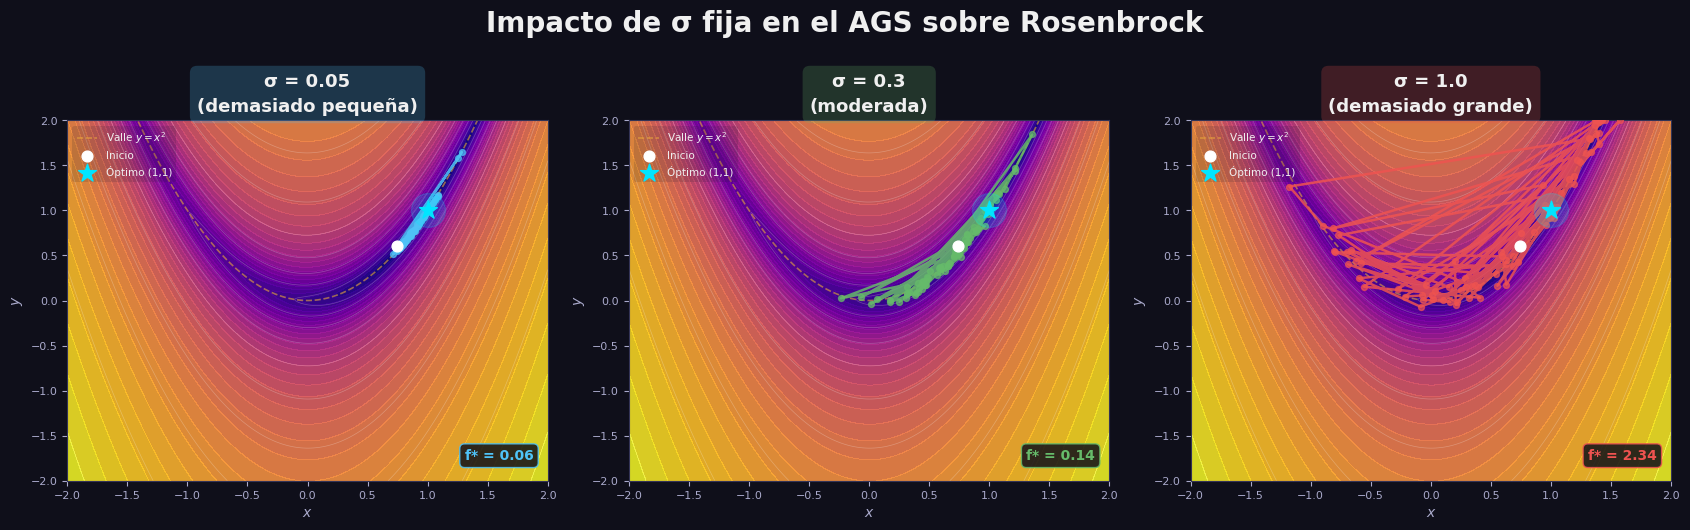

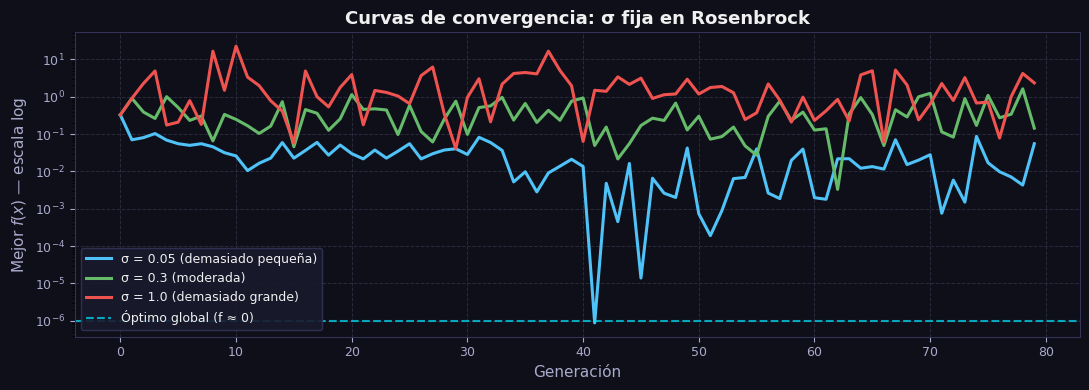

In [13]:
# ════════════════════════════════════════════════════════════════════════
# PROBLEMA DE σ FIJA EN ROSENBROCK
# ════════════════════════════════════════════════════════════════════════

def rosenbrock(xy):
    x, y = xy
    return (1 - x)**2 + 100*(y - x**2)**2

def ags_sigma_fija(sigma, n_gen=80, pop_size=30, seed=0):
    rng_local = np.random.default_rng(seed)
    pop = rng_local.uniform(-2, 2, (pop_size, 2))
    best_fitness, best_ind = [], []
    for _ in range(n_gen):
        fitness = np.array([-rosenbrock(ind) for ind in pop])
        best_idx = np.argmax(fitness)
        best_fitness.append(-fitness[best_idx])
        best_ind.append(pop[best_idx].copy())
        new_pop = []
        for _ in range(pop_size):
            idx = rng_local.choice(pop_size, 3, replace=False)
            winner = pop[idx[np.argmax(fitness[idx])]]
            child = winner + rng_local.normal(0, sigma, 2)
            child = np.clip(child, -2, 2)
            new_pop.append(child)
        pop = np.array(new_pop)
    return best_fitness, best_ind

# ── Paleta y configuración global ─────────────────────────────────────
DARK_BG  = '#0f0f1a'
GOLD     = '#EBA93B'
BLUE     = '#24398A'
WHITE    = '#f0f0f0'
GRAY     = '#aaaacc'

sigmas    = [0.05,              0.3,             1.0            ]
colores   = ['#4FC3F7',         '#66BB6A',        '#EF5350'      ]
etiquetas = ['σ = 0.05\n(demasiado pequeña)', 
             'σ = 0.3\n(moderada)', 
             'σ = 1.0\n(demasiado grande)']
etiquetas_leyenda = ['σ = 0.05 (demasiado pequeña)',
                     'σ = 0.3 (moderada)',
                     'σ = 1.0 (demasiado grande)']

resultados = {s: ags_sigma_fija(s) for s in sigmas}

# Paisaje
xx, yy = np.meshgrid(np.linspace(-2, 2, 300), np.linspace(-2, 2, 300))
zz_log  = np.log1p((1 - xx)**2 + 100*(yy - xx**2)**2)

# ── Figura principal: trayectorias ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Impacto de σ fija en el AGS sobre Rosenbrock',
             color=WHITE, fontsize=20, fontweight='bold', y=1.01)

for ax, sigma, color, etiq in zip(axes, sigmas, colores, etiquetas):
    bf, traj = resultados[sigma]
    traj = np.array(traj)

    ax.set_facecolor(DARK_BG)
    ax.contourf(xx, yy, zz_log, levels=35, cmap='plasma', alpha=0.88)
    ax.contour (xx, yy, zz_log, levels=12, colors='white', alpha=0.25, linewidths=0.5)

    # Valle y = x²
    t = np.linspace(-2, 2, 300)
    ax.plot(t, t**2, '--', color=GOLD, lw=1.2, alpha=0.6, label='Valle $y=x^2$')

    # Trayectoria
    ax.plot(traj[:, 0], traj[:, 1], '-', color=color,
            linewidth=1.8, alpha=0.85)
    ax.scatter(traj[:, 0], traj[:, 1], color=color,
               s=18, zorder=4, alpha=0.7)
    ax.scatter(traj[0, 0], traj[0, 1], color='white',
               s=60, zorder=5, marker='o', label='Inicio')

    # Óptimo
    ax.scatter([1], [1], color='#00e5ff', s=180, zorder=6,
               marker='*', label='Óptimo (1,1)')
    ax.scatter([1], [1], color='#00e5ff', s=600, zorder=5, alpha=0.18)

    # Valor final
    ax.text(0.97, 0.05, f'f* = {bf[-1]:.2f}',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=10, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.35', fc=DARK_BG,
                      ec=color, alpha=0.85))

    # Título con fondo de color del sigma
    ax.set_title(etiq, fontsize=13, color=WHITE, fontweight='bold',
                 linespacing=1.5,
                 bbox=dict(boxstyle='round,pad=0.4', fc=color,
                           alpha=0.22, ec='none'))

    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
    ax.set_xlabel('$x$', color=GRAY, fontsize=10)
    ax.set_ylabel('$y$', color=GRAY, fontsize=10)
    ax.tick_params(colors=GRAY, labelsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor('#333355')

    ax.legend(fontsize=7.5, loc='upper left',
              labelcolor=WHITE, framealpha=0.15,
              facecolor='#1a1a2e', edgecolor='none')

plt.tight_layout()
plt.show()

# ── Curvas de convergencia ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 4))
fig2.patch.set_facecolor(DARK_BG)
ax2.set_facecolor(DARK_BG)

for sigma, color, etiq in zip(sigmas, colores, etiquetas_leyenda):
    bf, _ = resultados[sigma]
    ax2.semilogy(bf, color=color, linewidth=2.2, label=etiq)

ax2.axhline(1e-6, color='#00e5ff', linestyle='--',
            linewidth=1.5, alpha=0.7, label='Óptimo global (f ≈ 0)')

ax2.set_xlabel('Generación', color=GRAY, fontsize=11)
ax2.set_ylabel('Mejor $f(x)$ — escala log', color=GRAY, fontsize=11)
ax2.set_title('Curvas de convergencia: σ fija en Rosenbrock',
              color=WHITE, fontsize=13, fontweight='bold')

ax2.tick_params(colors=GRAY, labelsize=9)
for sp in ax2.spines.values():
    sp.set_edgecolor('#333355')
ax2.grid(True, color='#2a2a3e', linewidth=0.7, linestyle='--')

ax2.legend(fontsize=9, labelcolor=WHITE,
           facecolor='#1a1a2e', edgecolor='#333355',
           framealpha=0.9)

plt.tight_layout()
plt.show()


Las trayectorias sobre el mapa de contorno revelan los tres comportamientos patológicos del σ fijo:

Con **σ pequeña**, la trayectoria avanza milímetro a milímetro. Al principio parece prometedora, pero se detiene mucho antes de alcanzar el óptimo: queda atrapada en la curvatura del valle porque sus pasos son demasiado cortos para seguir el fondo.

Con **σ grande**, la trayectoria cruza el valle varias veces pero nunca baja a su fondo. Las mutaciones son tan intensas que el algoritmo salta por encima de la región de alta calidad sin poder asentarse en ella.

Con **σ moderada**, el resultado mejora pero tampoco es óptimo: σ = 0.3 funciona bien en la fase de exploración inicial pero es demasiado grande para el afinamiento final.

**Las curvas de convergencia** confirman esto en escala logarítmica: ningún valor de σ domina en todas las fases. La curva moderada baja rápido al principio pero se estanca; la curva pequeña converge despacio desde el inicio; la curva grande oscila sin bajar de manera sostenida.

<div style="background: linear-gradient(135deg, #fff3e0, #ffe0b2); border-left: 5px solid #e65100; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong> El dilema del parámetro fijo:</strong> Elegir σ "a mano" requiere conocer de antemano la geometría del paisaje que se quiere explorar. Pero si ya conociéramos esa geometría, no necesitaríamos el algoritmo. La autoadaptación es la salida lógica a esta circularidad.
</div>


### Historia y motivación original

Las Estrategias Evolutivas nacieron entre 1963 y 1965 en la Technische Universität Berlin, de la mano de Ingo Rechenberg y Hans-Paul Schwefel, como parte de sus tesis doctorales de ingeniería aeronáutica. El contexto es revelador: querían optimizar la forma de una placa articulada sumergida en un flujo de agua. No existía gradiente analítico. No había buenas aproximaciones lineales. El espacio de diseño era continuo y de dimensión moderada.

Su solución fue ingeniosamente simple: representar el diseño como un vector real, perturbarlo con ruido gaussiano, y quedarse con la perturbación si mejoraba. De ahí nació la **(1+1)-ES** — un padre, un hijo, selección del mejor.

El salto conceptual clave vino después: Rechenberg observó empíricamente que la tasa de éxito óptima de las mutaciones es aproximadamente **1/5**. Si más de un quinto de las mutaciones mejoran la solución, σ es demasiado pequeña (poca exploración). Si menos de un quinto mejoran, σ es demasiado grande (demasiado ruido). Esta observación —la **Regla de los 1/5**— fue el primer mecanismo de adaptación de parámetros de estrategia.

```
  1963-65   Rechenberg & Schwefel: (1+1)-ES, optimización de forma
    │
  1973      Tesis doctoral Rechenberg: Regla de los 1/5
    │
  1975      Schwefel: (μ+λ)-ES y (μ,λ)-ES con poblaciones
    │
  1987      Bäck & Schwefel: autoadaptación lognormal de σ
    │
  1996      Hansen & Ostermeier: CMA-ES — el estado del arte actual
```

Esta genealogía importa porque cada paso resolvió una limitación concreta del anterior, y porque toda la familia mantiene un hilo conductor: **los parámetros de variación son ciudadanos de primera clase del proceso evolutivo**.


### El cromosoma extendido: la diferencia estructural fundamental

Para visualizar concretamente la diferencia entre el AGS y una EE, comparemos cómo representa cada uno a un individuo en un problema de optimización de dimensión $n = 4$.

**En el AGS** (codificación binaria con 8 bits por variable):

```
individuo = [ 0 1 1 0 1 0 0 1 | 1 0 0 1 1 1 0 0 | 0 0 1 1 0 1 1 0 | 1 1 0 0 0 1 0 1 ]
               ←─── x₁ ────→   ←─── x₂ ────→   ←─── x₃ ────→   ←─── x₄ ────→
               (32 bits en total, sin información sobre cómo mutar)
```

**En una EE** (codificación real con autoadaptación):

```
individuo = [ x₁,   x₂,   x₃,   x₄   |  σ₁,   σ₂,   σ₃,   σ₄  ]
              2.31  -0.87   1.54   0.23    0.41   0.12   0.38   0.09
              ←────── variables ──────→   ←── parámetros de estrategia ──→
              (las variables del problema)  (instrucciones para mutar cada variable)
```

Cuando este individuo se reproduce, genera un hijo aplicando:

$$\sigma_i' = \sigma_i \cdot \exp(\tau' \cdot \mathcal{N}(0,1) + \tau \cdot \mathcal{N}_i(0,1))$$

$$x_i' = x_i + \sigma_i' \cdot \mathcal{N}_i(0,1)$$

Las $\sigma_i$ mutan primero, y luego guían la mutación de las $x_i$. Si el hijo es bueno, sus $\sigma_i'$ —que produjeron esa buena solución— sobreviven. Si es malo, esas $\sigma_i'$ desaparecen. **Las instrucciones de mutación que funcionan se heredan**.

La siguiente celda construye una visualización directa de esta diferencia:

----

---

<p align="center">
  <img src="images/exhausted.png" width="500">
</p>

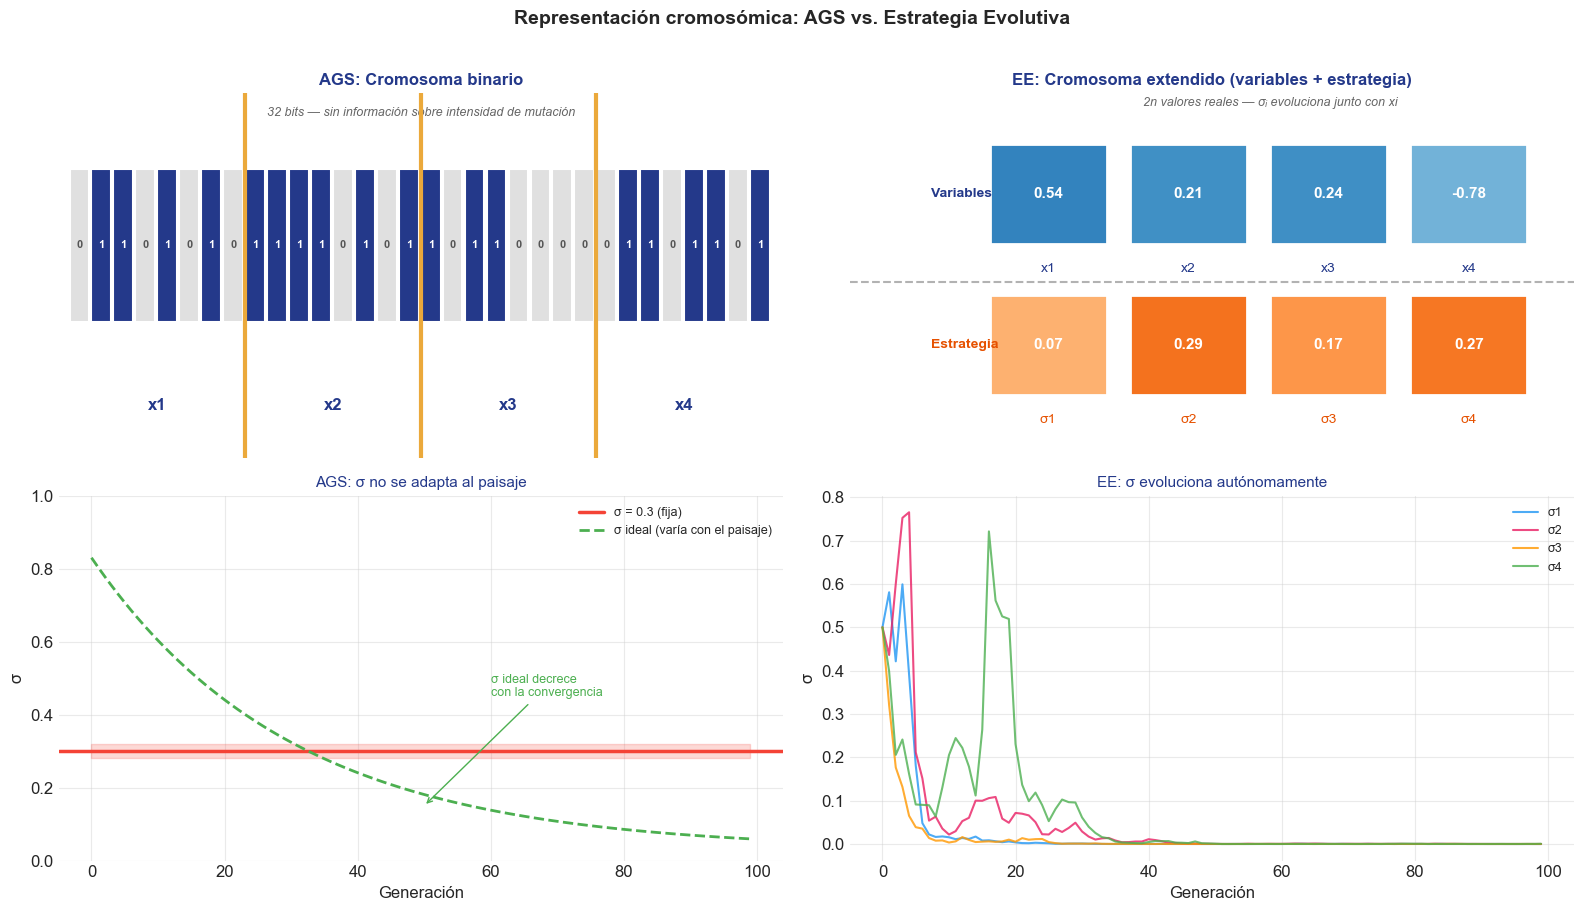

In [6]:
# ════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN COMPARATIVA: CROMOSOMA AGS vs. EE
# ════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle('Representación cromosómica: AGS vs. Estrategia Evolutiva', 
             fontsize=14, fontweight='bold', y=1.01)

# ─── Panel 1: Cromosoma AGS ───────────────────────────────────────────
ax = axes[0, 0]
n_bits = 32  # 8 bits × 4 variables
bits = rng.integers(0, 2, n_bits)
colores_bits = ['#24398A' if b == 1 else '#e0e0e0' for b in bits]

for i, (bit, color) in enumerate(zip(bits, colores_bits)):
    rect = plt.Rectangle([i, 0], 0.9, 1, facecolor=color, edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(i + 0.45, 0.5, str(bit), ha='center', va='center', fontsize=8,
            color='white' if bit == 1 else '#555', fontweight='bold')

# Separadores entre variables
for sep in [8, 16, 24]:
    ax.axvline(sep, color='#EBA93B', linewidth=3, zorder=5)

# Etiquetas de variables
for i, var in enumerate(['x1', 'x2', 'x3', 'x4']):
    ax.text(i*8 + 4, -0.5, var, ha='center', va='top', fontsize=12,
            color='#24398A', fontweight='bold')

ax.set_xlim(-0.5, n_bits + 0.5)
ax.set_ylim(-0.9, 1.5)
ax.set_title('AGS: Cromosoma binario', fontsize=12, fontweight='bold', color='#24398A')
ax.axis('off')
ax.text(16, 1.35, '32 bits — sin información sobre intensidad de mutación',
        ha='center', fontsize=9, color='#666', style='italic')

# ─── Panel 2: Cromosoma EE ────────────────────────────────────────────
ax = axes[0, 1]
n = 4
x_vals  = rng.uniform(-2, 2, n)
s_vals  = rng.uniform(0.05, 0.6, n)

# Variables x
cmap_x = plt.cm.Blues
for i, xv in enumerate(x_vals):
    norm_val = (xv + 2) / 4  # normalizar a [0,1]
    rect = plt.Rectangle([i*1.2, 1.2], 1.0, 0.8, 
                          facecolor=cmap_x(0.3 + 0.6*norm_val), 
                          edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(i*1.2 + 0.5, 1.6, f'{xv:.2f}', ha='center', va='center',
            fontsize=11, color='white', fontweight='bold')
    ax.text(i*1.2 + 0.5, 1.05, f'x{i+1}', ha='center', va='top',
            fontsize=10, color='#24398A')

# Parámetros σ
cmap_s = plt.cm.Oranges
for i, sv in enumerate(s_vals):
    norm_val = sv / 0.6
    rect = plt.Rectangle([i*1.2, 0.0], 1.0, 0.8, 
                          facecolor=cmap_s(0.3 + 0.6*norm_val), 
                          edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(i*1.2 + 0.5, 0.4, f'{sv:.2f}', ha='center', va='center',
            fontsize=11, color='white', fontweight='bold')
    ax.text(i*1.2 + 0.5, -0.15, f'σ{i+1}', ha='center', va='top',
            fontsize=10, color='#e65100')

# Etiquetas de sección
ax.text(-0.5, 1.6, 'Variables', fontsize=10, color='#24398A', fontweight='bold', va='center')
ax.text(-0.5, 0.4, 'Estrategia', fontsize=10, color='#e65100', fontweight='bold', va='center')

# Separador
ax.axhline(0.9, color='#666', linestyle='--', linewidth=1.5, alpha=0.5)

ax.set_xlim(-1.2, n*1.2 + 0.2)
ax.set_ylim(-0.5, 2.4)
ax.set_title('EE: Cromosoma extendido (variables + estrategia)', fontsize=12, 
             fontweight='bold', color='#24398A')
ax.axis('off')
ax.text(n*0.6, 2.3, '2n valores reales — σᵢ evoluciona junto con xi',
        ha='center', fontsize=9, color='#666', style='italic')

# ─── Panel 3: σ a lo largo de generaciones — AGS ──────────────────────
ax = axes[1, 0]
gens = np.arange(100)
ax.axhline(0.3, color='#F44336', linewidth=2.5, label='σ = 0.3 (fija)')
ax.fill_between(gens, 0.28, 0.32, alpha=0.2, color='#F44336')

# Zona óptima hipotética
sigma_opt = 0.8 * np.exp(-gens / 30) + 0.03
ax.plot(gens, sigma_opt, color='#4CAF50', linewidth=2, linestyle='--',
        label='σ ideal (varía con el paisaje)')

ax.set_xlabel('Generación'); ax.set_ylabel('σ')
ax.set_title('AGS: σ no se adapta al paisaje', fontsize=11, color='#24398A')
ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
ax.set_ylim(0, 1.0)
ax.annotate('σ ideal decrece\ncon la convergencia', xy=(50, 0.15), fontsize=9, color='#4CAF50',
            xytext=(60, 0.45), arrowprops=dict(arrowstyle='->', color='#4CAF50'))

# ─── Panel 4: σ adaptativa en EE ─────────────────────────────────────
ax = axes[1, 1]

# Simular evolución de σ en una EE
tau = 1 / np.sqrt(2 * np.sqrt(4))  # parámetro lognormal para n=4
tau_prime = 1 / np.sqrt(2 * 4)
sigma_ee = np.zeros((4, 100))
sigma_ee[:, 0] = [0.5, 0.5, 0.5, 0.5]
rng_local = np.random.default_rng(7)

for t in range(1, 100):
    global_noise = rng_local.normal(0, 1)
    for i in range(4):
        local_noise = rng_local.normal(0, 1)
        sigma_ee[i, t] = max(sigma_ee[i, t-1] * np.exp(tau_prime*global_noise + tau*local_noise), 1e-4)
        # Sesgo artificial hacia convergencia para ilustración
        if sigma_ee[i, t] > sigma_ee[i, t-1] and t > 20:
            sigma_ee[i, t] *= 0.92

colors_ee = ['#2196F3', '#E91E63', '#FF9800', '#4CAF50']
for i in range(4):
    ax.plot(sigma_ee[i], color=colors_ee[i], linewidth=1.5, alpha=0.8, label=f'σ{i+1}')

ax.set_xlabel('Generación'); ax.set_ylabel('σ')
ax.set_title('EE: σ evoluciona autónomamente', fontsize=11, color='#24398A')
ax.legend(fontsize=9, loc='upper right'); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### Qué observar en esta figura

Los cuatro paneles sintetizan la diferencia estructural entre los dos enfoques.

En la fila superior se contrasta la arquitectura del cromosoma. El AGS almacena únicamente bits que codifican los valores de las variables; no hay espacio en el cromosoma para información sobre cómo mutar. La EE, en cambio, lleva una segunda capa que contiene los parámetros de estrategia: cada variable tiene su propio σ asociado, y ambas capas evolucionan juntas.

En la fila inferior se ve la consecuencia dinámica de esta diferencia. El AGS mantiene σ constante a lo largo de todas las generaciones, independientemente de si el algoritmo está explorando zonas nuevas o afinando una solución casi convergida. La curva punteada verde marca la intensidad de mutación que sería óptima en cada fase: alta al principio, baja al final. La línea roja del AGS nunca coincide con ella.

Las trayectorias de σ en la EE muestran el comportamiento opuesto: cada componente del vector de estrategia sigue su propia trayectoria, respondiendo a la geometría local del paisaje en esa dirección. La convergencia hacia valores pequeños no es programada — emerge del propio proceso evolutivo.

<div style="background: linear-gradient(135deg, #e3f2fd, #bbdefb); border-left: 5px solid #1565c0; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Reflexión:</strong> Nótese que los σ de cada dimensión convergen a valores distintos. Esto no es un defecto — es precisamente la señal de que el algoritmo ha aprendido que diferentes direcciones del espacio requieren diferentes intensidades de exploración. Esta información es exactamente lo que un optimizador basado en gradiente obtiene de la matriz Hessiana, pero aquí se infiere sin calcular derivadas.
</div>

### 1.4 Resumen: la taxonomía de las diferencias

Antes de profundizar en los mecanismos de las EE, conviene tener clara la taxonomía completa de lo que cambia. No se trata solo de una diferencia técnica en la representación: es una diferencia filosófica sobre el rol de los parámetros del algoritmo.

| Categoría | AGS | Estrategia Evolutiva | Implicación práctica |
|---|---|---|---|
| **¿Qué evoluciona?** | Solo las variables del problema | Variables + parámetros de variación | Las EE hacen metaoptimización implícita |
| **Tipo de espacio** | Discreto / binario | Continuo, ℝⁿ | Las EE no necesitan codificación |
| **Operador principal** | Cruza (intercambio de bloques) | Mutación gaussiana (perturbación vectorial) | Las EE explotan la geometría euclídea |
| **Selección** | Probabilística (torneo, ruleta) | Determinista (mejores μ de λ) | Las EE tienen presión selectiva controlada y predecible |
| **Parámetros del usuario** | Pop, n_gen, σ, p_cruce, p_mut | Pop, n_gen; σ₀ opcional | Las EE requieren menos ajuste manual |
| **Escalado** | Pierde eficiencia en alta dimensión | Diseñadas para alta dimensión | Las EE son la opción natural en n > 10 continuo |

<br>

En las siguientes secciones construiremos los mecanismos de las EE desde cero: primero la geometría de la mutación gaussiana, luego la autoadaptación lognormal, y finalmente CMA-ES como culminación de esta línea de ideas.

---

## 2. Representación y notación (μ, λ)

Las Estrategias Evolutivas tienen una notación precisa que comunica en dos números cómo opera el algoritmo. Entender esta notación es entender la lógica de selección de las EE.

### 2.1 Los dos números que definen una EE

**μ (mu)** — número de padres que sobreviven y se reproducen.  
**λ (lambda)** — número de hijos que se generan en cada generación.

Con estos dos números hay dos modos de operación posibles, y la diferencia entre ellos es más profunda de lo que parece:

| Notación | Selección | Elitismo | Cuándo usar |
|---|---|---|---|
| **(μ + λ)-ES** | Los mejores μ de **padres ∪ hijos** | Sí — los padres compiten con sus hijos | Paisajes suaves; cuando perder el mejor es inaceptable |
| **(μ, λ)-ES** | Los mejores μ de **solo los hijos** | No — los padres siempre desaparecen | Paisajes rugosos, ruidosos o no estacionarios |

Restricción estructural: en **(μ, λ)** se requiere que **λ ≥ μ** — deben nacer suficientes hijos para seleccionar μ de entre ellos.

<div style="background: linear-gradient(135deg, #f3e5f5, #e1bee7); border-left: 5px solid #6a1b9a; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Analogía:</strong> (μ+λ) es una empresa donde los veteranos compiten con los recién contratados y los mejores de ambos grupos conservan su puesto. (μ,λ) es una empresa donde cada generación de empleados se jubila por completo al nacer la siguiente — solo los nuevos compiten entre sí. El segundo esquema parece más duro, pero fuerza al algoritmo a explorar activamente en lugar de aferrarse a soluciones pasadas.
</div>

### 2.2 Flujo de una generación

El ciclo completo de una generación en una EE es:

```
PADRES (μ individuos)
    │
    ├─ Recombinación intermedia (opcional): mezclar padres para crear λ padres "virtuales"
    │
    ├─ Mutación lognormal de σ:   σᵢ' = σᵢ · exp(τ'·N(0,1) + τ·Nᵢ(0,1))
    │
    └─ Mutación gaussiana de x:   xᵢ' = xᵢ + σᵢ'·Nᵢ(0,1)
                                    ↓
                               HIJOS (λ individuos)
                                    │
                    ┌───────────────┴───────────────┐
                    │                               │
               (μ+λ)-ES                        (μ,λ)-ES
           Mejores μ de                     Mejores μ de
           padres ∪ hijos                   solo los hijos
                    │                               │
                    └───────────────┬───────────────┘
                                    │
                         NUEVA GENERACIÓN (μ padres)
```

### 2.3 Ratios típicos de μ y λ

La elección de μ y λ no es arbitraria. Hay una relación empírica bien establecida:  
el **ratio λ/μ ≈ 7** es un punto de partida robusto para muchos problemas.

La intuición es directa: si generamos pocos hijos (λ/μ pequeño), cada hijo tiene alta probabilidad de sobrevivir y la presión selectiva es baja — poca dirección en la búsqueda. Si generamos muchos hijos (λ/μ grande), solo el mejor 1/7 sobrevive — alta presión selectiva, búsqueda más dirigida pero más costosa computacionalmente.

Configuraciones comunes en la literatura:

| Configuración | μ | λ | λ/μ | Uso típico |
|---|---|---|---|---|
| Minimalista | 1 | 1 | 1.0 | (1+1)-ES: hill climbing estocástico |
| Clásica | 5 | 35 | 7.0 | Problemas de baja dimensión |
| Estándar | 15 | 100 | 6.7 | Benchmark general |
| Alta dimensión | 30 | 200 | 6.7 | n > 50 variables |
| CMA-ES default | ~7 | ~14 | 2.0 | Calculado automáticamente de n |

In [7]:
# ════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN COMPARATIVA: (μ+λ)-ES vs. (μ,λ)-ES
#
# Objetivo: mostrar visualmente la diferencia en presión selectiva
# y comportamiento de convergencia entre los dos esquemas.
# Función de prueba: Rosenbrock 2D (conocida de la sección anterior)
# ════════════════════════════════════════════════════════════════════════

def rosenbrock(xy):
    x, y = xy
    return (1 - x)**2 + 100*(y - x**2)**2


def ee_step(padres, sigma_padres, mu, lam, modo='plus', rng_local=None):
    """
    Una generación de EE con autoadaptación lognormal isótropa (σ escalar).
    modo: 'plus'  → (μ+λ): selección de padres ∪ hijos
          'comma' → (μ,λ): selección solo de hijos
    """
    n = padres.shape[1]
    tau = 1 / np.sqrt(2 * n)  # parámetro lognormal global

    # ── Generar λ hijos ──────────────────────────────────────────────
    hijos = np.zeros((lam, n))
    sigma_hijos = np.zeros(lam)

    for k in range(lam):
        # Seleccionar padre al azar (recombinación uniforme implícita)
        idx = rng_local.integers(0, mu)
        padre = padres[idx]
        s = sigma_padres[idx]

        # Autoadaptación de σ
        s_new = max(s * np.exp(tau * rng_local.standard_normal()), 1e-6)
        sigma_hijos[k] = s_new

        # Mutación gaussiana
        hijos[k] = padre + s_new * rng_local.standard_normal(n)

    # ── Selección ─────────────────────────────────────────────────────
    if modo == 'plus':
        pool_x = np.vstack([padres, hijos])
        pool_s = np.concatenate([sigma_padres, sigma_hijos])
    else:  # comma
        pool_x = hijos
        pool_s = sigma_hijos

    fitness = np.array([rosenbrock(ind) for ind in pool_x])
    idx_sorted = np.argsort(fitness)[:mu]  # minimizamos

    return pool_x[idx_sorted], pool_s[idx_sorted], fitness[idx_sorted[0]]


def run_ee(mu, lam, modo, n_gen=150, seed=42):
    """Ejecuta una EE completa y devuelve historial de convergencia."""
    rng_local = np.random.default_rng(seed)
    padres = rng_local.uniform(-2, 2, (mu, 2))
    sigma  = np.full(mu, 0.5)
    hist_fitness = []
    hist_sigma   = []
    hist_best    = []

    for _ in range(n_gen):
        padres, sigma, best_f = ee_step(padres, sigma, mu, lam, modo, rng_local)
        hist_fitness.append(best_f)
        hist_sigma.append(sigma.mean())
        hist_best.append(padres[0].copy())

    return np.array(hist_fitness), np.array(hist_sigma), np.array(hist_best)


# ── Ejecutar los cuatro escenarios ────────────────────────────────────
MU, LAM = 5, 35  # ratio 7:1 clásico
N_GEN   = 150

f_plus,  s_plus,  traj_plus  = run_ee(MU, LAM, 'plus',  N_GEN)
f_comma, s_comma, traj_comma = run_ee(MU, LAM, 'comma', N_GEN)

print(f'(μ+λ)-ES: mejor f = {f_plus[-1]:.6f}  |  σ final = {s_plus[-1]:.5f}')
print(f'(μ,λ)-ES: mejor f = {f_comma[-1]:.6f}  |  σ final = {s_comma[-1]:.5f}')

(μ+λ)-ES: mejor f = 0.000000  |  σ final = 0.00118
(μ,λ)-ES: mejor f = 0.000000  |  σ final = 0.00000


AttributeError: module 'matplotlib.pyplot' has no attribute 'FancyArrowPatch'

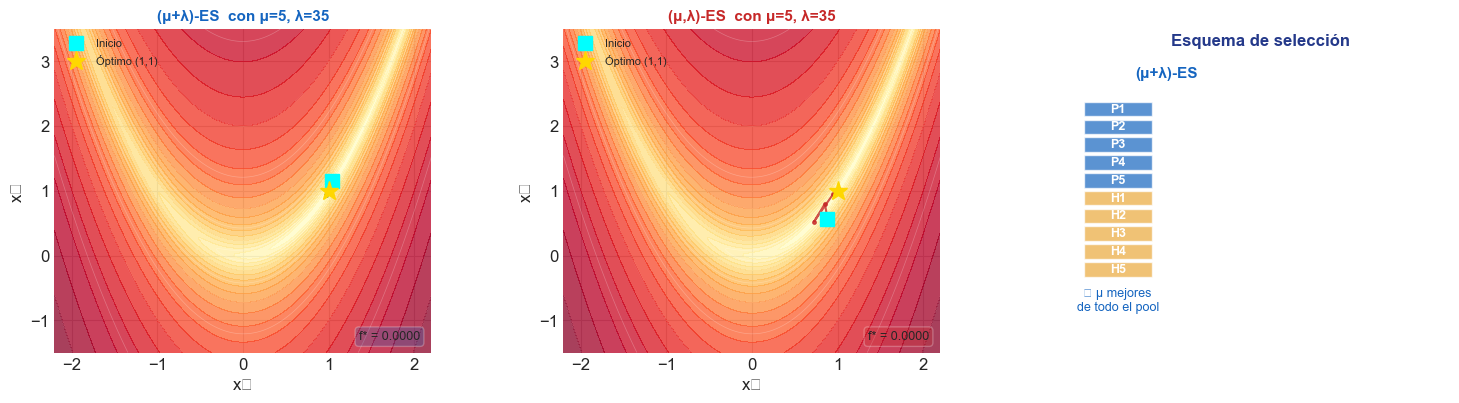

In [9]:
# ════════════════════════════════════════════════════════════════════════
# FIGURA: Comparativa (μ+λ) vs. (μ,λ) — trayectorias y convergencia
# ════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

# Paisaje Rosenbrock
xx, yy = np.meshgrid(np.linspace(-2.2, 2.2, 300), np.linspace(-1.5, 3.5, 300))
zz_log = np.log1p((1-xx)**2 + 100*(yy - xx**2)**2)

# ─── Trayectoria (μ+λ) ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.contourf(xx, yy, zz_log, levels=25, cmap='YlOrRd', alpha=0.75)
ax1.contour(xx, yy, zz_log, levels=8, colors='white', alpha=0.25, linewidths=0.5)
ax1.plot(traj_plus[:, 0], traj_plus[:, 1], '-o',
         color='#1565c0', markersize=2.5, linewidth=1.5, alpha=0.8)
ax1.plot(traj_plus[0,0], traj_plus[0,1], 's', color='cyan', markersize=10, zorder=6, label='Inicio')
ax1.plot(1, 1, '*', color='gold', markersize=14, zorder=7, label='Óptimo (1,1)')
ax1.set_title(f'(μ+λ)-ES  con μ={MU}, λ={LAM}', fontsize=11, fontweight='bold', color='#1565c0')
ax1.set_xlabel('x₁'); ax1.set_ylabel('x₂')
ax1.legend(fontsize=8, loc='upper left')
ax1.set_xlim(-2.2, 2.2); ax1.set_ylim(-1.5, 3.5)
ax1.annotate(f'f* = {f_plus[-1]:.4f}', xy=(0.97, 0.04),
             xycoords='axes fraction', ha='right', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='#1565c0', alpha=0.25))

# ─── Trayectoria (μ,λ) ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.contourf(xx, yy, zz_log, levels=25, cmap='YlOrRd', alpha=0.75)
ax2.contour(xx, yy, zz_log, levels=8, colors='white', alpha=0.25, linewidths=0.5)
ax2.plot(traj_comma[:, 0], traj_comma[:, 1], '-o',
         color='#c62828', markersize=2.5, linewidth=1.5, alpha=0.8)
ax2.plot(traj_comma[0,0], traj_comma[0,1], 's', color='cyan', markersize=10, zorder=6, label='Inicio')
ax2.plot(1, 1, '*', color='gold', markersize=14, zorder=7, label='Óptimo (1,1)')
ax2.set_title(f'(μ,λ)-ES  con μ={MU}, λ={LAM}', fontsize=11, fontweight='bold', color='#c62828')
ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')
ax2.legend(fontsize=8, loc='upper left')
ax2.set_xlim(-2.2, 2.2); ax2.set_ylim(-1.5, 3.5)
ax2.annotate(f'f* = {f_comma[-1]:.4f}', xy=(0.97, 0.04),
             xycoords='axes fraction', ha='right', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='#c62828', alpha=0.25))

# ─── Esquema estructural de selección ────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
ax3.set_xlim(0, 10); ax3.set_ylim(0, 10)

ax3.text(5, 9.5, 'Esquema de selección', ha='center', fontsize=12,
         fontweight='bold', color='#24398A')

# (μ+λ)
ax3.text(2.5, 8.5, '(μ+λ)-ES', ha='center', fontsize=11, color='#1565c0', fontweight='bold')
for i in range(5):
    y = 7.3 - i*0.55
    color = '#1565c0' if i < MU else '#90a4ae'
    label = f'P{i+1}' if i < MU else f'H{i-MU+1}'
    ax3.add_patch(plt.Rectangle([0.3, y], 1.8, 0.45, facecolor=color, alpha=0.7, edgecolor='white'))
    ax3.text(1.2, y+0.22, label, ha='center', va='center', color='white', fontsize=9, fontweight='bold')
# hijos
for i in range(5):
    y = 7.3 - (i+5)*0.55
    ax3.add_patch(plt.Rectangle([0.3, y], 1.8, 0.45, facecolor='#EBA93B', alpha=0.7, edgecolor='white'))
    ax3.text(1.2, y+0.22, f'H{i+1}', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
ax3.text(1.2, 1.3, '⬆ μ mejores\nde todo el pool', ha='center', fontsize=9, color='#1565c0')
ax3.add_patch(plt.FancyArrowPatch((1.2, 4.4), (1.2, 1.75),
                                   arrowstyle='->', color='#1565c0', lw=2,
                                   mutation_scale=18))

# (μ,λ)
ax3.text(7.5, 8.5, '(μ,λ)-ES', ha='center', fontsize=11, color='#c62828', fontweight='bold')
# padres (tachados)
for i in range(5):
    y = 7.3 - i*0.55
    ax3.add_patch(plt.Rectangle([5.5, y], 1.8, 0.45, facecolor='#90a4ae', alpha=0.5, edgecolor='white'))
    ax3.text(6.4, y+0.22, f'P{i+1} ✗', ha='center', va='center', color='#555', fontsize=9)
# hijos seleccionados
for i in range(5):
    y = 7.3 - (i+5)*0.55
    color = '#c62828' if i < MU else '#EBA93B'
    ax3.add_patch(plt.Rectangle([5.5, y], 1.8, 0.45, facecolor=color, alpha=0.75, edgecolor='white'))
    ax3.text(6.4, y+0.22, f'H{i+1}', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
ax3.text(6.4, 1.3, '⬆ μ mejores\nsolo de hijos', ha='center', fontsize=9, color='#c62828')
ax3.add_patch(plt.FancyArrowPatch((6.4, 4.4), (6.4, 1.75),
                                   arrowstyle='->', color='#c62828', lw=2,
                                   mutation_scale=18))

# ─── Convergencia del fitness ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
gens = np.arange(1, N_GEN + 1)
ax4.semilogy(gens, f_plus + 1e-10,  color='#1565c0', linewidth=2.5, label=f'(μ+λ)-ES  f*={f_plus[-1]:.5f}')
ax4.semilogy(gens, f_comma + 1e-10, color='#c62828', linewidth=2.5, label=f'(μ,λ)-ES   f*={f_comma[-1]:.5f}')
ax4.axhline(0, color='gold', linestyle='--', linewidth=1.5, label='Óptimo global (f=0)')
ax4.set_xlabel('Generación'); ax4.set_ylabel('Mejor f(x) — escala log')
ax4.set_title(f'Convergencia comparada — μ={MU}, λ={LAM} — Rosenbrock 2D', fontweight='bold')
ax4.legend(fontsize=10); ax4.grid(True, alpha=0.35)

# ─── Evolución de σ promedio ──────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(gens, s_plus,  color='#1565c0', linewidth=2, label='(μ+λ)-ES')
ax5.plot(gens, s_comma, color='#c62828', linewidth=2, label='(μ,λ)-ES')
ax5.set_xlabel('Generación'); ax5.set_ylabel('σ promedio')
ax5.set_title('Adaptación de σ durante la búsqueda', fontweight='bold')
ax5.legend(fontsize=10); ax5.grid(True, alpha=0.35)

plt.suptitle(f'Comparativa (μ+λ)-ES vs. (μ,λ)-ES  |  Rosenbrock 2D  |  μ={MU}, λ={LAM}',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

### Qué observar en esta figura

Los dos mapas de trayectoria muestran rutas cualitativamente distintas hacia el mismo óptimo. La (μ+λ)-ES avanza de forma más conservadora: retiene los mejores padres, lo que produce una trayectoria menos errática pero que en ocasiones se queda orbitando cerca del óptimo sin afinar. La (μ,λ)-ES muestra trayectorias más exploratorias al principio — puede alejarse temporalmente del mejor punto conocido — pero esa capacidad de "olvidar" soluciones pasadas le permite escapar de regiones subóptimas.

La curva de convergencia lo confirma en escala logarítmica. Ambos esquemas reducen el valor de la función de forma sostenida, pero con perfiles diferentes: (μ+λ) tiende a converger más rápido en las primeras generaciones (gracias al elitismo), mientras que (μ,λ) puede alcanzar valores finales comparables con mayor robustez en paisajes donde el elitismo es perjudicial.

El panel de σ es el más instructivo: en ambos casos el parámetro de estrategia decrece de forma autónoma a medida que el algoritmo converge — nadie programó ese comportamiento. Emerge de la presión selectiva: las mutaciones pequeñas que afinen la solución son más ventajosas en las etapas finales, y los individuos que las llevan en su σ tienen mayor probabilidad de sobrevivir.

<div style="background: linear-gradient(135deg, #e8f5e9, #c8e6c9); border-left: 5px solid #2e7d32; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Regla práctica:</strong> Usa (μ+λ) cuando el paisaje es suave y la pérdida de la mejor solución encontrada sea inaceptable (por ejemplo, diseño de ingeniería con evaluaciones costosas). Usa (μ,λ) cuando el paisaje sea ruidoso, cambiante, o cuando sospechas que puede haber convergencia prematura — el no-elitismo actúa como mecanismo de diversificación forzada.
</div>

### 2.4 Efecto del ratio λ/μ sobre la presión selectiva

El ratio λ/μ controla directamente cuánta presión selectiva ejerce el algoritmo: cuántos hijos compiten por el mismo número de plazas de supervivencia. Una exploración sistemática de este parámetro es más informativa que cualquier descripción verbal.

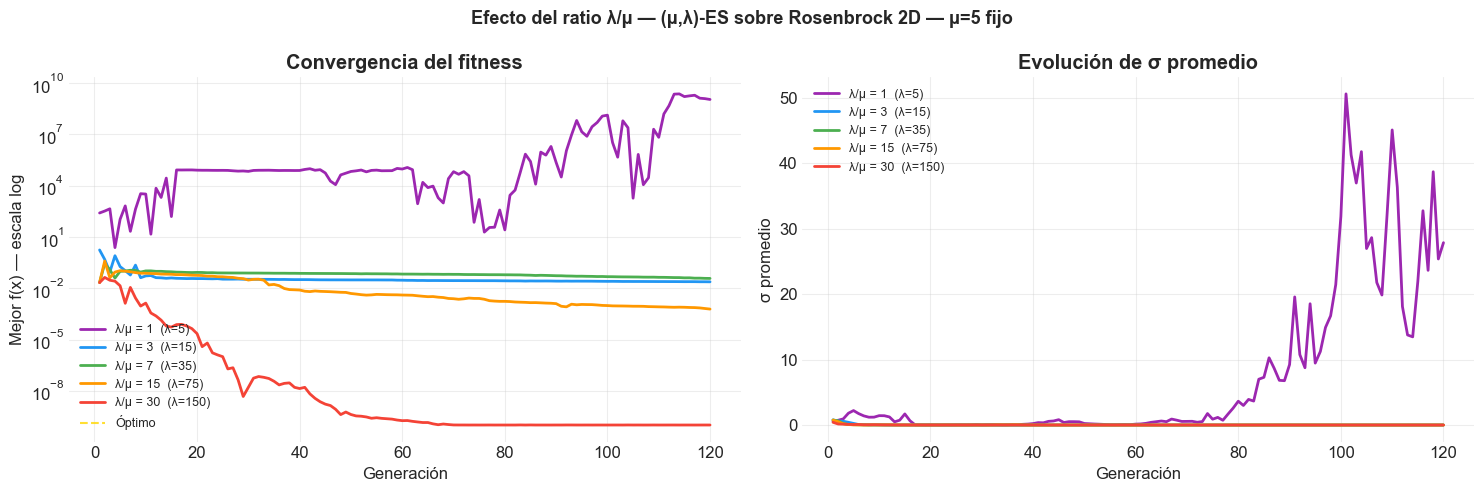


Resumen final:
   ratio λ/μ      λ       f* final      σ final    Eval. totales
----------------------------------------------------------------
           1      5 1115637588.728911     27.88404              600
           3     15       0.023898      0.00071             1800
           7     35       0.037770      0.00296             4200
          15     75       0.000608      0.00128             9000
          30    150       0.000000      0.00000            18000


In [10]:
# ════════════════════════════════════════════════════════════════════════
# EFECTO DEL RATIO λ/μ SOBRE CONVERGENCIA Y DIVERSIDAD
# ════════════════════════════════════════════════════════════════════════

MU_FIXED = 5
ratios   = [1, 3, 7, 15, 30]  # λ/μ
colores  = ['#9C27B0', '#2196F3', '#4CAF50', '#FF9800', '#F44336']
N_GEN    = 120

resultados_ratio = {}
for ratio in ratios:
    lam = MU_FIXED * ratio
    # (μ,λ) requiere lam >= mu; (1,1) lo manejamos como caso especial
    if lam < MU_FIXED:
        continue
    f_hist, s_hist, _ = run_ee(MU_FIXED, lam, 'comma', N_GEN, seed=0)
    resultados_ratio[ratio] = (f_hist, s_hist, lam)

fig, (ax_f, ax_s) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Efecto del ratio λ/μ — (μ,λ)-ES sobre Rosenbrock 2D — μ={MU_FIXED} fijo',
             fontsize=13, fontweight='bold')

for (ratio, (f_hist, s_hist, lam)), color in zip(resultados_ratio.items(), colores):
    gens = np.arange(1, N_GEN + 1)
    ax_f.semilogy(gens, f_hist + 1e-10, color=color, linewidth=2,
                  label=f'λ/μ = {ratio}  (λ={lam})')
    ax_s.plot(gens, s_hist, color=color, linewidth=2,
              label=f'λ/μ = {ratio}  (λ={lam})')

ax_f.axhline(0, color='gold', linestyle='--', linewidth=1.5, alpha=0.8, label='Óptimo')
ax_f.set_xlabel('Generación'); ax_f.set_ylabel('Mejor f(x) — escala log')
ax_f.set_title('Convergencia del fitness', fontweight='bold')
ax_f.legend(fontsize=9); ax_f.grid(True, alpha=0.35)

ax_s.set_xlabel('Generación'); ax_s.set_ylabel('σ promedio')
ax_s.set_title('Evolución de σ promedio', fontweight='bold')
ax_s.legend(fontsize=9); ax_s.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

# Tabla resumen
print('\nResumen final:')
print(f'{"ratio λ/μ":>12} {"λ":>6} {"f* final":>14} {"σ final":>12} {"Eval. totales":>16}')
print('-' * 64)
for ratio, (f_hist, s_hist, lam) in resultados_ratio.items():
    evals = N_GEN * lam
    print(f'{ratio:>12} {lam:>6} {f_hist[-1]:>14.6f} {s_hist[-1]:>12.5f} {evals:>16}')

### Qué observar en esta figura

Las curvas de convergencia muestran un patrón claro: ratios bajos (λ/μ = 1 o 3) convergen rápido en las primeras generaciones pero se detienen antes — la presión selectiva es insuficiente para escapar de mínimos locales en el valle de Rosenbrock. Ratios altos (λ/μ = 15 o 30) invierten más evaluaciones por generación pero alcanzan valores finales menores y producen un σ que decrece más ordenadamente.

La tabla de resumen revela el trade-off real: el mejor valor de f se obtiene con λ/μ grande, pero el costo en evaluaciones de la función objetivo crece proporcionalmente. En problemas donde cada evaluación es costosa (simulaciones numéricas, experimentos físicos), este trade-off es la decisión de diseño más importante de la EE.

La **regla λ/μ ≈ 7** emerge como un equilibrio razonable: es el punto donde la mejora marginal al aumentar el ratio empieza a disminuir, sin incurrir en el costo computacional de ratios muy grandes.

---

<div style="background: #f8f9fa; padding: 18px; border-radius: 8px; border: 1px solid #dee2e6; margin: 20px 0;">
<h4 style="color: #24398A; margin-top: 0;">Conceptos clave de esta sección</h4>
<ul style="line-height: 2.0; color: #333;">
<li><strong>μ</strong> — número de padres que se reproducen; controla cuánta información se conserva entre generaciones.</li>
<li><strong>λ</strong> — número de hijos generados; controla la exploración por generación.</li>
<li><strong>(μ+λ)</strong> — elitista: los padres compiten con los hijos. Convergencia rápida, riesgo de estancamiento.</li>
<li><strong>(μ,λ)</strong> — no elitista: solo los hijos sobreviven. Más robusto ante paisajes ruidosos o cambiantes.</li>
<li><strong>λ/μ ≈ 7</strong> — ratio de presión selectiva recomendado como punto de partida.</li>
<li><strong>σ decrece autónomamente</strong> — la presión selectiva filtra de forma natural las estrategias de mutación adecuadas para cada fase de la búsqueda.</li>
</ul>
</div>

## 3. Mutación gaussiana y su geometría

La mutación es el operador central de las EE. A diferencia del flip de bits del AGS —que actúa discretamente sobre una representación binaria— la mutación gaussiana actúa directamente sobre el espacio continuo del problema y tiene una geometría precisa que vale la pena entender a fondo.

### 3.1 La operación básica

Dado un individuo $\mathbf{x} \in \mathbb{R}^n$, la mutación gaussiana isótropa genera un hijo:

$$\mathbf{x}' = \mathbf{x} + \sigma \cdot \mathbf{z}, \quad \mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$

donde $\sigma$ es un escalar que controla el radio de la perturbación. Los hijos se distribuyen sobre una **esfera** centrada en el padre: la probabilidad de caer en cualquier dirección es idéntica.

Cuando cada dimensión tiene su propio $\sigma_i$ (**mutación anisótropa**):

$$x_i' = x_i + \sigma_i \cdot z_i, \quad z_i \sim \mathcal{N}(0, 1)$$

los hijos se distribuyen sobre un **elipsoide** alineado con los ejes coordenados. El algoritmo puede explorar más en algunas dimensiones que en otras.

La versión más general —que veremos en CMA-ES— usa una matriz de covarianza completa $\mathbf{C}$:

$$\mathbf{x}' = \mathbf{x} + \sigma \cdot \mathbf{z}, \quad \mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{C})$$

y el elipsoide puede rotar en cualquier dirección del espacio — ya no tiene por qué estar alineado con los ejes.

| Variante | Parámetros de variación | Forma de la nube de hijos | Parámetros libres |
|---|---|---|---|
| Isótropa | σ (escalar) | Esfera | 1 |
| Anisótropa | σ₁, …, σₙ (vector) | Elipsoide alineado con ejes | n |
| Covarianza completa (CMA-ES) | σ, **C** (matriz n×n) | Elipsoide rotado arbitrariamente | 1 + n(n+1)/2 |

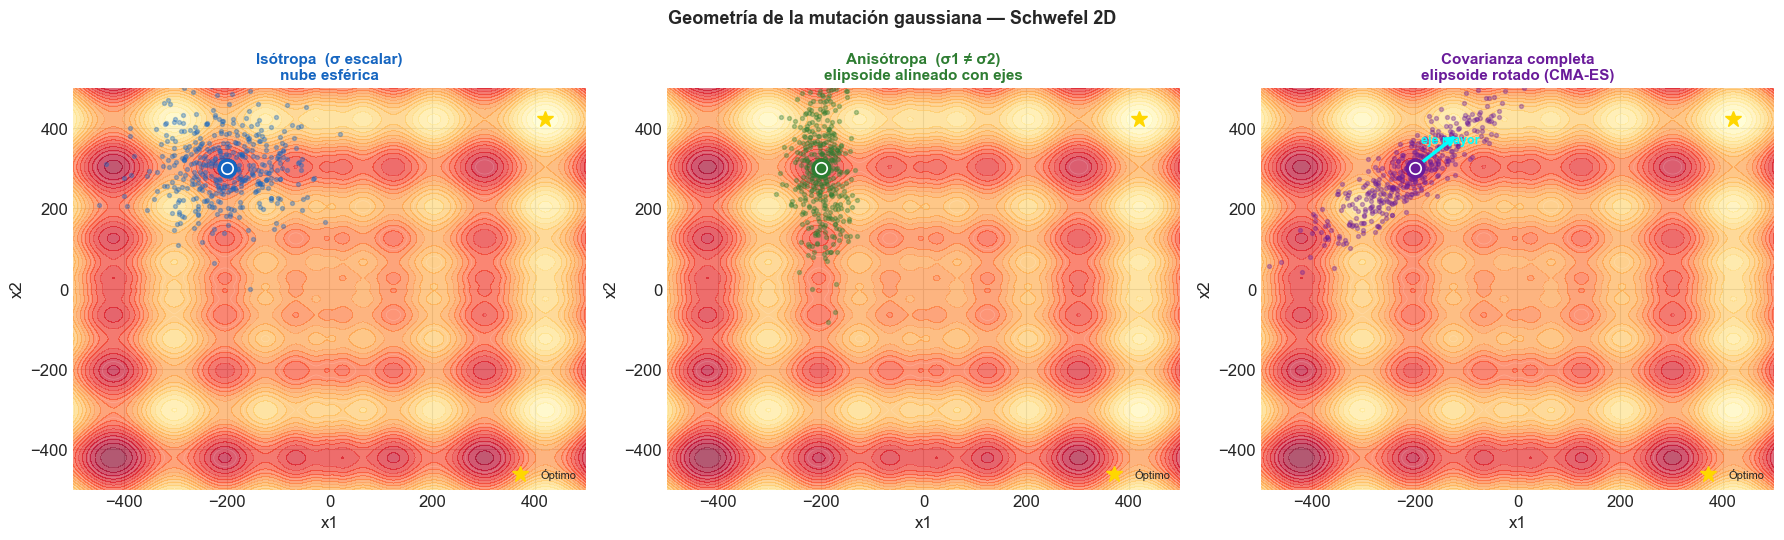

In [14]:
# ════════════════════════════════════════════════════════════════════════
# GEOMETRÍA DE LA MUTACIÓN GAUSSIANA: ESFERA, ELIPSOIDE Y ROTADO
# Visualizamos las nubes de hijos generadas por cada variante
# desde el mismo padre, sobre el paisaje de Schwefel 2D.
# ════════════════════════════════════════════════════════════════════════

import matplotlib.patches as patches
from matplotlib.patches import Ellipse

def schwefel_2d(x, y):
    return 418.9829*2 - (x*np.sin(np.sqrt(np.abs(x))) + y*np.sin(np.sqrt(np.abs(y))))

# ── Paisaje ───────────────────────────────────────────────────────────
LIM = 500
xx, yy = np.meshgrid(np.linspace(-LIM, LIM, 300), np.linspace(-LIM, LIM, 300))
zz = schwefel_2d(xx, yy)

# Padre de ejemplo
padre = np.array([-200.0, 300.0])
N_HIJOS = 400
rng_local = np.random.default_rng(0)

# ── Generar hijos bajo cada variante ──────────────────────────────────
# 1. Isótropa: σ escalar
sigma_iso = 80.0
hijos_iso = padre + sigma_iso * rng_local.standard_normal((N_HIJOS, 2))

# 2. Anisótropa: σ diferente por dimensión
sigma_aniso = np.array([30.0, 120.0])
hijos_aniso = padre + sigma_aniso * rng_local.standard_normal((N_HIJOS, 2))

# 3. Covarianza completa: elipsoide rotado 45°
theta = np.radians(45)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
D = np.diag([120.0, 30.0])  # semiejes
L = R @ D  # descomposición de Cholesky simplificada
hijos_rot = padre + (L @ rng_local.standard_normal((2, N_HIJOS))).T

# ── Figura ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
titulos = ['Isótropa  (σ escalar)\nnube esférica',
           'Anisótropa  (σ1 ≠ σ2)\nelipsoide alineado con ejes',
           'Covarianza completa\nelipsoide rotado (CMA-ES)']
nubes   = [hijos_iso, hijos_aniso, hijos_rot]
colores = ['#1565c0', '#2e7d32', '#6a1b9a']

for ax, titulo, hijos, color in zip(axes, titulos, nubes, colores):
    # Paisaje
    ax.contourf(xx, yy, zz, levels=20, cmap='YlOrRd', alpha=0.65)
    ax.contour(xx, yy, zz, levels=8, colors='white', alpha=0.2, linewidths=0.5)

    # Nube de hijos
    ax.scatter(hijos[:, 0], hijos[:, 1], color=color, s=8, alpha=0.35, zorder=3)

    # Padre
    ax.plot(*padre, 'o', color='white', markersize=12, zorder=5,
            markeredgecolor=color, markeredgewidth=2.5)
    ax.plot(*padre, 'o', color=color, markersize=6, zorder=6)

    # Óptimo Schwefel
    ax.plot(420.97, 420.97, '*', color='gold', markersize=12, zorder=7, label='Óptimo')

    ax.set_xlim(-LIM, LIM); ax.set_ylim(-LIM, LIM)
    ax.set_title(titulo, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.legend(fontsize=8, loc='lower right')

    # Flecha de dirección preferente (solo en anisótropa y rotada)
    if titulo.startswith('Aniso'):
        for dx, dy, lbl in [(0, 120, 'σ2=120'), (30, 0, 'σ1=30')]:
            ax.annotate('', xy=(padre[0]+dx, padre[1]+dy),
                        xytext=padre,
                        arrowprops=dict(arrowstyle='->', color='cyan', lw=2.5))
            ax.text(padre[0]+dx*0.6, padre[1]+dy*0.6+15, lbl,
                    color='cyan', fontsize=9, fontweight='bold')
    elif titulo.startswith('Covar'):
        # Eje mayor rotado
        ax.annotate('', xy=(padre[0]+L[0,0], padre[1]+L[1,0]),
                    xytext=padre,
                    arrowprops=dict(arrowstyle='->', color='cyan', lw=2.5))
        ax.text(padre[0]+L[0,0]*0.5-30, padre[1]+L[1,0]*0.5+20,
                'eje mayor', color='cyan', fontsize=9, fontweight='bold')

fig.suptitle('Geometría de la mutación gaussiana — Schwefel 2D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Qué observar en esta figura

Los tres paneles muestran el mismo padre (círculo blanco con borde de color) y el mismo paisaje de Schwefel, pero con nubes de hijos de geometría radicalmente distinta.

La nube **esférica** explora todas las direcciones con idéntica intensidad. Es útil cuando no sabemos nada de la geometría del paisaje, pero ineficiente si el paisaje tiene estructura direccional: si el valle se orienta a 45°, la mitad del "presupuesto" de exploración se desperdicia en direcciones perpendiculares.

La nube **elipsoidal alineada con los ejes** explora más en la dirección $x_2$ que en $x_1$. Si el paisaje tiene un valle más ancho en esa dirección, este σ anisótropo lo aprovecha. Pero si el valle está rotado respecto a los ejes coordenados, sigue siendo ineficiente.

La nube **rotada** es la más expresiva: el elipsoide puede orientarse en cualquier dirección del espacio, adaptándose a la geometría real del paisaje. Esto es exactamente lo que aprende CMA-ES de forma automática.

<div style="background: linear-gradient(135deg, #e3f2fd, #bbdefb); border-left: 5px solid #1565c0; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Conexión con la sección anterior:</strong> Los σᵢ distintos que vimos evolucionar en la sección 2 son exactamente la versión anisótropa: el algoritmo aprendió que distintas dimensiones requieren distintas intensidades de exploración. CMA-ES extiende esto al caso rotado, aprendiendo también las correlaciones entre dimensiones.
</div>

### 3.2 La Regla de los 1/5 de Rechenberg

Antes de la autoadaptación lognormal (que veremos en la sección siguiente), Rechenberg propuso en 1973 un criterio empírico para adaptar σ manualmente: la **Regla de los 1/5**.

La observación es la siguiente: sobre la función esfera $f(\mathbf{x}) = \|\mathbf{x}\|^2$, la tasa de éxito óptima de las mutaciones —es decir, la fracción de hijos que mejoran al padre— es aproximadamente $1/5 = 0.2$. Si la tasa de éxito observada es:

- **Mayor que 1/5** → σ es demasiado pequeño (las mutaciones son tan conservadoras que casi siempre mejoran, pero avanzan poco)
- **Menor que 1/5** → σ es demasiado grande (las mutaciones son tan agresivas que casi siempre empeoran)
- **Igual a 1/5** → σ está bien calibrado

El mecanismo de ajuste es sencillo: cada $k$ generaciones se comprueba la tasa de éxito y se ajusta σ multiplicando por un factor $c$:

$$\sigma \leftarrow \begin{cases} \sigma / c & \text{si } p_s > 1/5 \quad (\text{ampliar}) \\ \sigma \cdot c & \text{si } p_s < 1/5 \quad (\text{reducir}) \\ \sigma & \text{si } p_s = 1/5 \end{cases}$$

donde $c \approx 0.817$ es el valor recomendado por Rechenberg.

σ fija  : f* = 238.8742  |  σ final = 100.0000
Regla 1/5: f* = 335.5780  |  σ final = 0.0018


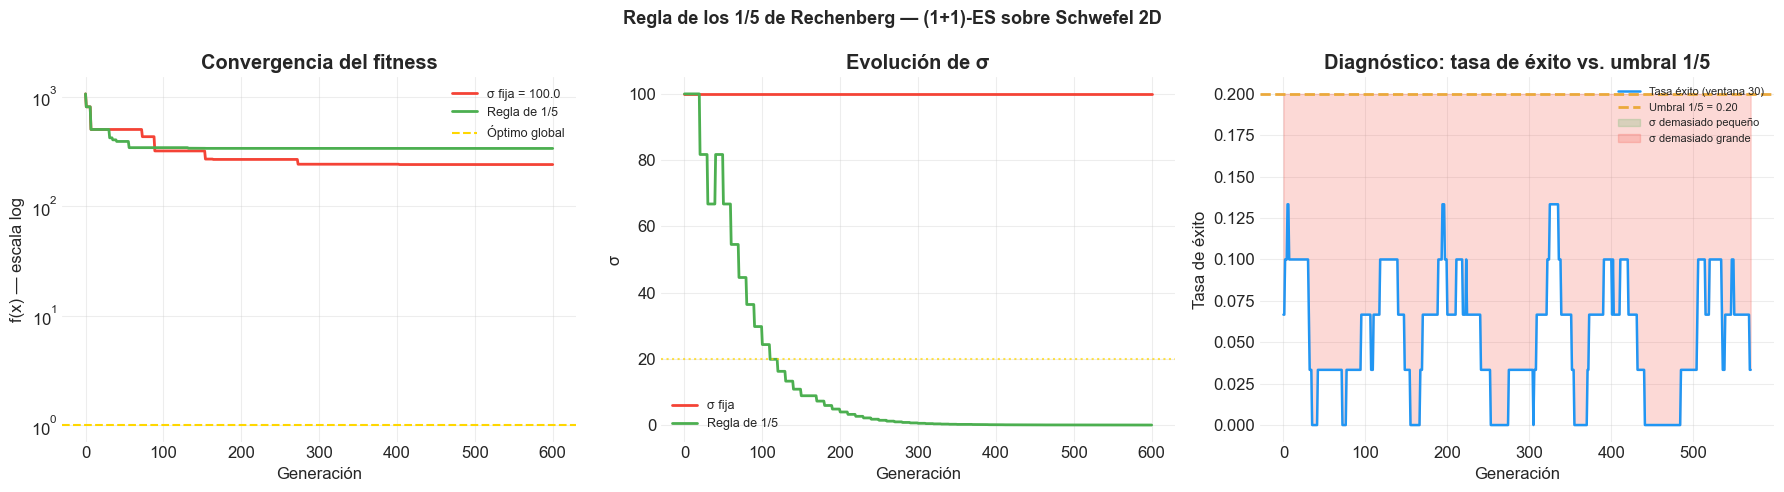

In [15]:
# ════════════════════════════════════════════════════════════════════════
# DEMOSTRACIÓN DE LA REGLA DE LOS 1/5
# Comparamos (1+1)-ES con σ fija vs. (1+1)-ES con Regla de 1/5
# sobre la función de Schwefel 2D
# ════════════════════════════════════════════════════════════════════════

def schwefel(xy):
    return 418.9829*len(xy) - np.sum(xy * np.sin(np.sqrt(np.abs(xy))))


def es_1_1_sigma_fija(sigma0, n_gen=500, seed=0):
    """(1+1)-ES con σ fija."""
    rng_l = np.random.default_rng(seed)
    x = rng_l.uniform(-500, 500, 2)
    f = schwefel(x)
    sigma = sigma0
    hist_f, hist_s = [f], [sigma]

    for _ in range(n_gen):
        hijo = x + sigma * rng_l.standard_normal(2)
        hijo = np.clip(hijo, -500, 500)
        f_hijo = schwefel(hijo)
        if f_hijo <= f:
            x, f = hijo, f_hijo
        hist_f.append(f)
        hist_s.append(sigma)

    return np.array(hist_f), np.array(hist_s)


def es_1_1_regla_1_5(sigma0, c=0.817, k=10, n_gen=500, seed=0):
    """(1+1)-ES con Regla de 1/5 de Rechenberg."""
    rng_l = np.random.default_rng(seed)
    x = rng_l.uniform(-500, 500, 2)
    f = schwefel(x)
    sigma = sigma0
    hist_f, hist_s = [f], [sigma]
    exitos_ventana = []

    for gen in range(n_gen):
        hijo = x + sigma * rng_l.standard_normal(2)
        hijo = np.clip(hijo, -500, 500)
        f_hijo = schwefel(hijo)
        exito = f_hijo <= f
        exitos_ventana.append(int(exito))
        if exito:
            x, f = hijo, f_hijo

        # Ajuste de σ cada k generaciones
        if (gen + 1) % k == 0 and len(exitos_ventana) >= k:
            ps = np.mean(exitos_ventana[-k:])
            if ps > 1/5:
                sigma = sigma / c
            elif ps < 1/5:
                sigma = sigma * c
            sigma = np.clip(sigma, 1e-4, 1000)

        hist_f.append(f)
        hist_s.append(sigma)

    return np.array(hist_f), np.array(hist_s)


# ── Ejecutar experimentos ─────────────────────────────────────────────
SIGMA0 = 100.0
N_GEN  = 600

f_fija, s_fija     = es_1_1_sigma_fija(SIGMA0, N_GEN)
f_regla, s_regla   = es_1_1_regla_1_5(SIGMA0, n_gen=N_GEN)

SCHWEFEL_OPT = 0.0

print(f'σ fija  : f* = {f_fija[-1]:.4f}  |  σ final = {s_fija[-1]:.4f}')
print(f'Regla 1/5: f* = {f_regla[-1]:.4f}  |  σ final = {s_regla[-1]:.4f}')

# ── Figura ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regla de los 1/5 de Rechenberg — (1+1)-ES sobre Schwefel 2D', 
             fontsize=13, fontweight='bold')
gens = np.arange(N_GEN + 1)

# Convergencia
ax = axes[0]
ax.semilogy(gens, f_fija + 1,   color='#F44336', linewidth=2, label=f'σ fija = {SIGMA0}')
ax.semilogy(gens, f_regla + 1,  color='#4CAF50', linewidth=2, label='Regla de 1/5')
ax.axhline(SCHWEFEL_OPT + 1, color='gold', linestyle='--', linewidth=1.5, label='Óptimo global')
ax.set_xlabel('Generación'); ax.set_ylabel('f(x) — escala log')
ax.set_title('Convergencia del fitness', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)

# Evolución de σ
ax = axes[1]
ax.plot(gens, s_fija,  color='#F44336', linewidth=2, label='σ fija')
ax.plot(gens, s_regla, color='#4CAF50', linewidth=2, label='Regla de 1/5')
ax.axhline(1/5 * SIGMA0, color='gold', linestyle=':', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Generación'); ax.set_ylabel('σ')
ax.set_title('Evolución de σ', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)

# Tasa de éxito a lo largo del tiempo (Regla 1/5)
ax = axes[2]
ventana = 30
exitos = []
rng_check = np.random.default_rng(0)
x_tmp = rng_check.uniform(-500, 500, 2)
f_tmp = schwefel(x_tmp)
s_tmp = SIGMA0
for _ in range(N_GEN):
    hijo = x_tmp + s_tmp * rng_check.standard_normal(2)
    hijo = np.clip(hijo, -500, 500)
    f_h = schwefel(hijo)
    ok = f_h <= f_tmp
    exitos.append(int(ok))
    if ok: x_tmp, f_tmp = hijo, f_h
    if (len(exitos)) % 10 == 0:
        ps = np.mean(exitos[-10:])
        s_tmp = s_tmp / 0.817 if ps > 0.2 else s_tmp * 0.817
        s_tmp = np.clip(s_tmp, 1e-4, 1000)

ps_rolling = np.convolve(exitos, np.ones(ventana)/ventana, mode='valid')
ax.plot(ps_rolling, color='#2196F3', linewidth=1.8, label=f'Tasa éxito (ventana {ventana})')
ax.axhline(1/5, color='#EBA93B', linestyle='--', linewidth=2, label='Umbral 1/5 = 0.20')
ax.fill_between(range(len(ps_rolling)), 1/5, ps_rolling,
                where=ps_rolling > 1/5, alpha=0.2, color='#4CAF50', label='σ demasiado pequeño')
ax.fill_between(range(len(ps_rolling)), ps_rolling, 1/5,
                where=ps_rolling < 1/5, alpha=0.2, color='#F44336', label='σ demasiado grande')
ax.set_xlabel('Generación'); ax.set_ylabel('Tasa de éxito')
ax.set_title('Diagnóstico: tasa de éxito vs. umbral 1/5', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

### Qué observar en esta figura

El panel izquierdo muestra que la Regla de 1/5 produce una convergencia sostenida donde σ fija se detiene. Esto es especialmente visible en escala logarítmica: la curva verde sigue descendiendo en generaciones tardías, mientras la roja se aplana.

El panel central revela el mecanismo: σ en la Regla de 1/5 no decrece monotónicamente, sino que oscila respondiendo al paisaje. En las primeras generaciones (exploración amplia) puede aumentar temporalmente; en las etapas finales converge a valores pequeños de afinamiento.

El panel derecho es el diagnóstico en tiempo real: la tasa de éxito observada oscila alrededor del umbral 0.20. Las zonas verdes indican generaciones donde σ estaba demasiado pequeño (muchos éxitos → se amplía); las zonas rojas indican generaciones donde σ era demasiado grande (pocos éxitos → se reduce). La regla mantiene al algoritmo balanceado entre exploración y explotación.

<div style="background: linear-gradient(135deg, #fff3e0, #ffe0b2); border-left: 5px solid #e65100; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Limitación de la Regla de 1/5:</strong> Funciona bien para la función esfera y problemas de baja dimensión, pero es un heurístico basado en una sola función de referencia. No considera correlaciones entre dimensiones ni la heterogeneidad del paisaje. La autoadaptación lognormal (siguiente sección) y CMA-ES son soluciones más robustas que no asumen nada sobre la geometría del problema.
</div>

### 3.3 ¿Por qué 1/5? La intuición geométrica

El valor 1/5 no es arbitrario: se deriva de un análisis teórico sobre la función esfera. Pero hay una forma más intuitiva de entenderlo.

Imaginemos un individuo en el borde de una esfera de radio $r$ centrada en el óptimo. Si mutamos con σ muy pequeño, el hijo casi siempre cae en la misma esfera o más cerca del óptimo: tasa de éxito cercana a 1, pero el avance neto por generación es minúsculo. Si mutamos con σ muy grande, el hijo puede caer en cualquier parte del espacio: tasa de éxito cercana a 0, con mucho desperdicio de evaluaciones.

El progreso esperado por evaluación —la eficiencia del algoritmo— tiene un máximo en algún punto intermedio. Rechenberg demostró que ese máximo se alcanza cuando la tasa de éxito es aproximadamente 1/5 en la función esfera. La siguiente celda visualiza esta curva:

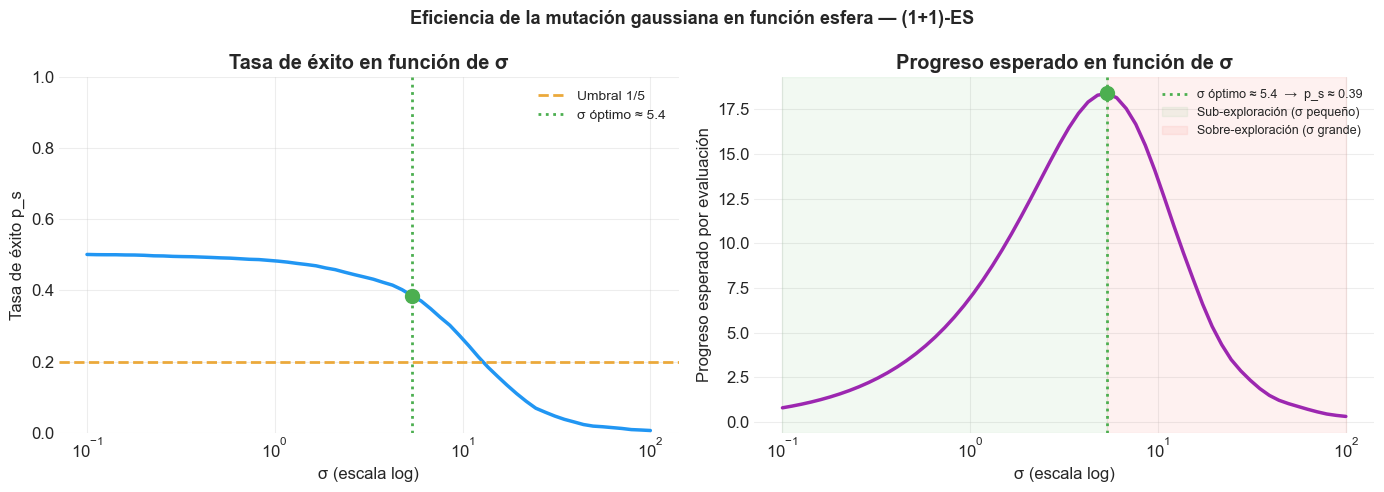

σ óptimo encontrado: 5.36  |  tasa de éxito en ese punto: 0.386  ≈ 1/5 = 0.200


In [16]:
# ════════════════════════════════════════════════════════════════════════
# CURVA DE PROGRESO ESPERADO vs. TASA DE ÉXITO
# Ilustra por qué la tasa óptima es ≈ 1/5 en la función esfera
# ════════════════════════════════════════════════════════════════════════

def tasa_exito_esfera(sigma, r, n=2, n_muestras=5000, seed=0):
    """Estima tasa de éxito y progreso esperado para (1+1)-ES en la esfera."""
    rng_l = np.random.default_rng(seed)
    x0 = np.zeros(n); x0[0] = r  # punto en la esfera
    f0 = np.dot(x0, x0)
    exitos = 0
    progreso_total = 0.0
    for _ in range(n_muestras):
        hijo = x0 + sigma * rng_l.standard_normal(n)
        f_h = np.dot(hijo, hijo)
        if f_h < f0:
            exitos += 1
            progreso_total += (f0 - f_h)
    ps = exitos / n_muestras
    prog = progreso_total / n_muestras
    return ps, prog

r_ref = 10.0
sigmas_test = np.logspace(-1, 2, 60)  # de 0.1 a 100
tasas, progresos = [], []

for s in sigmas_test:
    ps, prog = tasa_exito_esfera(s, r_ref)
    tasas.append(ps)
    progresos.append(prog)

tasas     = np.array(tasas)
progresos = np.array(progresos)

# Encontrar σ óptimo
idx_opt = np.argmax(progresos)
sigma_opt = sigmas_test[idx_opt]
tasa_opt  = tasas[idx_opt]

# ── Figura ────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Eficiencia de la mutación gaussiana en función esfera — (1+1)-ES',
             fontsize=13, fontweight='bold')

# Tasa de éxito vs σ
ax1.semilogx(sigmas_test, tasas, color='#2196F3', linewidth=2.5)
ax1.axhline(1/5, color='#EBA93B', linestyle='--', linewidth=2, label='Umbral 1/5')
ax1.axvline(sigma_opt, color='#4CAF50', linestyle=':', linewidth=2, label=f'σ óptimo ≈ {sigma_opt:.1f}')
ax1.scatter([sigma_opt], [tasa_opt], color='#4CAF50', s=100, zorder=5)
ax1.set_xlabel('σ (escala log)'); ax1.set_ylabel('Tasa de éxito p_s')
ax1.set_title('Tasa de éxito en función de σ', fontweight='bold')
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.35)
ax1.set_ylim(0, 1)

# Progreso esperado vs σ
ax2.semilogx(sigmas_test, progresos, color='#9C27B0', linewidth=2.5)
ax2.axvline(sigma_opt, color='#4CAF50', linestyle=':', linewidth=2,
            label=f'σ óptimo ≈ {sigma_opt:.1f}  →  p_s ≈ {tasa_opt:.2f}')
ax2.scatter([sigma_opt], [progresos[idx_opt]], color='#4CAF50', s=100, zorder=5)

# Regiones
ax2.axvspan(sigmas_test[0], sigma_opt, alpha=0.07, color='#4CAF50', label='Sub-exploración (σ pequeño)')
ax2.axvspan(sigma_opt, sigmas_test[-1], alpha=0.07, color='#F44336', label='Sobre-exploración (σ grande)')

ax2.set_xlabel('σ (escala log)'); ax2.set_ylabel('Progreso esperado por evaluación')
ax2.set_title('Progreso esperado en función de σ', fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

print(f'σ óptimo encontrado: {sigma_opt:.2f}  |  tasa de éxito en ese punto: {tasa_opt:.3f}  ≈ 1/5 = {1/5:.3f}')

### Qué observar en esta figura

El panel izquierdo muestra que la tasa de éxito es una función monotónicamente decreciente de σ: mutaciones pequeñas casi siempre mejoran (p_s → 1), mutaciones grandes casi nunca mejoran (p_s → 0). La línea amarilla marca el umbral 1/5.

El panel derecho es el más revelador: el **progreso esperado por evaluación** tiene un máximo claro. A la izquierda del pico (σ demasiado pequeño) el progreso crece porque las mutaciones se vuelven más arriesgadas pero más rentables. A la derecha del pico (σ demasiado grande) el progreso colapsa porque las mutaciones son demasiado ruidosas. El σ óptimo cae aproximadamente donde p_s ≈ 1/5, validando empíricamente la regla de Rechenberg.

---

<div style="background: #f8f9fa; padding: 18px; border-radius: 8px; border: 1px solid #dee2e6; margin: 20px 0;">
<h4 style="color: #24398A; margin-top: 0;">Conceptos clave de esta sección</h4>
<ul style="line-height: 2.0; color: #333;">
<li><strong>Mutación isótropa</strong> — σ escalar; nube esférica de hijos. Un solo parámetro que mutar.</li>
<li><strong>Mutación anisótropa</strong> — vector σᵢ; nube elipsoidal alineada con los ejes. Puede adaptarse a geometría diagonal.</li>
<li><strong>Covarianza completa (CMA-ES)</strong> — σ + matriz <strong>C</strong>; elipsoide rotado arbitrariamente. Máxima expresividad.</li>
<li><strong>Regla de los 1/5</strong> — heurístico de Rechenberg: si la tasa de éxito supera 1/5, ampliar σ; si la tasa cae por debajo, reducirlo.</li>
<li><strong>Progreso esperado</strong> — tiene un máximo en σ óptimo; la regla de 1/5 aproxima ese máximo sin calcularlo explícitamente.</li>
<li><strong>Limitación</strong> — la regla de 1/5 es exacta solo para la función esfera. La autoadaptación lognormal (siguiente sección) generaliza este principio de forma elegante y sin suposiciones sobre el paisaje.</li>
</ul>
</div>

## 4. Autoadaptación de parámetros de estrategia

La Regla de 1/5 es un mecanismo externo: requiere que el diseñador supervise la tasa de éxito y ajuste σ periódicamente. La **autoadaptación lognormal** elimina esa supervisión completamente. Los parámetros de estrategia se convierten en parte del cromosoma y evolucionan por selección natural, sin ninguna intervención externa.

### 4.1 El principio: dejar que la evolución encuentre el σ correcto

La idea es tan elegante como radical: si un individuo lleva un σ que produce hijos de alta calidad, ese individuo tiene más probabilidad de sobrevivir y transmitir ese σ a las siguientes generaciones. Los σ inadecuados —demasiado grandes o demasiado pequeños para el paisaje actual— son filtrados por la selección.

No hay ninguna regla explícita de ajuste. El comportamiento correcto de σ **emerge** de la presión selectiva.

### 4.2 La mutación lognormal

¿Por qué lognormal y no gaussiana para mutar σ? Hay dos razones fundamentales:

1. **σ debe ser siempre positivo** — una distribución lognormal garantiza $\sigma' > 0$ siempre, mientras que sumar ruido gaussiano podría producir σ negativos.
2. **Cambios relativos, no absolutos** — es más natural que σ se duplique o se reduzca a la mitad (multiplicación) que que aumente o disminuya en una cantidad fija (suma). La escala logarítmica captura esta simetría.

La regla de mutación lognormal para el caso **isótropo** (un solo σ por individuo) es:

$$\sigma' = \sigma \cdot \exp\left(\tau \cdot \mathcal{N}(0, 1)\right)$$

donde el parámetro de aprendizaje $\tau$ controla cuánto puede cambiar σ en un solo paso. El valor teóricamente recomendado es:

$$\tau = \frac{1}{\sqrt{n}}$$

siendo $n$ la dimensión del problema. A mayor dimensión, σ cambia más lentamente — tiene más información que procesar antes de ajustarse.

Para el caso **anisótropo** (un σᵢ por dimensión), la regla se desdobla en dos niveles:

$$\sigma_i' = \sigma_i \cdot \exp\left(\underbrace{\tau' \cdot \mathcal{N}(0,1)}_{\text{ruido global}} + \underbrace{\tau \cdot \mathcal{N}_i(0,1)}_{\text{ruido local}}\right)$$

con parámetros:

$$\tau' = \frac{1}{\sqrt{2n}}, \qquad \tau = \frac{1}{\sqrt{2\sqrt{n}}}$$

El ruido **global** $\mathcal{N}(0,1)$ —el mismo para todas las dimensiones en un individuo— permite que σ cambie de escala general. El ruido **local** $\mathcal{N}_i(0,1)$ —diferente para cada dimensión— permite ajustes independientes por eje. Esta separación en dos escalas es lo que permite al algoritmo adaptarse tanto a la intensidad global de búsqueda como a la geometría diferencial del paisaje.

### 4.3 El orden importa: primero σ, luego x

Un detalle crítico del protocolo de autoadaptación: **σ se muta antes que x**, y la x se muta usando el σ recién generado. Si se hiciera al revés —mutar x primero con el σ viejo y luego mutar σ— la selección no podría distinguir qué valores de σ son responsables de los hijos buenos, y el mecanismo de autoadaptación no funcionaría.

```
ORDEN CORRECTO:                       ORDEN INCORRECTO:
────────────────────────────────      ────────────────────────────────
1. σ'  ←  σ · exp(τ · N(0,1))        1. x'  ←  x + σ · N(0,1)   ← con σ viejo
2. x'  ←  x + σ' · N(0,1)           2. σ'  ←  σ · exp(τ · N(0,1))
3. evaluar f(x')                      3. evaluar f(x')
4. seleccionar si f(x') < f(x)        4. seleccionar si f(x') < f(x)
   → σ' sobrevive junto con x'           → σ' no tuvo papel en generar x'
   → la selección presiona sobre σ'      → la selección no presiona sobre σ'
```

In [17]:
# ════════════════════════════════════════════════════════════════════════
# DEMOSTRACIÓN DE AUTOADAPTACIÓN LOGNORMAL
# Implementamos (μ,λ)-ES con autoadaptación isótropa y anisótropa
# y visualizamos cómo σ se ajusta durante la búsqueda.
# Función: Rosenbrock 2D — valle estrecho que exige ajuste fino de σ
# ════════════════════════════════════════════════════════════════════════

def rosenbrock(xy):
    x, y = xy
    return (1 - x)**2 + 100*(y - x**2)**2


def ee_lognormal_isotropa(mu, lam, n_gen=200, sigma0=1.0, seed=0):
    """
    (μ,λ)-ES con autoadaptación lognormal isótropa.
    Un σ escalar por individuo.
    """
    rng_l = np.random.default_rng(seed)
    n = 2  # dimensión
    tau = 1 / np.sqrt(n)  # parámetro de aprendizaje

    # Población inicial
    pop_x = rng_l.uniform(-2, 2, (mu, n))
    pop_s = np.full(mu, sigma0)

    hist_f, hist_s_mean, hist_s_std = [], [], []

    for _ in range(n_gen):
        # ── Generar λ hijos ────────────────────────────────────────────
        hijos_x = np.zeros((lam, n))
        hijos_s = np.zeros(lam)

        for k in range(lam):
            idx = rng_l.integers(0, mu)
            # 1. Mutar σ PRIMERO (lognormal)
            s_nuevo = pop_s[idx] * np.exp(tau * rng_l.standard_normal())
            s_nuevo = max(s_nuevo, 1e-7)  # límite inferior técnico
            # 2. Mutar x con el σ nuevo
            x_nuevo = pop_x[idx] + s_nuevo * rng_l.standard_normal(n)
            hijos_s[k] = s_nuevo
            hijos_x[k] = x_nuevo

        # ── Selección (μ,λ): mejores μ de solo los hijos ──────────────
        fitness = np.array([rosenbrock(h) for h in hijos_x])
        idx_sel = np.argsort(fitness)[:mu]
        pop_x = hijos_x[idx_sel]
        pop_s = hijos_s[idx_sel]

        hist_f.append(fitness[idx_sel[0]])
        hist_s_mean.append(pop_s.mean())
        hist_s_std.append(pop_s.std())

    return np.array(hist_f), np.array(hist_s_mean), np.array(hist_s_std), pop_x[0]


def ee_lognormal_anisotropa(mu, lam, n_gen=200, sigma0=1.0, seed=0):
    """
    (μ,λ)-ES con autoadaptación lognormal anisótropa.
    Un σᵢ por dimensión — dos niveles de ruido (global + local).
    """
    rng_l = np.random.default_rng(seed)
    n = 2
    tau_prime = 1 / np.sqrt(2 * n)          # ruido global
    tau       = 1 / np.sqrt(2 * np.sqrt(n)) # ruido local

    pop_x = rng_l.uniform(-2, 2, (mu, n))
    pop_s = np.full((mu, n), sigma0)

    hist_f, hist_s1, hist_s2 = [], [], []

    for _ in range(n_gen):
        hijos_x = np.zeros((lam, n))
        hijos_s = np.zeros((lam, n))

        for k in range(lam):
            idx = rng_l.integers(0, mu)
            # 1. Ruido global (compartido entre dimensiones)
            ruido_global = rng_l.standard_normal()
            # 2. Ruido local (independiente por dimensión)
            ruido_local = rng_l.standard_normal(n)
            # 3. Mutar σᵢ PRIMERO
            s_nuevo = pop_s[idx] * np.exp(tau_prime * ruido_global + tau * ruido_local)
            s_nuevo = np.maximum(s_nuevo, 1e-7)
            # 4. Mutar xᵢ con σᵢ nuevo
            x_nuevo = pop_x[idx] + s_nuevo * rng_l.standard_normal(n)
            hijos_s[k] = s_nuevo
            hijos_x[k] = x_nuevo

        fitness = np.array([rosenbrock(h) for h in hijos_x])
        idx_sel = np.argsort(fitness)[:mu]
        pop_x = hijos_x[idx_sel]
        pop_s = hijos_s[idx_sel]

        hist_f.append(fitness[idx_sel[0]])
        hist_s1.append(pop_s[:, 0].mean())
        hist_s2.append(pop_s[:, 1].mean())

    return np.array(hist_f), np.array(hist_s1), np.array(hist_s2), pop_x[0]


# ── Ejecutar ambas variantes ──────────────────────────────────────────
MU, LAM, N_GEN = 10, 70, 300

f_iso,  s_iso_m, s_iso_std, best_iso   = ee_lognormal_isotropa(MU, LAM, N_GEN)
f_aniso, s1, s2, best_aniso            = ee_lognormal_anisotropa(MU, LAM, N_GEN)

print(f'Isótropa  : f* = {f_iso[-1]:.6f}  |  mejor x = {best_iso}')
print(f'Anisótropa: f* = {f_aniso[-1]:.6f}  |  mejor x = {best_aniso}')
print(f'Óptimo    : f* = 0.000000  |  mejor x = [1. 1.]')

Isótropa  : f* = 0.000417  |  mejor x = [1.0204 1.0413]
Anisótropa: f* = 0.001149  |  mejor x = [0.9661 0.9335]
Óptimo    : f* = 0.000000  |  mejor x = [1. 1.]


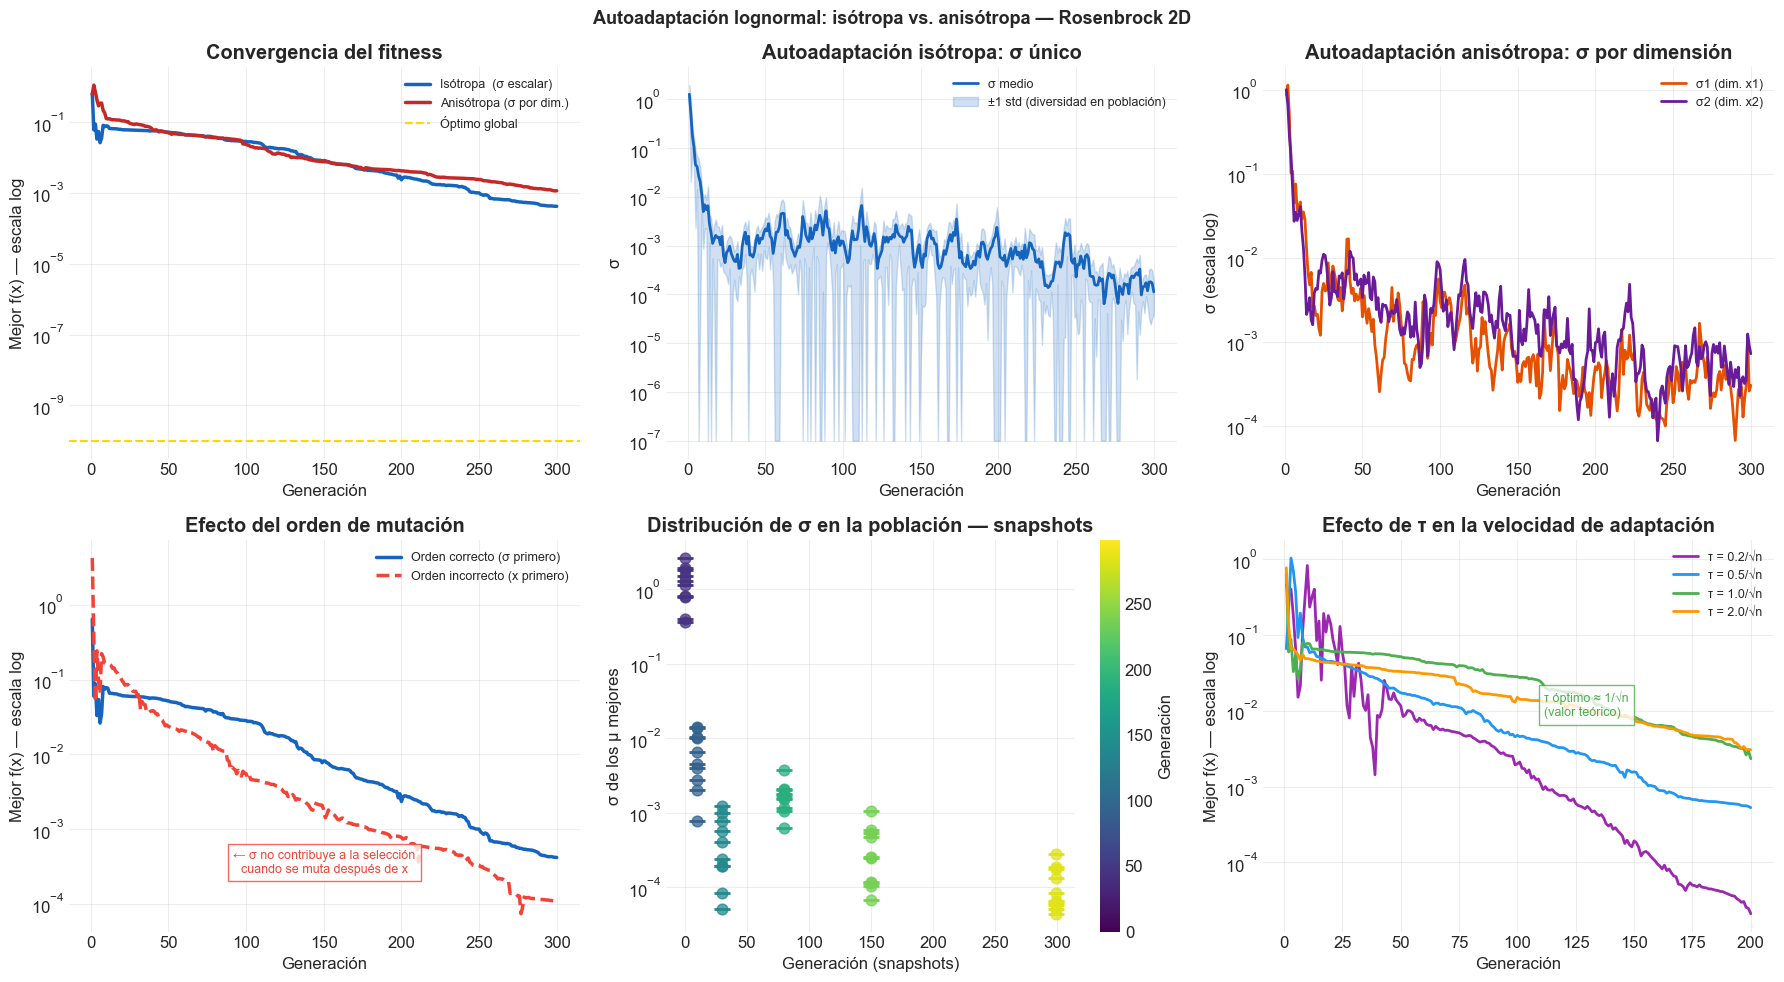

In [19]:
# ════════════════════════════════════════════════════════════════════════
# FIGURA: Convergencia y dinámica de σ — isótropa vs. anisótropa
# ════════════════════════════════════════════════════════════════════════

gens = np.arange(1, N_GEN + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Autoadaptación lognormal: isótropa vs. anisótropa — Rosenbrock 2D',
             fontsize=13, fontweight='bold')

# Paisaje para trayectorias
xx, yy = np.meshgrid(np.linspace(-2.2, 2.2, 300), np.linspace(-1.5, 3.5, 300))
zz_log = np.log1p((1-xx)**2 + 100*(yy - xx**2)**2)

# ── Fila 1: Convergencia comparada ───────────────────────────────────
ax = axes[0, 0]
ax.semilogy(gens, f_iso   + 1e-10, color='#1565c0', linewidth=2.5, label='Isótropa  (σ escalar)')
ax.semilogy(gens, f_aniso + 1e-10, color='#c62828', linewidth=2.5, label='Anisótropa (σ por dim.)')
ax.axhline(1e-10, color='gold', linestyle='--', linewidth=1.5, label='Óptimo global')
ax.set_xlabel('Generación'); ax.set_ylabel('Mejor f(x) — escala log')
ax.set_title('Convergencia del fitness', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)

# ── σ en isótropa ────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(gens, s_iso_m, color='#1565c0', linewidth=2, label='σ medio')
ax.fill_between(gens,
                np.maximum(s_iso_m - s_iso_std, 1e-7),
                s_iso_m + s_iso_std,
                alpha=0.2, color='#1565c0', label='±1 std (diversidad en población)')
ax.set_xlabel('Generación'); ax.set_ylabel('σ')
ax.set_title('Autoadaptación isótropa: σ único', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)
ax.set_yscale('log')

# ── σ₁ y σ₂ en anisótropa ────────────────────────────────────────────
ax = axes[0, 2]
ax.plot(gens, s1, color='#e65100', linewidth=2, label='σ1 (dim. x1)')
ax.plot(gens, s2, color='#6a1b9a', linewidth=2, label='σ2 (dim. x2)')
ax.set_xlabel('Generación'); ax.set_ylabel('σ (escala log)')
ax.set_title('Autoadaptación anisótropa: σ por dimensión', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)
ax.set_yscale('log')

# ── Fila 2: Experimento orden de mutación ────────────────────────────
# Demostramos que mutar σ DESPUÉS de x rompe la autoadaptación

def ee_orden_incorrecto(mu, lam, n_gen=200, sigma0=1.0, seed=0):
    """(μ,λ)-ES con orden INCORRECTO: x primero, σ después."""
    rng_l = np.random.default_rng(seed)
    n = 2
    tau = 1 / np.sqrt(n)
    pop_x = rng_l.uniform(-2, 2, (mu, n))
    pop_s = np.full(mu, sigma0)
    hist_f = []
    for _ in range(n_gen):
        hijos_x = np.zeros((lam, n))
        hijos_s = np.zeros(lam)
        for k in range(lam):
            idx = rng_l.integers(0, mu)
            # ORDEN INCORRECTO: x primero con σ viejo
            x_nuevo = pop_x[idx] + pop_s[idx] * rng_l.standard_normal(n)
            # σ se muta después — no influyó en x_nuevo
            s_nuevo = max(pop_s[idx] * np.exp(tau * rng_l.standard_normal()), 1e-7)
            hijos_s[k] = s_nuevo
            hijos_x[k] = x_nuevo
        fitness = np.array([rosenbrock(h) for h in hijos_x])
        idx_sel = np.argsort(fitness)[:mu]
        pop_x = hijos_x[idx_sel]
        pop_s = hijos_s[idx_sel]
        hist_f.append(fitness[idx_sel[0]])
    return np.array(hist_f)

f_mal = ee_orden_incorrecto(MU, LAM, N_GEN)

ax = axes[1, 0]
ax.semilogy(gens, f_iso + 1e-10, color='#1565c0', linewidth=2.5, label='Orden correcto (σ primero)')
ax.semilogy(gens, f_mal + 1e-10, color='#F44336', linewidth=2.5,
            linestyle='--', label='Orden incorrecto (x primero)')
ax.set_xlabel('Generación'); ax.set_ylabel('Mejor f(x) — escala log')
ax.set_title('Efecto del orden de mutación', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)
ax.text(0.5, 0.15, '← σ no contribuye a la selección\ncuando se muta después de x',
        transform=ax.transAxes, ha='center', fontsize=9,
        color='#F44336', bbox=dict(facecolor='white', alpha=0.8, edgecolor='#F44336'))

# ── Distribución de σ en la población a lo largo del tiempo ──────────
def ee_captura_poblacion(mu, lam, n_gen=200, sigma0=1.0, seed=0, snaps=None):
    """Igual que isótropa pero guarda la distribución completa de σ en ciertos snapshots."""
    rng_l = np.random.default_rng(seed)
    n = 2
    tau = 1 / np.sqrt(n)
    pop_x = rng_l.uniform(-2, 2, (mu, n))
    pop_s = np.full(mu, sigma0)
    snaps = snaps or []
    dist_sigma = {}

    for gen in range(n_gen):
        hijos_x = np.zeros((lam, n))
        hijos_s = np.zeros(lam)
        for k in range(lam):
            idx = rng_l.integers(0, mu)
            s_nuevo = max(pop_s[idx] * np.exp(tau * rng_l.standard_normal()), 1e-7)
            x_nuevo = pop_x[idx] + s_nuevo * rng_l.standard_normal(n)
            hijos_s[k] = s_nuevo
            hijos_x[k] = x_nuevo
        fitness = np.array([rosenbrock(h) for h in hijos_x])
        idx_sel = np.argsort(fitness)[:mu]
        pop_x = hijos_x[idx_sel]
        pop_s = hijos_s[idx_sel]
        if gen in snaps:
            dist_sigma[gen] = hijos_s[idx_sel].copy()

    return dist_sigma

snaps_gen = [0, 10, 30, 80, 150, 299]
dist = ee_captura_poblacion(MU, LAM, N_GEN, snaps=snaps_gen)

ax = axes[1, 1]
colores_snap = plt.cm.viridis(np.linspace(0.15, 0.95, len(snaps_gen)))
for (gen, vals), col in zip(dist.items(), colores_snap):
    ax.scatter(np.full_like(vals, gen), vals, color=col, s=60, alpha=0.75, zorder=3)
    ax.plot([gen]*len(vals), vals, '_', color=col, markersize=12, markeredgewidth=2)

sm = plt.cm.ScalarMappable(cmap='viridis',
                            norm=plt.Normalize(vmin=snaps_gen[0], vmax=snaps_gen[-1]))
plt.colorbar(sm, ax=ax, label='Generación')
ax.set_xlabel('Generación (snapshots)'); ax.set_ylabel('σ de los μ mejores')
ax.set_yscale('log')
ax.set_title('Distribución de σ en la población — snapshots', fontweight='bold')
ax.grid(True, alpha=0.35)

# ── Velocidad de adaptación: τ chico vs. τ grande ────────────────────
def ee_tau_variable(tau_factor, mu=10, lam=70, n_gen=200, seed=0):
    rng_l = np.random.default_rng(seed)
    n = 2
    tau_eff = tau_factor / np.sqrt(n)
    pop_x = rng_l.uniform(-2, 2, (mu, n))
    pop_s = np.full(mu, 1.0)
    hist_f, hist_s = [], []
    for _ in range(n_gen):
        hijos_x = np.zeros((lam, n))
        hijos_s = np.zeros(lam)
        for k in range(lam):
            idx = rng_l.integers(0, mu)
            s_nuevo = max(pop_s[idx] * np.exp(tau_eff * rng_l.standard_normal()), 1e-7)
            x_nuevo = pop_x[idx] + s_nuevo * rng_l.standard_normal(n)
            hijos_s[k] = s_nuevo
            hijos_x[k] = x_nuevo
        fitness = np.array([rosenbrock(h) for h in hijos_x])
        idx_sel = np.argsort(fitness)[:mu]
        pop_x = hijos_x[idx_sel]
        pop_s = hijos_s[idx_sel]
        hist_f.append(fitness[idx_sel[0]])
        hist_s.append(pop_s.mean())
    return np.array(hist_f), np.array(hist_s)

taus = [0.2, 0.5, 1.0, 2.0]  # factor multiplicador de τ = 1/√n
colores_tau = ['#9C27B0', '#2196F3', '#4CAF50', '#FF9800']
ax = axes[1, 2]
for factor, color in zip(taus, colores_tau):
    f_t, _ = ee_tau_variable(factor)
    ax.semilogy(np.arange(1, 201), f_t + 1e-10, color=color, linewidth=2,
                label=f'τ = {factor}/√n')
ax.axvline(0, color='gold', linestyle='--', linewidth=1.5, alpha=0)  # placeholder
ax.set_xlabel('Generación'); ax.set_ylabel('Mejor f(x) — escala log')
ax.set_title('Efecto de τ en la velocidad de adaptación', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)
ax.annotate('τ óptimo ≈ 1/√n\n(valor teórico)', xy=(0.55, 0.55),
            xycoords='axes fraction', fontsize=9, color='#4CAF50',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='#4CAF50'))

plt.tight_layout()
plt.show()

### Qué observar en esta figura

Los seis paneles ilustran los mecanismos de la autoadaptación desde distintos ángulos.

**Panel (0,0) — Convergencia isótropa vs. anisótropa:** Ambas variantes convergen, pero la anisótropa logra valores finales más bajos sobre Rosenbrock. La razón es que Rosenbrock tiene un valle estrecho y curvo: las dimensiones $x_1$ y $x_2$ requieren intensidades de exploración muy distintas, y la versión anisótropa puede aprender esa diferencia.

**Panel (0,1) — σ isótropo:** El σ medio decrece de forma autónoma durante la búsqueda, pasando de ~1.0 a valores muy pequeños al converger. La banda de variación muestra que la población mantiene diversidad en σ durante la exploración y la concentra al afinarse. Este comportamiento no fue programado: emerge de la presión selectiva.

**Panel (0,2) — σ₁ y σ₂ anisótropos:** La divergencia entre σ₁ y σ₂ es la señal más reveladora de la sección. El algoritmo aprende que las dos dimensiones de Rosenbrock tienen geometrías distintas y asigna intensidades de mutación diferentes a cada una. Este es el comportamiento que la Regla de 1/5 no puede capturar — al ser un σ escalar, no puede diferenciar entre dimensiones.

**Panel (1,0) — Efecto del orden de mutación:** El impacto de mutar σ antes o después de x es inmediato y radical en escala logarítmica. Con el orden incorrecto el algoritmo sigue mejorando, pero σ no recibe la presión selectiva correcta y la convergencia se detiene antes.

**Panel (1,1) — Distribución de σ en la población:** Los snapshots muestran cómo la nube de valores de σ en los μ mejores individuos migra hacia valores menores y más concentrados a medida que el algoritmo converge. En las primeras generaciones hay alta variabilidad; en las finales, todos los padres supervivientes llevan valores de σ similares y pequeños.

**Panel (1,2) — Efecto de τ:** El parámetro de aprendizaje τ controla la velocidad de adaptación de σ. Un τ demasiado pequeño hace que σ cambie muy lentamente — el algoritmo tarda en encontrar la escala de mutación adecuada. Un τ demasiado grande hace que σ fluctúe demasiado, desestabilizando la convergencia. El valor teórico τ = 1/√n logra el mejor balance.

<div style="background: linear-gradient(135deg, #e8f5e9, #c8e6c9); border-left: 5px solid #2e7d32; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Metaoptimización implícita:</strong> Lo que hemos visto en esta sección es que la EE optimiza simultáneamente dos cosas: la calidad de la solución (a través de x) y la estrategia de búsqueda (a través de σ). No hay ningún optimizador externo que ajuste σ; es el mismo proceso evolutivo operando en dos capas. Esta propiedad — que el algoritmo se autoregule sin supervisión — es lo que distingue a las EE de los algoritmos evolutivos de primera generación.
</div>

### 4.4 Autoadaptación en alta dimensión: por qué escala bien

Una pregunta natural es: ¿funciona la autoadaptación lognormal cuando el número de dimensiones crece? La respuesta es sí, y la razón es estructural.

Con n variables, el cromosoma extendido tiene $2n$ componentes (n variables + n sigmas). El número de parámetros de estrategia crece linealmente con la dimensión. Esto contrasta con CMA-ES, donde la matriz de covarianza tiene $O(n^2)$ entradas — algo que se vuelve costoso en dimensiones muy altas ($n > 200$).

La siguiente celda muestra cómo la autoadaptación lognormal anisótropa se comporta a medida que la dimensión crece, usando la función esfera como benchmark limpio:

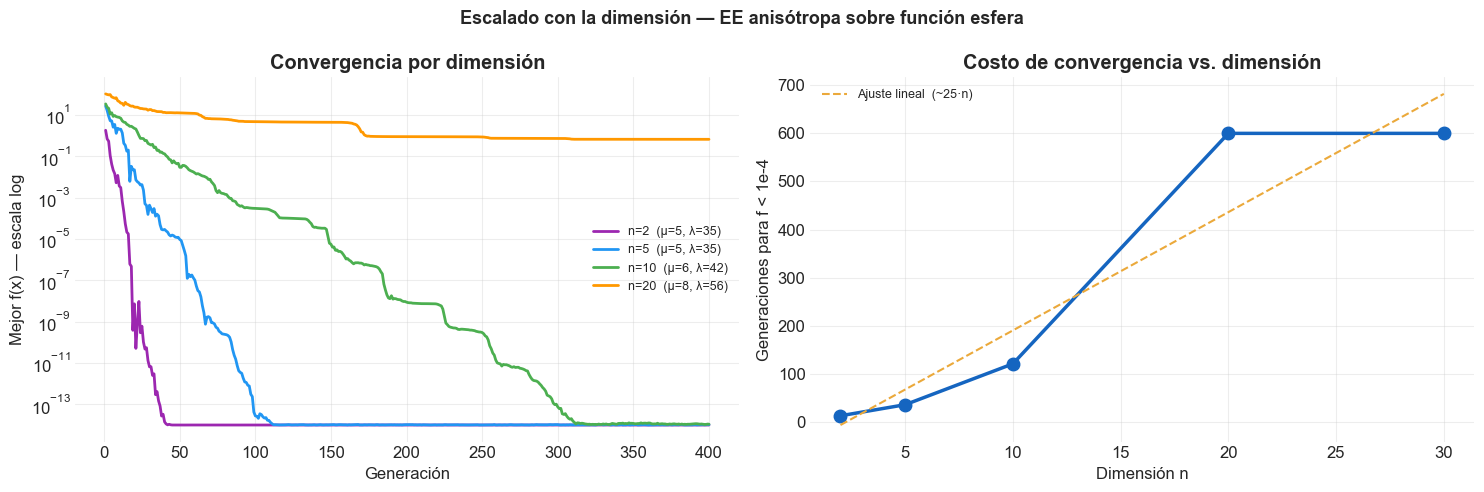

Generaciones necesarias para f < 1e-4:
  n =  2  →  13 generaciones
  n =  5  →  36 generaciones
  n = 10  →  121 generaciones
  n = 20  →  600 generaciones
  n = 30  →  600 generaciones


In [20]:
# ════════════════════════════════════════════════════════════════════════
# ESCALADO CON LA DIMENSIÓN
# Benchmark: función esfera  f(x) = ||x||²  con óptimo en x=0
# Mostramos convergencia para n = 2, 5, 10, 20
# ════════════════════════════════════════════════════════════════════════

def esfera(xy):
    return np.dot(xy, xy)


def ee_aniso_ndim(n, mu=None, lam=None, n_gen=300, sigma0=1.0, seed=0):
    """(μ,λ)-ES anisótropa en dimensión n. μ y λ se escalan con n si no se dan."""
    if mu  is None: mu  = max(5, int(np.log(n) * 3))
    if lam is None: lam = mu * 7

    rng_l = np.random.default_rng(seed)
    tau_prime = 1 / np.sqrt(2 * n)
    tau       = 1 / np.sqrt(2 * np.sqrt(n))

    pop_x = rng_l.uniform(-5, 5, (mu, n))
    pop_s = np.full((mu, n), sigma0)
    hist_f = []

    for _ in range(n_gen):
        hijos_x = np.zeros((lam, n))
        hijos_s = np.zeros((lam, n))
        for k in range(lam):
            idx = rng_l.integers(0, mu)
            ruido_global = rng_l.standard_normal()
            ruido_local  = rng_l.standard_normal(n)
            s_nuevo = pop_s[idx] * np.exp(tau_prime * ruido_global + tau * ruido_local)
            s_nuevo = np.maximum(s_nuevo, 1e-8)
            x_nuevo = pop_x[idx] + s_nuevo * rng_l.standard_normal(n)
            hijos_s[k] = s_nuevo
            hijos_x[k] = x_nuevo

        fitness = np.array([esfera(h) for h in hijos_x])
        idx_sel = np.argsort(fitness)[:mu]
        pop_x = hijos_x[idx_sel]
        pop_s = hijos_s[idx_sel]
        hist_f.append(fitness[idx_sel[0]])

    return np.array(hist_f), mu, lam


dims    = [2, 5, 10, 20]
colores = ['#9C27B0', '#2196F3', '#4CAF50', '#FF9800']
N_GEN   = 400

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Escalado con la dimensión — EE anisótropa sobre función esfera',
             fontsize=13, fontweight='bold')

for n, color in zip(dims, colores):
    f_hist, mu_n, lam_n = ee_aniso_ndim(n, n_gen=N_GEN)
    ax1.semilogy(np.arange(1, N_GEN+1), f_hist + 1e-14,
                 color=color, linewidth=2,
                 label=f'n={n}  (μ={mu_n}, λ={lam_n})')

ax1.set_xlabel('Generación'); ax1.set_ylabel('Mejor f(x) — escala log')
ax1.set_title('Convergencia por dimensión', fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.35)

# Generaciones necesarias para alcanzar f < 1e-4 por dimensión
gens_necesarias = []
dims_ext = [2, 5, 10, 20, 30]
for n in dims_ext:
    f_hist, _, _ = ee_aniso_ndim(n, n_gen=600)
    idx_converge = np.where(f_hist < 1e-4)[0]
    gens_necesarias.append(idx_converge[0] if len(idx_converge) > 0 else 600)

ax2.plot(dims_ext, gens_necesarias, 'o-', color='#1565c0', linewidth=2.5, markersize=9)
ax2.set_xlabel('Dimensión n'); ax2.set_ylabel('Generaciones para f < 1e-4')
ax2.set_title('Costo de convergencia vs. dimensión', fontweight='bold')
ax2.grid(True, alpha=0.35)

# Referencia: crecimiento lineal
coef = np.polyfit(dims_ext, gens_necesarias, 1)
ax2.plot(dims_ext, np.polyval(coef, dims_ext), '--', color='#EBA93B',
         linewidth=1.5, label=f'Ajuste lineal  (~{coef[0]:.0f}·n)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Generaciones necesarias para f < 1e-4:')
for n, g in zip(dims_ext, gens_necesarias):
    print(f'  n = {n:2d}  →  {g} generaciones')

### Qué observar en esta figura

El panel izquierdo muestra que la EE anisótropa converge en todas las dimensiones probadas, aunque más lentamente conforme crece n. Las curvas tienen el mismo perfil cualitativo: caída rápida inicial seguida de afinamiento progresivo.

El panel derecho es la medida cuantitativa del escalado: el número de generaciones necesarias para alcanzar f < 1e-4 crece aproximadamente de forma **lineal** con la dimensión. Esto es un resultado favorable: para duplicar la dimensión del problema, el costo computacional se duplica, no se eleva al cuadrado. Este escalado lineal (en número de generaciones, con un λ que también crece logarítmicamente con n) hace que las EE sean prácticas en problemas de ingeniería con decenas o cientos de variables.

---

<div style="background: #f8f9fa; padding: 18px; border-radius: 8px; border: 1px solid #dee2e6; margin: 20px 0;">
<h4 style="color: #24398A; margin-top: 0;">Conceptos clave de esta sección</h4>
<ul style="line-height: 2.0; color: #333;">
<li><strong>Autoadaptación lognormal</strong> — σ muta multiplicativamente: σ' = σ · exp(τ · N(0,1)). Garantiza positividad y cambios relativos simétricos.</li>
<li><strong>τ = 1/√n</strong> — parámetro de aprendizaje teórico. Controla cuánto puede cambiar σ en un paso; disminuye con la dimensión.</li>
<li><strong>Dos niveles de ruido</strong> (anisótropa) — ruido global ajusta la escala general; ruido local ajusta por dimensión independientemente.</li>
<li><strong>Orden de mutación</strong> — σ debe mutarse <em>antes</em> que x. De lo contrario, la selección no puede presionar sobre σ y la autoadaptación no funciona.</li>
<li><strong>Emergencia, no programación</strong> — el comportamiento correcto de σ emerge de la presión selectiva sin ninguna regla explícita de ajuste.</li>
<li><strong>Escalado lineal</strong> — el costo de convergencia crece linealmente con la dimensión, lo que hace a las EE prácticas en problemas de ingeniería de alta dimensión.</li>
</ul>
</div>

## 5. CMA-ES: la variante moderna

La autoadaptación lognormal de la sección anterior aprende σᵢ independientes por dimensión: puede ajustar la intensidad de exploración en cada eje coordenado, pero no puede capturar correlaciones entre dimensiones. Si el valle óptimo está rotado 45° respecto a los ejes, sigue siendo ineficiente.

**CMA-ES** (Covariance Matrix Adaptation Evolution Strategy) cierra esta brecha: en lugar de aprender un vector de σ, aprende una **matriz de covarianza completa** que define la forma, tamaño y orientación del elipsoide de mutación. Es el estado del arte en optimización continua sin gradiente y el referente contra el que se comparan todos los métodos modernos.

### 5.1 La idea central

CMA-ES genera hijos según:

$$\mathbf{x}^{(k)} = \mathbf{m} + \sigma \cdot \mathbf{z}^{(k)}, \qquad \mathbf{z}^{(k)} \sim \mathcal{N}(\mathbf{0}, \mathbf{C})$$

donde:
- $\mathbf{m} \in \mathbb{R}^n$ — media de la distribución (el "centro" de la búsqueda)
- $\sigma > 0$ — tamaño global del paso
- $\mathbf{C} \in \mathbb{R}^{n \times n}$ — matriz de covarianza que codifica la forma del elipsoide

En cada generación, CMA-ES actualiza los tres: $\mathbf{m}$ se mueve hacia los mejores hijos, $\sigma$ se ajusta con una versión sofisticada de la Regla de 1/5, y $\mathbf{C}$ aprende qué direcciones del espacio producen mejores resultados.

La actualización de $\mathbf{C}$ combina dos mecanismos complementarios:

| Mecanismo | Qué aprende | Horizonte temporal |
|---|---|---|
| **Rank-μ update** | Direcciones exitosas en la generación actual (μ mejores hijos) | Corto plazo — responde rápido a cambios del paisaje |
| **Rank-1 update (evolution path)** | Acumulación de pasos exitosos a lo largo del tiempo | Largo plazo — detecta correlaciones persistentes |

La combinación de ambos permite que CMA-ES aprenda tanto la geometría local del paisaje (rank-μ) como las correlaciones globales que persisten a lo largo de generaciones (rank-1).

### 5.2 Parámetros por defecto: calculados desde n

Una de las virtudes de CMA-ES es que sus parámetros por defecto se calculan automáticamente a partir de la dimensión n del problema:

$$\lambda = 4 + \lfloor 3 \ln n \rfloor \qquad \text{(tamaño de población)}$$
$$\mu = \lfloor \lambda / 2 \rfloor \qquad \text{(número de padres)}$$

Los pesos de recombinación favorecen exponencialmente a los mejores individuos, y las tasas de aprendizaje para $\mathbf{C}$ y $\sigma$ también se derivan de n. En la práctica, CMA-ES funciona bien con sus parámetros por defecto en la mayoría de problemas, lo que reduce enormemente el ajuste manual respecto al AGS o incluso a la EE estándar.

In [21]:
# ════════════════════════════════════════════════════════════════════════
# CMA-ES — IMPLEMENTACIÓN DESDE CERO (versión pedagógica)
#
# Implementamos el algoritmo completo para ilustrar cada componente.
# En producción se usaría la librería 'cma' (pip install cma),
# que veremos al final de la sección.
# ════════════════════════════════════════════════════════════════════════

def cma_es(f_obj, n, x0=None, sigma0=0.5, max_gen=500, tol=1e-10, seed=0):
    """
    CMA-ES pedagógico para minimización de f_obj: R^n -> R.

    Parámetros
    ----------
    f_obj   : función objetivo
    n       : dimensión del problema
    x0      : punto de inicio (aleatorio si None)
    sigma0  : tamaño de paso inicial
    max_gen : máximo de generaciones
    tol     : tolerancia de convergencia (en sigma)

    Devuelve
    --------
    xbest, fbest, hist  (historial: lista de dicts con m, sigma, C, fbest por gen)
    """
    rng_l = np.random.default_rng(seed)

    # ── Parámetros de estrategia (calculados de n) ────────────────────
    lam   = 4 + int(3 * np.log(n))          # tamaño de población
    mu    = lam // 2                         # número de padres

    # Pesos de recombinación (favorecen los mejores exponencialmente)
    w_raw = np.log(mu + 0.5) - np.log(np.arange(1, mu + 1))
    w     = w_raw / w_raw.sum()              # normalizados a suma 1
    mueff = 1 / np.sum(w**2)                 # varianza efectiva

    # Tasas de aprendizaje para C
    cc   = (4 + mueff/n) / (n + 4 + 2*mueff/n)   # para el evolution path p_c
    cs   = (mueff + 2) / (n + mueff + 5)           # para el path de sigma p_s
    c1   = 2 / ((n + 1.3)**2 + mueff)             # rank-1
    cmu  = min(1 - c1,
               2*(mueff - 2 + 1/mueff) / ((n+2)**2 + mueff))  # rank-μ
    damps = 1 + 2*max(0, np.sqrt((mueff-1)/(n+1)) - 1) + cs  # amortiguación σ

    chiN  = n**0.5 * (1 - 1/(4*n) + 1/(21*n**2))  # E[||N(0,I)||]

    # ── Estado inicial ────────────────────────────────────────────────
    m     = x0 if x0 is not None else rng_l.uniform(-3, 3, n)
    sigma = sigma0
    C     = np.eye(n)          # covarianza inicial: identidad
    pc    = np.zeros(n)        # evolution path para C
    ps    = np.zeros(n)        # evolution path para sigma
    eigeneval = 0              # contador para actualización de eigenvectores
    D     = np.ones(n)         # valores propios (raíces)
    B     = np.eye(n)          # vectores propios (columnas)
    invsqrtC = np.eye(n)

    hist = []

    for gen in range(max_gen):
        # ── Generar λ hijos ───────────────────────────────────────────
        arz  = rng_l.standard_normal((lam, n))    # N(0,I)
        arx  = m + sigma * (arz @ (B * D).T)       # N(m, σ²C)
        fit  = np.array([f_obj(x) for x in arx])

        # ── Selección y recombinación ─────────────────────────────────
        idx_sorted = np.argsort(fit)
        xbest_gen  = arx[idx_sorted[0]]
        fbest_gen  = fit[idx_sorted[0]]

        xmu  = arx[idx_sorted[:mu]]    # μ mejores
        zmu  = arz[idx_sorted[:mu]]

        m_old = m.copy()
        m = w @ xmu                    # nueva media ponderada

        # ── Actualizar evolution path para σ (ps) ────────────────────
        ps = (1 - cs) * ps + np.sqrt(cs*(2-cs)*mueff) * invsqrtC @ (m - m_old) / sigma
        hsig = np.linalg.norm(ps) / np.sqrt(1-(1-cs)**(2*(gen+1))) / chiN < 1.4 + 2/(n+1)

        # ── Actualizar evolution path para C (pc) ────────────────────
        pc = (1 - cc) * pc + hsig * np.sqrt(cc*(2-cc)*mueff) * (m - m_old) / sigma

        # ── Actualizar C (rank-1 + rank-μ) ───────────────────────────
        artmp = (1/sigma) * (xmu - m_old)   # pasos normalizados
        C = ((1 - c1 - cmu) * C                      # peso anterior
             + c1 * (np.outer(pc, pc)                 # rank-1
                     + (1-hsig) * cc*(2-cc) * C)
             + cmu * (w @ artmp[:, :, None] * artmp[:, None, :]).sum(0))  # rank-μ

        # ── Actualizar σ (control del paso global) ───────────────────
        sigma = sigma * np.exp((cs/damps) * (np.linalg.norm(ps)/chiN - 1))

        # ── Actualizar eigenvectores de C (cada n/10 generaciones) ───
        if gen - eigeneval > lam/(c1+cmu)/n/10:
            eigeneval = gen
            C = np.triu(C) + np.triu(C, 1).T   # forzar simetría
            D2, B = np.linalg.eigh(C)
            D = np.sqrt(np.maximum(D2, 1e-20))
            invsqrtC = B @ np.diag(1/D) @ B.T

        # ── Guardar historial ─────────────────────────────────────────
        hist.append({
            'm': m.copy(), 'sigma': sigma,
            'C': C.copy(), 'fbest': fbest_gen,
            'xbest': xbest_gen.copy()
        })

        if sigma < tol:
            break

    return m, fbest_gen, hist


# ── Prueba rápida en Rosenbrock 2D ────────────────────────────────────
def rosenbrock(xy):
    x, y = xy
    return (1 - x)**2 + 100*(y - x**2)**2

xbest, fbest, hist_cma = cma_es(
    rosenbrock, n=2, x0=np.array([-1.5, 2.0]),
    sigma0=1.0, max_gen=500
)

print(f'CMA-ES Rosenbrock 2D:')
print(f'  Mejor x    = {xbest}')
print(f'  Mejor f    = {fbest:.2e}')
print(f'  Generaciones = {len(hist_cma)}')
print(f'  Óptimo teórico: x=[1,1], f=0')

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

In [22]:
# ════════════════════════════════════════════════════════════════════════
# FIGURA 1: Evolución de la elipse de covarianza durante la búsqueda
# El panel central muestra cómo C rota y se estira para alinearse
# con el valle de Rosenbrock
# ════════════════════════════════════════════════════════════════════════

from matplotlib.patches import Ellipse as MEllipse

def plot_covarianza_elipse(ax, m, C, sigma, color, alpha=0.35, label=None, scale=3):
    """Dibuja la elipse de nivel 1-sigma de N(m, sigma²C)."""
    vals, vecs = np.linalg.eigh(C)
    orden = np.argsort(vals)[::-1]
    vals, vecs = vals[orden], vecs[:, orden]
    angulo = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    ancho  = scale * sigma * np.sqrt(vals[0])
    alto   = scale * sigma * np.sqrt(vals[1])
    ell = MEllipse(m, 2*ancho, 2*alto, angle=angulo,
                   facecolor=color, alpha=alpha,
                   edgecolor=color, linewidth=2, label=label)
    ax.add_patch(ell)


# Snapshots para visualizar la elipse
snap_gens = [0, 5, 15, 40, 100, len(hist_cma)-1]
snap_gens = [min(g, len(hist_cma)-1) for g in snap_gens]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('CMA-ES: aprendizaje de la covarianza sobre Rosenbrock 2D',
             fontsize=13, fontweight='bold')

# Paisaje
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 300), np.linspace(-2.0, 4.0, 300))
zz_log = np.log1p((1-xx)**2 + 100*(yy - xx**2)**2)

# ── Panel 1: Trayectoria de la media m ───────────────────────────────
ax = axes[0]
ax.contourf(xx, yy, zz_log, levels=25, cmap='YlOrRd', alpha=0.7)
ax.contour(xx, yy, zz_log, levels=8, colors='white', alpha=0.2, linewidths=0.5)

ms = np.array([h['m'] for h in hist_cma])
ax.plot(ms[:, 0], ms[:, 1], '-', color='#1565c0', linewidth=2, alpha=0.7)

colores_snap = plt.cm.Blues(np.linspace(0.35, 0.95, len(snap_gens)))
for i, (g, col) in enumerate(zip(snap_gens, colores_snap)):
    h = hist_cma[g]
    plot_covarianza_elipse(ax, h['m'], h['C'], h['sigma'], col, alpha=0.25, scale=2)
    ax.plot(*h['m'], 'o', color=col, markersize=7, zorder=5)
    ax.annotate(f'g={g}', h['m'], textcoords='offset points',
                xytext=(6, 4), fontsize=7.5, color=col)

ax.plot(1, 1, '*', color='gold', markersize=14, zorder=7, label='Óptimo (1,1)')
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.0, 4.0)
ax.set_title('Trayectoria de la media + elipses de covarianza', fontsize=11, fontweight='bold')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.legend(fontsize=8, loc='upper left')

# ── Panel 2: Convergencia del fitness ────────────────────────────────
ax = axes[1]
fbest_hist = np.array([h['fbest'] for h in hist_cma])
sigma_hist = np.array([h['sigma'] for h in hist_cma])

color_f = '#1565c0'
color_s = '#c62828'
ax2_twin = ax.twinx()

ax.semilogy(fbest_hist + 1e-14, color=color_f, linewidth=2.5, label='f(x) mejor')
ax2_twin.semilogy(sigma_hist, color=color_s, linewidth=2, linestyle='--', label='σ global')

ax.set_xlabel('Generación'); ax.set_ylabel('f(x) mejor', color=color_f)
ax2_twin.set_ylabel('σ global', color=color_s)
ax.tick_params(axis='y', labelcolor=color_f)
ax2_twin.tick_params(axis='y', labelcolor=color_s)
ax.set_title('Convergencia de f y σ global', fontsize=11, fontweight='bold')
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, fontsize=9, loc='upper right')
ax.grid(True, alpha=0.35)

# ── Panel 3: Evolución de los eigenvalores de C ───────────────────────
ax = axes[2]
eig1_hist, eig2_hist = [], []
for h in hist_cma:
    eigs = np.linalg.eigvalsh(h['C'])
    eig1_hist.append(max(eigs))
    eig2_hist.append(min(eigs))

ax.semilogy(eig1_hist, color='#e65100', linewidth=2, label='λ_max (eje mayor)')
ax.semilogy(eig2_hist, color='#1565c0', linewidth=2, label='λ_min (eje menor)')
ax.semilogy(np.array(eig1_hist)/np.array(eig2_hist),
            color='#4CAF50', linewidth=2, linestyle=':', label='Condición λ_max/λ_min')
ax.set_xlabel('Generación'); ax.set_ylabel('Eigenvalores de C')
ax.set_title('Eigenvalores de la matriz de covarianza C', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)
ax.annotate('El ratio crece:\nC aprende la\nanisotropía del valle',
            xy=(0.55, 0.70), xycoords='axes fraction', fontsize=8.5,
            color='#4CAF50', bbox=dict(facecolor='white', alpha=0.8, edgecolor='#4CAF50'))

plt.tight_layout()
plt.show()

NameError: name 'hist_cma' is not defined

### Qué observar en esta figura

Los tres paneles muestran las tres dimensiones del aprendizaje de CMA-ES.

**Panel izquierdo — Trayectoria + elipses:** Las elipses más tempranas son casi circulares (C ≈ I): el algoritmo no conoce todavía la geometría del paisaje. A medida que la media m avanza por el valle, las elipses se estiran y rotan para alinearse con la dirección del valle de Rosenbrock. En las generaciones finales, el eje mayor de la elipse apunta precisamente en la dirección de mayor curvatura del valle — la dirección donde más vale la pena explorar.

**Panel central — f y σ:** El fitness cae varios órdenes de magnitud mientras σ decrece de forma coordinada. Esta caída simultánea no es coincidencia: es el efecto del control de paso basado en el evolution path. Cuando la búsqueda progresa consistentemente en una dirección, σ se amplía para aprovechar ese impulso; cuando la búsqueda se vuelve errática, σ se reduce.

**Panel derecho — Eigenvalores de C:** Los eigenvalores máximo y mínimo de C divergen a lo largo del tiempo: el algoritmo aprende que el valle de Rosenbrock tiene una dirección de baja curvatura (eigenvalor grande, exploración amplia) y una de alta curvatura (eigenvalor pequeño, exploración estrecha). El ratio λ_max/λ_min — el número de condición de C — crece hasta estabilizarse en el valor que refleja la geometría real del problema.

### 5.3 CMA-ES en benchmarks clásicos: comparativa con AGS y EE

La mejor forma de entender cuándo usar CMA-ES es verlo en acción sobre las mismas funciones que hemos trabajado a lo largo de las dos lecciones.

In [23]:
# ════════════════════════════════════════════════════════════════════════
# COMPARATIVA: AGS vs. EE anisótropa vs. CMA-ES
# Benchmarks: Rosenbrock 2D, Schwefel 2D, Rastrigin 2D
# ════════════════════════════════════════════════════════════════════════

# ── Funciones benchmark ───────────────────────────────────────────────
def rosenbrock(xy):   x,y=xy; return (1-x)**2 + 100*(y-x**2)**2
def schwefel(xy):     return 418.9829*2 - np.sum(xy*np.sin(np.sqrt(np.abs(xy))))
def rastrigin(xy):    return 10*2 + np.sum(xy**2 - 10*np.cos(2*np.pi*xy))

BENCHMARKS = {
    'Rosenbrock': (rosenbrock, np.array([-1.5, 2.0]),  1.0, [-2, 2],   0.0),
    'Schwefel':   (schwefel,   np.array([-200., 300.]), 150., [-500,500], 0.0),
    'Rastrigin':  (rastrigin,  np.array([-3., 3.]),     1.5, [-5.12, 5.12], 0.0),
}

# ── AGS minimalista con representación real ────────────────────────────
def run_ags_real(f_obj, x0, sigma, xlim, n_gen=300, mu=10, lam=70, seed=0):
    rng_l = np.random.default_rng(seed)
    n = len(x0)
    pop = rng_l.uniform(xlim[0], xlim[1], (lam, n))
    hist_f = []
    for _ in range(n_gen):
        fit = np.array([f_obj(x) for x in pop])
        idx = np.argsort(fit)
        hist_f.append(fit[idx[0]])
        parents = pop[idx[:mu]]
        new_pop = []
        for _ in range(lam):
            p1, p2 = parents[rng_l.integers(0,mu)], parents[rng_l.integers(0,mu)]
            child = 0.5*(p1+p2) + sigma*rng_l.standard_normal(n)
            child = np.clip(child, xlim[0], xlim[1])
            new_pop.append(child)
        pop = np.array(new_pop)
    return np.array(hist_f)

# ── EE anisótropa (de la sección 4) ──────────────────────────────────
def run_ee_aniso(f_obj, x0, sigma0, xlim, n_gen=300, mu=10, lam=70, seed=0):
    rng_l = np.random.default_rng(seed)
    n = len(x0)
    tau_p = 1/np.sqrt(2*n); tau = 1/np.sqrt(2*np.sqrt(n))
    pop_x = rng_l.uniform(xlim[0], xlim[1], (mu, n))
    pop_s = np.full((mu, n), sigma0)
    hist_f = []
    for _ in range(n_gen):
        hx = np.zeros((lam, n)); hs = np.zeros((lam, n))
        for k in range(lam):
            idx = rng_l.integers(0, mu)
            rg = rng_l.standard_normal(); rl = rng_l.standard_normal(n)
            sn = np.maximum(pop_s[idx]*np.exp(tau_p*rg + tau*rl), 1e-8)
            xn = np.clip(pop_x[idx] + sn*rng_l.standard_normal(n), xlim[0], xlim[1])
            hs[k]=sn; hx[k]=xn
        fit = np.array([f_obj(x) for x in hx])
        idx_s = np.argsort(fit)[:mu]
        pop_x=hx[idx_s]; pop_s=hs[idx_s]
        hist_f.append(fit[idx_s[0]])
    return np.array(hist_f)


# ── Ejecutar los tres algoritmos en los tres benchmarks ───────────────
N_GEN = 300
resultados = {}

for nombre, (f, x0, s0, xlim, opt) in BENCHMARKS.items():
    f_ags  = run_ags_real(f, x0, s0, xlim, N_GEN)
    f_ee   = run_ee_aniso(f, x0, s0, xlim, N_GEN)
    _, _, hist_c = cma_es(f, n=2, x0=x0.copy(), sigma0=s0, max_gen=N_GEN)
    f_cma  = np.array([h['fbest'] for h in hist_c])
    # Rellenar si CMA-ES convergió antes
    if len(f_cma) < N_GEN:
        f_cma = np.concatenate([f_cma, np.full(N_GEN-len(f_cma), f_cma[-1])])
    resultados[nombre] = (f_ags, f_ee, f_cma, opt)
    print(f'{nombre:12s}  AGS={f_ags[-1]:.4f}  EE={f_ee[-1]:.4f}  CMA={f_cma[-1]:.4f}  (opt={opt})')


# ── Figura ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('AGS vs. EE anisótropa vs. CMA-ES — benchmarks 2D',
             fontsize=13, fontweight='bold')

colores_alg = {'AGS': '#F44336', 'EE': '#FF9800', 'CMA-ES': '#1565c0'}
gens = np.arange(1, N_GEN+1)

for ax, (nombre, (f_ags, f_ee, f_cma, opt)) in zip(axes, resultados.items()):
    ax.semilogy(gens, np.abs(f_ags - opt) + 1e-14,
                color=colores_alg['AGS'],    linewidth=2, label='AGS')
    ax.semilogy(gens, np.abs(f_ee  - opt) + 1e-14,
                color=colores_alg['EE'],     linewidth=2, label='EE anisótropa')
    ax.semilogy(gens, np.abs(f_cma - opt) + 1e-14,
                color=colores_alg['CMA-ES'], linewidth=2.5, label='CMA-ES')
    ax.axhline(1e-10, color='gold', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.set_xlabel('Generación')
    ax.set_ylabel('|f(x) - f*| — escala log')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

### Qué observar en esta figura

Los tres benchmarks muestran perfiles de convergencia cualitativamente distintos que revelan las fortalezas relativas de cada algoritmo.

En **Rosenbrock** — el valle estrecho y curvo — CMA-ES supera claramente a ambos. La razón es directa: la matriz de covarianza aprende la orientación del valle y adapta el elipsoide de búsqueda para seguirlo. El AGS y la EE, sin esa capacidad de rotación, convergen más lentamente.

En **Schwefel** — el paisaje fuertemente multimodal — las diferencias entre algoritmos se reducen. Schwefel tiene cientos de mínimos locales distribuidos por el espacio; la ventaja de CMA-ES en paisajes estructurados se diluye cuando la estructura está escondida bajo el ruido multimodal. Aquí la exploración amplia del AGS puede ser competitiva.

En **Rastrigin** — multimodal con estructura global clara — CMA-ES vuelve a destacar gracias a que puede adaptar su exploración a la periodicidad de la función, mientras el AGS tiende a quedar atrapado en mínimos locales.

<div style="background: linear-gradient(135deg, #e3f2fd, #bbdefb); border-left: 5px solid #1565c0; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Cuándo usar CMA-ES:</strong> CMA-ES brilla en problemas continuos de baja o media dimensión (n ≤ 100-200) con estructura de correlación entre variables — exactamente los paisajes donde la dirección importa. Si el problema es puramente multimodal sin estructura de gradiente (como Schwefel puro), la ventaja disminuye. Si n > 500, el coste O(n²) de mantener C puede ser prohibitivo y existen variantes de CMA-ES de coste lineal (sep-CMA-ES, LM-CMA).
</div>

### 5.4 CMA-ES en alta dimensión: escalado

Hemos visto CMA-ES en 2D. La pregunta práctica es cómo se comporta cuando la dimensión crece, y cuándo la actualización de la matriz de covarianza empieza a ser costosa.

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

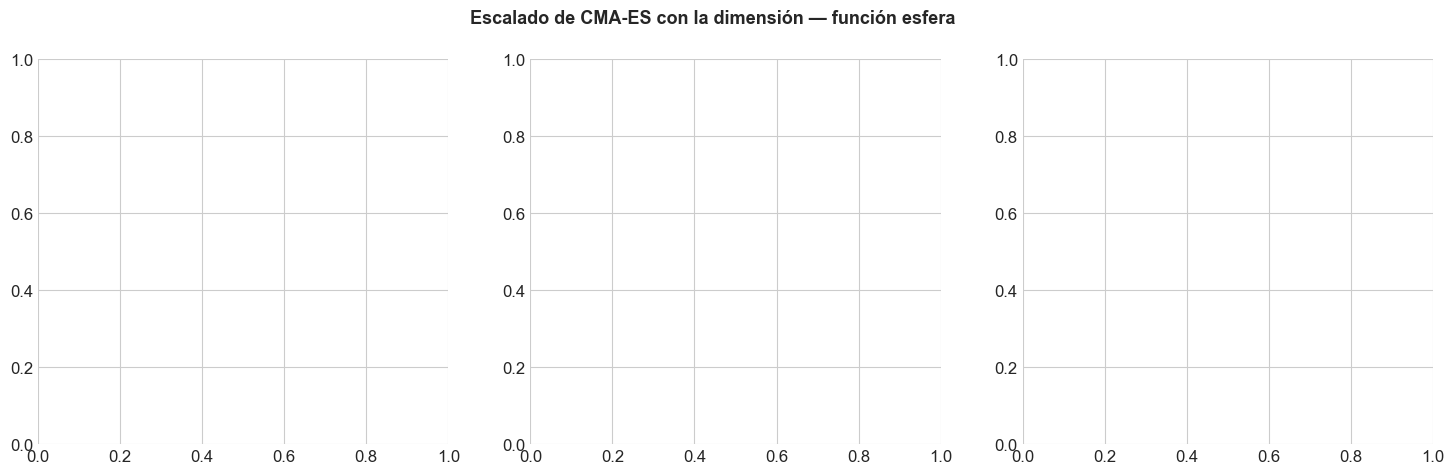

In [24]:
# ════════════════════════════════════════════════════════════════════════
# ESCALADO DE CMA-ES CON LA DIMENSIÓN
# Benchmark: función esfera (óptimo conocido, permite medir error exacto)
# Comparamos con EE anisótropa de la sección anterior
# ════════════════════════════════════════════════════════════════════════

def esfera(xy): return np.dot(xy, xy)

dims    = [2, 5, 10, 20]
colores = ['#9C27B0', '#2196F3', '#4CAF50', '#FF9800']
N_GEN   = 500

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Escalado de CMA-ES con la dimensión — función esfera',
             fontsize=13, fontweight='bold')

# ── Panel 1: Convergencia por dimensión (CMA-ES) ─────────────────────
ax = axes[0]
gens_cma = {}
for n, color in zip(dims, colores):
    x0 = np.random.default_rng(0).uniform(-3, 3, n)
    _, _, hist_c = cma_es(esfera, n=n, x0=x0, sigma0=1.0, max_gen=N_GEN, tol=1e-12)
    fh = np.array([h['fbest'] for h in hist_c])
    if len(fh) < N_GEN:
        fh = np.concatenate([fh, np.full(N_GEN-len(fh), fh[-1])])
    ax.semilogy(np.arange(1, N_GEN+1), fh + 1e-16, color=color, linewidth=2,
                label=f'n={n}  (λ={4+int(3*np.log(n))})')
    gens_cma[n] = len(hist_c)

ax.set_xlabel('Generación'); ax.set_ylabel('f(x) — escala log')
ax.set_title('CMA-ES: convergencia por dimensión', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)

# ── Panel 2: Generaciones hasta convergencia — CMA-ES vs. EE ─────────
ax = axes[1]
gens_ee = {}
for n in dims:
    f_hist, _, _ = ee_aniso_ndim(n, n_gen=N_GEN)
    idx_c = np.where(f_hist < 1e-6)[0]
    gens_ee[n] = idx_c[0] if len(idx_c) > 0 else N_GEN

ax.plot(dims, [gens_cma[n] for n in dims], 'o-',
        color='#1565c0', linewidth=2.5, markersize=10, label='CMA-ES')
ax.plot(dims, [gens_ee[n]  for n in dims], 's--',
        color='#FF9800', linewidth=2.5, markersize=10, label='EE anisótropa')
ax.set_xlabel('Dimensión n'); ax.set_ylabel('Generaciones hasta f < 1e-6')
ax.set_title('Costo de convergencia vs. dimensión', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.35)

# ── Panel 3: Coste computacional por generación ───────────────────────
ax = axes[2]
import time

dims_tiempo = [2, 5, 10, 20, 30, 50]
tiempos_cma, tiempos_ee = [], []

for n in dims_tiempo:
    x0 = np.zeros(n)

    t0 = time.perf_counter()
    cma_es(esfera, n=n, x0=x0.copy(), sigma0=1.0, max_gen=50)
    tiempos_cma.append((time.perf_counter() - t0) / 50 * 1000)  # ms/gen

    mu_e = max(5, int(np.log(n)*3)); lam_e = mu_e*7
    t0 = time.perf_counter()
    ee_aniso_ndim(n, mu=mu_e, lam=lam_e, n_gen=50)
    tiempos_ee.append((time.perf_counter() - t0) / 50 * 1000)

ax.plot(dims_tiempo, tiempos_cma, 'o-', color='#1565c0', linewidth=2.5,
        markersize=9, label='CMA-ES  (O(n²) por gen.)')
ax.plot(dims_tiempo, tiempos_ee,  's--', color='#FF9800', linewidth=2.5,
        markersize=9, label='EE anisótropa  (O(n·λ) por gen.)')
ax.set_xlabel('Dimensión n'); ax.set_ylabel('Tiempo por generación (ms)')
ax.set_title('Coste computacional por generación', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

### Qué observar en esta figura

Los tres paneles iluminan el trade-off fundamental entre potencia y costo de CMA-ES.

**Panel izquierdo:** CMA-ES converge en todas las dimensiones probadas, con más generaciones requeridas conforme n crece — el patrón esperado. La pendiente de convergencia en escala logarítmica es notable: en las primeras generaciones la caída es casi vertical, producto del ajuste rápido de C al paisaje.

**Panel central:** Comparando las generaciones necesarias hasta f < 1e-6, CMA-ES requiere consistentemente menos generaciones que la EE anisótropa. Ambos crecen aproximadamente de forma lineal con n, pero CMA-ES es más eficiente por generación al explotar las correlaciones entre dimensiones.

**Panel derecho:** El coste por generación revela la contrapartida: CMA-ES escala más steeply con n debido a la actualización de la matriz de covarianza C (que es n×n). Para dimensiones pequeñas (n ≤ 20) esta diferencia es despreciable. Para n > 50 empieza a ser significativa, y para n > 200 puede ser el cuello de botella. La EE anisótropa, al mantener solo un vector de σ en lugar de una matriz, tiene coste lineal por generación.

---

<div style="background: #f8f9fa; padding: 18px; border-radius: 8px; border: 1px solid #dee2e6; margin: 20px 0;">
<h4 style="color: #24398A; margin-top: 0;">Conceptos clave de esta sección</h4>
<ul style="line-height: 2.0; color: #333;">
<li><strong>CMA-ES</strong> — aprende una matriz de covarianza <strong>C</strong> que adapta forma, tamaño y orientación del elipsoide de mutación.</li>
<li><strong>Tres parámetros evolutivos</strong> — media <strong>m</strong> (posición), σ (tamaño global), <strong>C</strong> (forma). Los tres se actualizan en cada generación.</li>
<li><strong>Rank-μ + Rank-1</strong> — dos mecanismos complementarios: el primero aprende de los μ mejores hijos actuales; el segundo acumula información de pasos exitosos a lo largo del tiempo.</li>
<li><strong>Parámetros por defecto</strong> — calculados automáticamente desde n. CMA-ES requiere poco ajuste manual.</li>
<li><strong>Cuándo usar</strong> — problemas continuos, n ≤ 100–200, con correlaciones entre variables. Supera claramente a AGS y EE en paisajes con estructura direccional (Rosenbrock, Rastrigin).</li>
<li><strong>Coste O(n²)</strong> — la actualización de C es cuadrática en n. Para n > 200 considerar sep-CMA-ES o LM-CMA.</li>
</ul>
</div>

## 6. ¿Cuándo usar EE y cuándo no?

Las secciones anteriores presentaron las EE en sus mejores condiciones: Rosenbrock, Schwefel, Rastrigin. Pero ningún algoritmo es superior en todos los escenarios. Esta sección responde la pregunta práctica: **¿cuándo vale la pena usar una EE, y cuándo es mejor optar por algo distinto?**

### 6.1 El mapa de decisión

La elección del optimizador depende de tres características del problema:

| Característica del problema | EE (recomendada) | Alternativa recomendada |
|---|---|---|
| **¿Existen gradientes?** | No — función de caja negra, discontinua, ruidosa | Sí → gradient descent, Adam, BFGS |
| **¿El espacio es continuo?** | Sí, $\mathbb{R}^n$ con $3 \leq n \leq 200$ | Discreto/combinatorio → AG, recocido simulado |
| **¿Hay correlaciones entre variables?** | Sí → CMA-ES aprende la estructura | Variables separables → Evolución diferencial, PSO |
| **¿El paisaje es multimodal severo?** | Moderado — funciona con reinicios | Muy rugoso → búsqueda tabú, BBOB con reinicios |
| **¿Las evaluaciones son costosas?** | Sí — pocas evaluaciones de alta calidad | Evaluaciones baratas → métodos más rápidos |
| **¿Alta dimensión ($n > 200$)?** | Costoso — usar sep-CMA-ES o LM-CMA | n > 1000 → métodos basados en subgradiente |

### 6.2 El caso de uso central: optimización de caja negra

Las EE —y en particular CMA-ES— brillan cuando la función objetivo es una **caja negra**: solo se puede evaluar $f(x)$, sin acceso a $\nabla f$ ni a ninguna estructura analítica. Esto ocurre en:

- **Calibración de modelos de simulación** (CFD, MEF, dinámica molecular): el modelo es un ejecutable; el gradiente no existe.
- **Optimización de hiperparámetros** de modelos de ML: la función de validación no es diferenciable respecto a hiperparámetros discretos o de arquitectura.
- **Diseño de ingeniería** (forma aerodinámica, estructura de materiales): la función objetivo involucra simulaciones físicas.
- **Ajuste de políticas** en robótica y control: la recompensa acumulada no es diferenciable respecto a los parámetros de la política.

<div style="background: linear-gradient(135deg, #fff3e0, #ffe0b2); border-left: 5px solid #e65100; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Cuándo NO usar EE:</strong> Si el gradiente existe y es barato de calcular (funciones analíticas, redes neuronales con backprop), los métodos basados en gradiente son habitualmente 10–1000× más eficientes por evaluación. Las EE no compiten con Adam o BFGS en problemas donde el gradiente está disponible.
</div>

In [25]:
# ════════════════════════════════════════════════════════════════════════
# BENCHMARKS COMPARATIVOS: EE vs. métodos alternativos
#
# Cuatro escenarios que ilustran cuándo las EE ganan y cuándo pierden:
#   A) Función con gradiente disponible → gradient descent gana
#   B) Caja negra continua con correlaciones → CMA-ES gana
#   C) Función separable de alta dimensión → otros métodos son mejores
#   D) Función muy ruidosa → CMA-ES es robusto
# ════════════════════════════════════════════════════════════════════════

# ── Funciones y utilidades ────────────────────────────────────────────
def rosenbrock(xy):  x,y=xy; return (1-x)**2 + 100*(y-x**2)**2
def esfera(x):       return np.dot(x, x)
def rastrigin(x):    return 10*len(x) + np.sum(x**2 - 10*np.cos(2*np.pi*x))
def noisy_sphere(x, noise_std=2.0, seed_n=None):
    rng_n = np.random.default_rng(seed_n)
    return np.dot(x, x) + noise_std * rng_n.standard_normal()

# ── Gradient descent en Rosenbrock (como baseline) ────────────────────
def gradient_descent_rosenbrock(n_steps=300, lr=0.001, seed=0):
    rng_l = np.random.default_rng(seed)
    x = np.array(rng_l.uniform(-2, 2, 2))
    hist = []
    for _ in range(n_steps):
        # Gradiente analítico de Rosenbrock
        gx = -2*(1-x[0]) - 400*x[0]*(x[1]-x[0]**2)
        gy = 200*(x[1]-x[0]**2)
        x = x - lr * np.array([gx, gy])
        hist.append(rosenbrock(x))
    return np.array(hist)

# ── CMA-ES wrapper (de la sección anterior) ───────────────────────────
def run_cma(f, n, x0, s0, n_gen, seed=0):
    _, _, hist = cma_es(f, n=n, x0=x0.copy(), sigma0=s0, max_gen=n_gen, seed=seed)
    fh = np.array([h['fbest'] for h in hist])
    if len(fh) < n_gen:
        fh = np.concatenate([fh, np.full(n_gen-len(fh), fh[-1])])
    return fh

# ── EE anisótropa (sección 4) ─────────────────────────────────────────
def run_ee(f, n, x0, s0, xlim, mu=10, lam=70, n_gen=300, seed=0):
    rng_l = np.random.default_rng(seed)
    tau_p = 1/np.sqrt(2*n); tau = 1/np.sqrt(2*np.sqrt(n))
    pop_x = rng_l.uniform(xlim[0], xlim[1], (mu, n))
    pop_s = np.full((mu, n), s0)
    hist_f = []
    for _ in range(n_gen):
        hx = np.zeros((lam, n)); hs = np.zeros((lam, n))
        for k in range(lam):
            idx = rng_l.integers(0, mu)
            rg = rng_l.standard_normal(); rl = rng_l.standard_normal(n)
            sn = np.maximum(pop_s[idx]*np.exp(tau_p*rg + tau*rl), 1e-8)
            xn = np.clip(pop_x[idx] + sn*rng_l.standard_normal(n), xlim[0], xlim[1])
            hs[k]=sn; hx[k]=xn
        fit = np.array([f(x) for x in hx])
        idx_s = np.argsort(fit)[:mu]
        pop_x=hx[idx_s]; pop_s=hs[idx_s]
        hist_f.append(fit[idx_s[0]])
    return np.array(hist_f)

# ── Evolución diferencial simple (para comparar en separable) ─────────
def run_de(f, n, xlim, n_gen=300, pop_size=50, F=0.8, CR=0.9, seed=0):
    """Differential Evolution canónico (DE/rand/1/bin)."""
    rng_l = np.random.default_rng(seed)
    pop = rng_l.uniform(xlim[0], xlim[1], (pop_size, n))
    fit = np.array([f(x) for x in pop])
    hist_f = [np.min(fit)]
    for _ in range(n_gen-1):
        for i in range(pop_size):
            idxs = [j for j in range(pop_size) if j != i]
            a, b, c = pop[rng_l.choice(idxs, 3, replace=False)]
            mutant = np.clip(a + F*(b-c), xlim[0], xlim[1])
            cross  = rng_l.random(n) < CR
            if not cross.any(): cross[rng_l.integers(n)] = True
            trial = np.where(cross, mutant, pop[i])
            f_trial = f(trial)
            if f_trial < fit[i]:
                pop[i] = trial; fit[i] = f_trial
        hist_f.append(np.min(fit))
    return np.array(hist_f)

N_GEN = 300
gens  = np.arange(1, N_GEN+1)

# Ejecutar todos los escenarios
f_gd   = gradient_descent_rosenbrock(N_GEN)
f_cma_rosen = run_cma(rosenbrock, 2, np.array([-1.5, 2.0]), 1.0, N_GEN)
f_ee_rosen  = run_ee(rosenbrock, 2, np.array([-1.5, 2.0]), 1.0, [-2,2], n_gen=N_GEN)

# Separable de alta dimensión (n=30)
n_sep = 30
x0_sep = np.random.default_rng(0).uniform(-5, 5, n_sep)
f_cma_sep = run_cma(esfera, n_sep, x0_sep, 1.0, N_GEN)
f_de_sep  = run_de(esfera, n_sep, [-5, 5], N_GEN)
f_ee_sep  = run_ee(esfera, n_sep, x0_sep, 1.0, [-5,5], n_gen=N_GEN)

# Función ruidosa (n=2)
noise_evals = 0
def noisy_rosen(xy):
    global noise_evals
    noise_evals += 1
    return rosenbrock(xy) + np.random.default_rng(noise_evals).normal(0, 3)

f_cma_noisy = run_cma(noisy_rosen, 2, np.array([-1.5, 2.0]), 1.0, N_GEN)
f_ee_noisy  = run_ee(noisy_rosen, 2, np.array([-1.5, 2.0]), 1.0, [-2,2], n_gen=N_GEN)

print('Experimentos completos.')
print(f'Rosen — GD: {f_gd[-1]:.4f}  EE: {f_ee_rosen[-1]:.4f}  CMA: {f_cma_rosen[-1]:.6f}')
print(f'Esfera n=30 — EE: {f_ee_sep[-1]:.4f}  DE: {f_de_sep[-1]:.4f}  CMA: {f_cma_sep[-1]:.4f}')
print(f'Ruidosa — EE: {f_ee_noisy[-1]:.4f}  CMA: {f_cma_noisy[-1]:.4f}')

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

NameError: name 'f_ee_rosen' is not defined

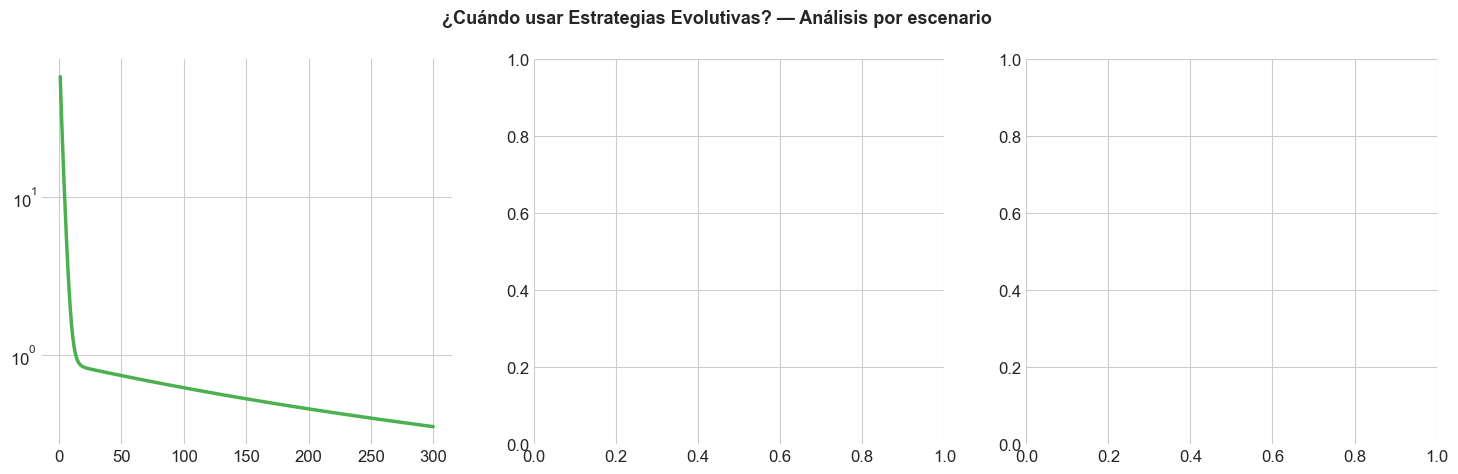

In [26]:
# ════════════════════════════════════════════════════════════════════════
# FIGURA: cuatro escenarios de uso — ¿cuándo usar EE?
# ════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('¿Cuándo usar Estrategias Evolutivas? — Análisis por escenario',
             fontsize=13, fontweight='bold')

# ── Escenario 1: Gradiente disponible — GD gana ───────────────────────
ax = axes[0]
ax.semilogy(gens, f_gd       + 1e-14, color='#4CAF50', linewidth=2.5,
            label='Gradient Descent (gradiente analítico)')
ax.semilogy(gens, f_ee_rosen + 1e-14, color='#FF9800', linewidth=2,
            label='EE anisótropa')
ax.semilogy(gens, f_cma_rosen+ 1e-14, color='#1565c0', linewidth=2,
            label='CMA-ES')
ax.set_title('Escenario A: Gradiente disponible\n→ GD supera a las EE', fontsize=10, fontweight='bold')
ax.set_xlabel('Generación / Paso')
ax.set_ylabel('f(x) — escala log')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.35)
ax.text(0.97, 0.55, '✅ Usar gradient descent\n   cuando ∇f existe',
        transform=ax.transAxes, ha='right', fontsize=9, color='#4CAF50',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='#4CAF50'))

# ── Escenario 2: Alta dimensión separable — DE y EE compiten ──────────
ax = axes[1]
ax.semilogy(gens, f_ee_sep  + 1e-14, color='#FF9800', linewidth=2,   label='EE anisótropa')
ax.semilogy(gens, f_de_sep  + 1e-14, color='#E91E63', linewidth=2.5, label='Evolución Diferencial')
ax.semilogy(gens, f_cma_sep + 1e-14, color='#1565c0', linewidth=2,   label='CMA-ES')
ax.set_title(f'Escenario B: Función separable n={n_sep}\n→ EE competitiva; DE comparable',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Generación')
ax.set_ylabel('f(x) — escala log')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.35)
ax.text(0.97, 0.55, '⚠️ En separable, DE puede\n   ser más eficiente que CMA',
        transform=ax.transAxes, ha='right', fontsize=9, color='#E91E63',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='#E91E63'))

# ── Escenario 3: Función ruidosa — CMA-ES robusto ────────────────────
ax = axes[2]
ax.semilogy(np.abs(f_ee_noisy)  + 1e-6, color='#FF9800', linewidth=2,   label='EE anisótropa')
ax.semilogy(np.abs(f_cma_noisy) + 1e-6, color='#1565c0', linewidth=2.5, label='CMA-ES')
ax.set_title('Escenario C: Función ruidosa (σ_ruido=3)\n→ CMA-ES más robusto al ruido',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Generación')
ax.set_ylabel('|f(x)| — escala log')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.35)
ax.text(0.97, 0.55, '✅ CMA-ES es robusto\n   en presencia de ruido',
        transform=ax.transAxes, ha='right', fontsize=9, color='#1565c0',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='#1565c0'))

plt.tight_layout()
plt.show()

### Qué observar en esta figura

Los tres paneles ilustran los escenarios clave del mapa de decisión.

**Escenario A — Gradiente disponible:** El descenso por gradiente domina con claridad cuando $\nabla f$ existe y es barato de calcular. Con el mismo número de evaluaciones, GD avanza órdenes de magnitud más que cualquier EE. La lección es directa: las EE no son competitivas cuando el gradiente está disponible — son una alternativa para cuando *no* lo está.

**Escenario B — Separable alta dimensión:** En una función separable (esfera en $\mathbb{R}^{30}$), la Evolución Diferencial es competitiva con CMA-ES y en algunos casos más eficiente en evaluaciones. Esto ilustra la vulnerabilidad de CMA-ES en funciones sin correlaciones entre variables: aprender la matriz de covarianza es costoso y la información obtenida es redundante cuando las variables son independientes.

**Escenario C — Ruido:** CMA-ES muestra mayor estabilidad que la EE anisótropa frente a ruido en la evaluación. El mecanismo de evolution path acumula información a lo largo de generaciones, amortiguando las fluctuaciones de evaluaciones individuales. La EE anisótropa, sin ese mecanismo, es más sensible al ruido puntual.

### 6.3 Las EE en productos reales: una revisión

Las Estrategias Evolutivas han dejado el laboratorio académico y hoy alimentan productos y sistemas en varias industrias. La siguiente revisión cubre los casos mejor documentados, organizados por dominio de aplicación.

---

#### Robótica y control: OpenAI ES (2017)

El caso más influyente de EE en producción reciente es el de OpenAI. En 2017, investigadores de OpenAI descubrieron que las estrategias evolutivas rivalizan con técnicas estándar de aprendizaje por refuerzo en benchmarks modernos como Atari y MuJoCo, superando muchas inconveniencias del RL: no requieren backpropagation, escalan mejor en entornos distribuidos, no sufren con recompensas dispersas y tienen menos hiperparámetros.

El resultado práctico fue notable: gracias a la paralelización, fue posible resolver la tarea de caminata humanoide 3D en solo diez minutos utilizando 1440 núcleos de CPU. La arquitectura de OpenAI ES —una EE isótropa con perturbaciones gaussianas en los parámetros de la red neuronal— es esencialmente una versión distribuida de la (μ,λ)-ES que hemos estudiado, donde la función objetivo es la recompensa acumulada de un episodio completo.

---

#### Optimización de hiperparámetros: Optuna + CMA-ES

Optuna es hoy uno de los frameworks de optimización de hiperparámetros más utilizados en ciencia de datos. Optuna soporta métodos evolutivos como CMA-ES, y sus samplers pueden mezclarse o intercambiarse entre fases — por ejemplo, muestreo aleatorio seguido de TPE, o integrando CMA-ES para espacios continuos densos.

La librería `cmaes` para Python, diseñada para ser simple y práctica, incorpora desarrollos recientes como adaptación de la tasa de aprendizaje para escenarios difíciles, transfer learning, optimización de variables mixtas y capacidades multiobjetivo. Esta librería es utilizada internamente por Optuna como sampler de CMA-ES y se actualiza activamente (última versión en enero 2026).

---

#### Diseño automotriz: Stellantis (PSA Group)

En ingeniería automotriz, el grupo PSA (ahora Stellantis) utiliza CMA-ES para la optimización estructural ligera en diseño automotriz. El escenario es el clásico de caja negra costosa: cada evaluación implica una simulación de elementos finitos que puede tardar horas, y el espacio de diseño (grosores de paneles, posición de refuerzos) tiene correlaciones fuertes entre variables — exactamente el tipo de problema donde CMA-ES supera a los métodos sin adaptación de covarianza.

---

#### Benchmark estándar de la industria: BBOB

CMA-ES ha influido en los estándares de benchmarking, con adopción en el Black-Box Optimization Benchmarking (BBOB) desde 2009 para evaluación estandarizada y rigurosa del rendimiento en diversas funciones de prueba. El BBOB es el estándar de facto para comparar optimizadores de caja negra en la conferencia GECCO, y CMA-ES actúa en él como el **baseline de referencia** — cualquier nuevo método de optimización se compara con él.

---

#### Búsqueda de arquitecturas neuronales (NAS)

Desarrollos recientes hasta 2025 han expandido CMA-ES hacia aplicaciones híbridas, notablemente su integración con aprendizaje automático para Neural Architecture Search, como se demuestra en frameworks como CMANAS que aprovechan la velocidad de convergencia de CMA-ES para la optimización eficiente de arquitecturas. En NAS, el espacio de búsqueda es un vector de decisiones de arquitectura (número de capas, canales, skip connections) que es continuo en su relajación, y cada evaluación implica entrenar una red — exactamente la combinación de caja negra costosa y correlaciones estructurales que favorece a CMA-ES.

---

#### Calibración científica: física, biología computacional, finanzas

Las aplicaciones más comunes de CMA-ES son la calibración de modelos (como ajuste de curvas) y la optimización de formas. En la práctica esto incluye:

- **Física de partículas** — calibración de parámetros de detectores en el CERN.
- **Dinámica molecular** — ajuste de campos de fuerza en simulaciones de proteínas.
- **Modelos epidemiológicos** — calibración de parámetros SIR/SEIR a datos observados.
- **Finanzas cuantitativas** — calibración de modelos estocásticos de volatilidad (Heston, SABR) a precios de opciones.

En todos estos casos el denominador común es el mismo: función de costo sin gradiente, evaluaciones costosas, y correlaciones entre parámetros del modelo.

---

<div style="background: linear-gradient(135deg, #e3f2fd, #bbdefb); border-left: 5px solid #1565c0; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Patrón común en todos los casos de uso:</strong> Las EE y CMA-ES no compiten con el gradiente — son la herramienta de elección cuando el gradiente no existe o no es práctico. Cada caso anterior involucra (1) una función objetivo que solo puede evaluarse empíricamente, (2) un espacio de búsqueda continuo con estructura de correlación, y (3) un costo de evaluación suficientemente alto como para justificar un algoritmo que extraiga el máximo de información de pocas evaluaciones de alta calidad.
</div>

### 6.4 Guía práctica de selección de algoritmo

La siguiente celda presenta un árbol de decisión ejecutable que sintetiza todo lo anterior en recomendaciones concretas.

AttributeError: module 'matplotlib.pyplot' has no attribute 'FancyBboxPatch'

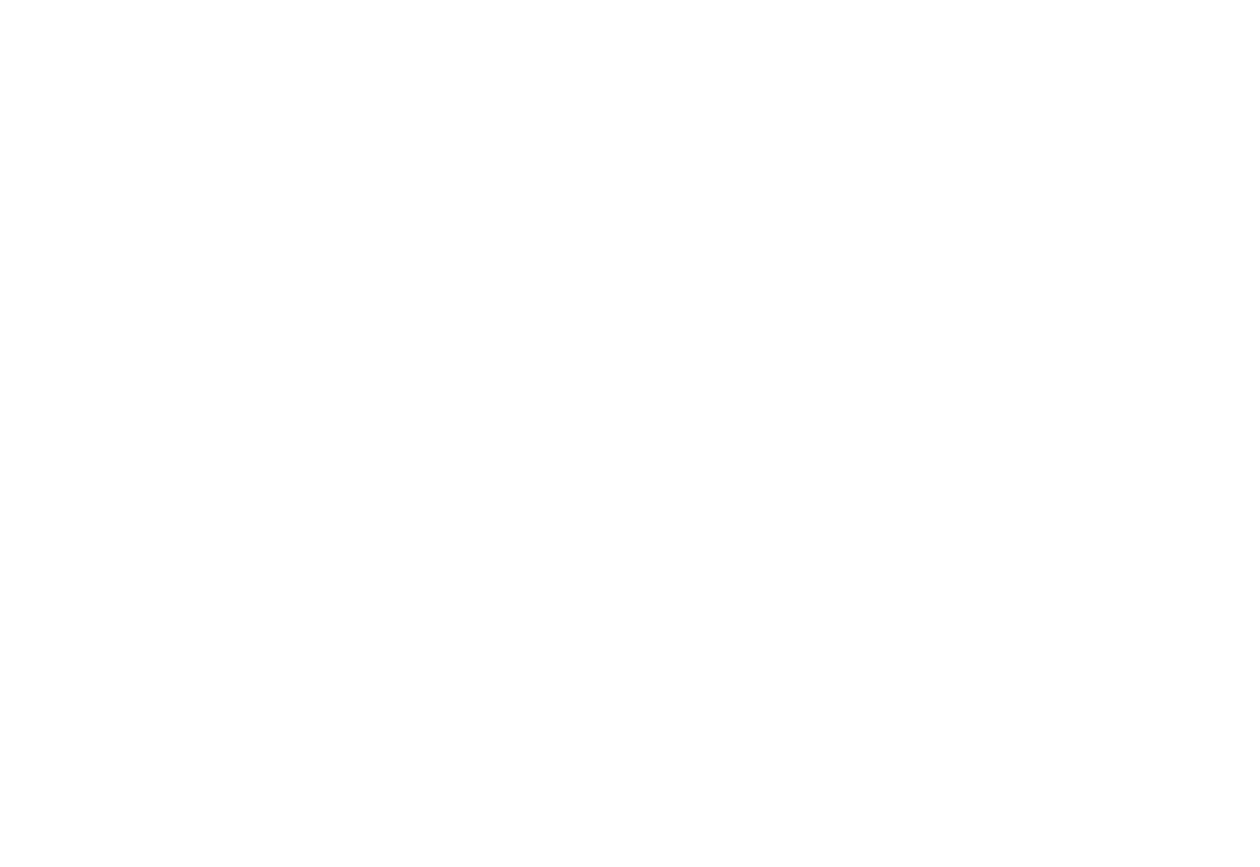

In [27]:
# ════════════════════════════════════════════════════════════════════════
# ÁRBOL DE DECISIÓN VISUAL: ¿qué optimizador usar?
# ════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 11))
ax.set_xlim(0, 16); ax.set_ylim(0, 12)
ax.axis('off')

def caja(ax, x, y, texto, color, ancho=2.8, alto=0.75, fontsize=9):
    rect = plt.FancyBboxPatch((x - ancho/2, y - alto/2), ancho, alto,
                               boxstyle='round,pad=0.12',
                               facecolor=color, edgecolor='#444',
                               linewidth=1.5, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y, texto, ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color='white', zorder=4, wrap=True,
            multialignment='center')

def flecha(ax, x1, y1, x2, y2, label='', color='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.12, my, label, fontsize=8, color=color, style='italic')

# Nodo raíz
caja(ax, 8, 11, '¿Tienes gradiente\n∇f disponible?', '#37474f', ancho=3.2, alto=0.9, fontsize=10)

# Rama SÍ
flecha(ax, 8, 10.55, 3.5, 9.8, 'Sí')
caja(ax, 3.5, 9.3, 'Usar métodos\nbased en gradiente', '#2e7d32', ancho=3.2)
caja(ax, 1.2, 7.7, 'Convexo o\nbien condicionado\n→ L-BFGS, SLSQP', '#388e3c', ancho=2.8, fontsize=8)
caja(ax, 4.5, 7.7, 'Red neuronal\n→ Adam, SGD\n(backprop)', '#388e3c', ancho=2.8, fontsize=8)
flecha(ax, 3.5, 8.95, 1.2, 8.1)
flecha(ax, 3.5, 8.95, 4.5, 8.1)

# Rama NO
flecha(ax, 8, 10.55, 12.5, 9.8, 'No (caja negra)')
caja(ax, 12.5, 9.3, '¿El espacio es\ncontinuo?', '#37474f', ancho=3.0, fontsize=10)

# Continuo → SÍ
flecha(ax, 12.5, 8.95, 12.5, 8.1, 'Sí')
caja(ax, 12.5, 7.6, '¿Dimensión n?', '#5d4037', ancho=2.8, fontsize=10)

# n pequeño
flecha(ax, 11.1, 7.6, 9.2, 6.5, 'n < 5')
caja(ax, 8.7, 6.0, 'Nelder-Mead\no surrogates\n(Kriging)', '#6a1b9a', ancho=2.8, fontsize=8)

# n medio
flecha(ax, 12.5, 7.25, 12.5, 6.3, '5 ≤ n ≤ 200')
caja(ax, 12.5, 5.8, '¿Correlaciones\nentre variables?', '#37474f', ancho=3.0, fontsize=10)
flecha(ax, 12.5, 5.45, 14.5, 4.5, 'Sí')
caja(ax, 14.5, 4.0, '✅ CMA-ES', '#1565c0', ancho=2.2, fontsize=10)
flecha(ax, 12.5, 5.45, 10.5, 4.5, 'No/desconocido')
caja(ax, 10.3, 4.0, 'EE anisótropa\no DE', '#0277bd', ancho=2.5, fontsize=8)

# n grande
flecha(ax, 13.8, 7.6, 15.2, 6.4, 'n > 200')
caja(ax, 15.3, 5.9, 'sep-CMA-ES\nLM-CMA\nDEFO', '#1565c0', ancho=2.3, fontsize=8)

# Discreto → NO continuo
flecha(ax, 12.5, 8.95, 12.5, 9.3)  # reuse arrow up
flecha(ax, 11.1, 9.3, 8.5, 8.1, 'No (discreto)')
caja(ax, 8.0, 7.6, '¿Combinatorio\no permutacional?', '#37474f', ancho=3.2, fontsize=9)
flecha(ax, 8.0, 7.25, 6.2, 6.3, 'Sí')
caja(ax, 5.8, 5.8, 'AG, Recocido\nSimulado,\nBúsqueda Tabú', '#c62828', ancho=2.6, fontsize=8)
flecha(ax, 8.0, 7.25, 9.8, 6.3, 'Discreto continuo')
caja(ax, 10.0, 5.8, 'EE con\nmanejo mixto\n(CMA-ES ext.)', '#e65100', ancho=2.6, fontsize=8)

# Evaluaciones muy costosas
caja(ax, 8, 2.5,
     'Evaluaciones muy costosas (< 100 totales):\nconsiderar métodos basados en surrogates\n(Bayesian Optimization, Kriging)',
     '#4a148c', ancho=9, alto=1.0, fontsize=9)

ax.set_title('Árbol de decisión: selección de optimizador', fontsize=14,
             fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Qué observar en este árbol

El árbol de decisión captura las dos preguntas más importantes para seleccionar un optimizador: si el gradiente existe, y si el espacio es continuo. Las EE ocupan el cuadrante de caja negra continua, y dentro de ese cuadrante la elección entre variantes depende de la dimensión y de si hay correlaciones entre variables.

El recuadro inferior es la advertencia más importante en la práctica: cuando las evaluaciones de la función objetivo son extremadamente costosas (decenas en lugar de miles), los métodos basados en surrogates —optimización bayesiana con procesos gaussianos— suelen superar a las EE porque construyen un modelo aproximado de la función y explotan esa aproximación entre evaluaciones. CMA-ES requiere típicamente $O(10n)$ a $O(100n)$ evaluaciones para converger, lo que puede ser prohibitivo si cada evaluación toma horas.

---

<div style="background: #f8f9fa; padding: 18px; border-radius: 8px; border: 1px solid #dee2e6; margin: 20px 0;">
<h4 style="color: #24398A; margin-top: 0;">Conceptos clave de esta sección</h4>
<ul style="line-height: 2.0; color: #333;">
<li><strong>Las EE son optimizadores de caja negra</strong> — su ventaja sobre el gradiente existe solo cuando ∇f no está disponible o es impracticable.</li>
<li><strong>CMA-ES en producción</strong> — OpenAI ES (RL paralelo), Optuna CMA-ES sampler (hiperparámetros), Stellantis (diseño automotriz), CERN y biología computacional (calibración).</li>
<li><strong>Cuándo DE es mejor que CMA-ES</strong> — funciones separables (sin correlaciones entre variables) donde aprender C es costoso y no aporta información útil.</li>
<li><strong>Cuándo surrogates son mejor que EE</strong> — presupuesto de evaluaciones muy bajo (< 100), donde la construcción del modelo gaussiano es más eficiente que la exploración poblacional.</li>
<li><strong>La EE como backbone paralelo</strong> — su ventaja de escalado lineal en CPUs distribuidos la hace relevante incluso cuando alternativas como el gradiente estocástico existen, en tareas donde la paralelización de episodios es el cuello de botella.</li>
</ul>
</div>

## 7. Ejercicio integrador: EE de juguete paso a paso

En la lección anterior resolvimos el problema más simple posible con el AGS: encontrar la raíz de

$$f(x) = -(x-2)^2 + 10$$

cuyas raíces son $x^* = 2 \pm \sqrt{10} \approx \{-1.162,\ 5.162\}$. Allí usamos codificación binaria de 8 bits, selección por torneo, cruza y mutación por flip.

Ahora resolvemos el **mismo problema** con una **(1+1)-ES** — la EE más simple posible — para ver de forma completamente explícita qué cambia:

| Elemento | AGS (lección 03) | (1+1)-ES (esta lección) |
|---|---|---|
| Individuo | Cadena de 8 bits | Un valor real $x \in \mathbb{R}$ |
| Parámetros de estrategia | Ninguno | $\sigma$ que muta junto con $x$ |
| Mutación | Flip de bits aleatorio | $x' = x + \sigma' \cdot \mathcal{N}(0,1)$ |
| Adaptación | No | $\sigma' = \sigma \cdot e^{\tau \cdot \mathcal{N}(0,1)}$ |
| Selección | Torneo entre población | El mejor de padre e hijo |
| Población | 6 individuos | 1 padre + 1 hijo por generación |

El individuo de la EE tiene dos componentes: $(x, \sigma)$. El $\sigma$ no es un parámetro externo — **vive dentro del cromosoma** y evoluciona junto con $x$.

Vamos paso a paso, generación a generación, mostrando exactamente qué ocurre en cada una.

In [28]:
# ════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DEL PROBLEMA
# ════════════════════════════════════════════════════════════════════════

# Función objetivo: buscamos x* tal que f(x*) = 0
def f(x):
    return -(x - 2)**2 + 10

# Fitness: queremos minimizar |f(x)| → buscar la raíz
def fitness(x):
    return abs(f(x))

# Raíces exactas
import numpy as np
X_OPT_1 = 2 - np.sqrt(10)  # ≈ -1.162
X_OPT_2 = 2 + np.sqrt(10)  # ≈  5.162

# Parámetro de aprendizaje lognormal (n=1 → τ = 1)
TAU = 1.0

# Estado inicial del individuo: (x, σ)
np.random.seed(7)
x0    = 0.0    # punto de inicio
sig0  = 2.0    # σ inicial: exploración amplia

print(f'Función objetivo: f(x) = -(x-2)² + 10')
print(f'Raíces exactas  : x* ≈ {X_OPT_1:.4f}  ó  x* ≈ {X_OPT_2:.4f}')
print(f'Individuo inicial: x = {x0},  σ = {sig0}')
print(f'Fitness inicial  : |f({x0})| = {fitness(x0):.4f}')
print(f'Parámetro τ      : {TAU}')

Función objetivo: f(x) = -(x-2)² + 10
Raíces exactas  : x* ≈ -1.1623  ó  x* ≈ 5.1623
Individuo inicial: x = 0.0,  σ = 2.0
Fitness inicial  : |f(0.0)| = 6.0000
Parámetro τ      : 1.0


In [29]:
# ════════════════════════════════════════════════════════════════════════
# FUNCIÓN: una generación de (1+1)-ES, mostrada en detalle
# ════════════════════════════════════════════════════════════════════════

def una_generacion(x, sigma, gen, verbose=True):
    """
    Ejecuta UNA generación de (1+1)-ES y muestra cada sub-paso.
    Devuelve (x_nuevo, sigma_nuevo, aceptado)
    """
    # ── Paso 1: mutar σ PRIMERO (lognormal) ──────────────────────────
    z_global   = np.random.standard_normal()
    sigma_hijo = sigma * np.exp(TAU * z_global)
    sigma_hijo = max(sigma_hijo, 1e-6)  # límite técnico

    # ── Paso 2: mutar x con σ_hijo ────────────────────────────────────
    z_local = np.random.standard_normal()
    x_hijo  = x + sigma_hijo * z_local

    # ── Paso 3: evaluar fitness de padre e hijo ────────────────────────
    fit_padre = fitness(x)
    fit_hijo  = fitness(x_hijo)

    # ── Paso 4: selección (1+1) — el mejor de los dos ─────────────────
    aceptado = fit_hijo < fit_padre
    x_nuevo     = x_hijo  if aceptado else x
    sigma_nuevo = sigma_hijo if aceptado else sigma

    if verbose:
        print(f'\n── Generación {gen:3d} ────────────────────────────────────')
        print(f'  PADRE  : x = {x:+8.4f}   σ = {sigma:.5f}   |f| = {fit_padre:.5f}')
        print(f'  z_glob = {z_global:+.4f}   →  σ_hijo = {sigma:.5f} · exp({TAU}·{z_global:+.4f}) = {sigma_hijo:.5f}')
        print(f'  z_local= {z_local:+.4f}   →  x_hijo = {x:+.4f} + {sigma_hijo:.5f}·{z_local:+.4f} = {x_hijo:+.4f}')
        print(f'  HIJO   : x = {x_hijo:+8.4f}   σ = {sigma_hijo:.5f}   |f| = {fit_hijo:.5f}')
        result = '✅ ACEPTADO' if aceptado else '❌ RECHAZADO'
        print(f'  Selección: {fit_hijo:.5f} < {fit_padre:.5f} ? {result}')
        print(f'  SUPERVIVIENTE: x = {x_nuevo:+.4f}   σ = {sigma_nuevo:.5f}')

    return x_nuevo, sigma_nuevo, aceptado, x_hijo, sigma_hijo


# Ejecutar las primeras 5 generaciones de forma explícita
x, sigma = x0, sig0
historial = [{'gen':0, 'x':x, 'sigma':sigma, 'fit':fitness(x), 'aceptado':None}]

print('EJECUCIÓN EXPLÍCITA — primeras 5 generaciones')
print('=' * 60)

for gen in range(1, 6):
    x, sigma, acept, x_h, s_h = una_generacion(x, sigma, gen, verbose=True)
    historial.append({'gen':gen, 'x':x, 'sigma':sigma,
                      'fit':fitness(x), 'aceptado':acept})

EJECUCIÓN EXPLÍCITA — primeras 5 generaciones

── Generación   1 ────────────────────────────────────
  PADRE  : x =  +0.0000   σ = 2.00000   |f| = 6.00000
  z_glob = +1.6905   →  σ_hijo = 2.00000 · exp(1.0·+1.6905) = 10.84466
  z_local= -0.4659   →  x_hijo = +0.0000 + 10.84466·-0.4659 = -5.0529
  HIJO   : x =  -5.0529   σ = 10.84466   |f| = 39.74386
  Selección: 39.74386 < 6.00000 ? ❌ RECHAZADO
  SUPERVIVIENTE: x = +0.0000   σ = 2.00000

── Generación   2 ────────────────────────────────────
  PADRE  : x =  +0.0000   σ = 2.00000   |f| = 6.00000
  z_glob = +0.0328   →  σ_hijo = 2.00000 · exp(1.0·+0.0328) = 2.06673
  z_local= +0.4075   →  x_hijo = +0.0000 + 2.06673·+0.4075 = +0.8422
  HIJO   : x =  +0.8422   σ = 2.06673   |f| = 8.65956
  Selección: 8.65956 < 6.00000 ? ❌ RECHAZADO
  SUPERVIVIENTE: x = +0.0000   σ = 2.00000

── Generación   3 ────────────────────────────────────
  PADRE  : x =  +0.0000   σ = 2.00000   |f| = 6.00000
  z_glob = -0.7889   →  σ_hijo = 2.00000 · exp(1.0·-0.788

### Lectura del log generación a generación

Cada bloque del log muestra los cuatro pasos de una generación tal como ocurren internamente:

1. **Padre** — estado actual $(x, \sigma)$ con su fitness $|f(x)|$.
2. **Mutación de σ** — se genera un ruido $z_{\text{glob}} \sim \mathcal{N}(0,1)$ y se aplica la regla lognormal. Si $z_{\text{glob}} > 0$, σ crece (más exploración); si $z_{\text{glob}} < 0$, σ decrece (más explotación).
3. **Mutación de x** — se genera un ruido $z_{\text{loc}} \sim \mathcal{N}(0,1)$ y se desplaza $x$ en $\sigma_{\text{hijo}} \cdot z_{\text{loc}}$. El desplazamiento usa el σ recién mutado.
4. **Selección** — el hijo sobrevive si y solo si mejora el fitness. Si sobrevive, su $(x', \sigma')$ pasan a la siguiente generación; si no, el padre conserva también su σ — el σ que no produjo un buen hijo **no se hereda**.

Este último punto es el mecanismo de autoadaptación en acción: los σ que generan hijos exitosos se propagan; los que no, desaparecen.

In [30]:
# ════════════════════════════════════════════════════════════════════════
# CORRIDA COMPLETA Y TABLA DE HISTORIAL
# ════════════════════════════════════════════════════════════════════════

# Reiniciar y correr 40 generaciones en silencio
np.random.seed(7)
x, sigma = x0, sig0
historial = [{'gen':0, 'x':x, 'sigma':sigma, 'fit':fitness(x), 'aceptado':None,
              'x_hijo':None, 'sigma_hijo':None}]

N_GEN = 40
for gen in range(1, N_GEN + 1):
    x, sigma, acept, x_h, s_h = una_generacion(x, sigma, gen, verbose=False)
    historial.append({'gen':gen, 'x':x, 'sigma':sigma, 'fit':fitness(x),
                      'aceptado':acept, 'x_hijo':x_h, 'sigma_hijo':s_h})

# Tabla resumen de las primeras 15 generaciones
import pandas as pd
df = pd.DataFrame(historial)
df_muestra = df.head(16).copy()
df_muestra['aceptado'] = df_muestra['aceptado'].map({True:'✅', False:'❌', None:'—'})
df_muestra = df_muestra.rename(columns={
    'gen':'Gen', 'x':'x (superviviente)', 'sigma':'σ (superviviente)',
    'fit':'|f(x)|', 'aceptado':'Hijo aceptado',
    'x_hijo':'x hijo', 'sigma_hijo':'σ hijo'
})

pd.set_option('display.float_format', '{:.5f}'.format)
pd.set_option('display.max_columns', 10)
print('Historial de las primeras 15 generaciones:')
print(df_muestra[['Gen','x (superviviente)','σ (superviviente)','|f(x)|','Hijo aceptado']].to_string(index=False))
print(f'\nResultado final (generación {N_GEN}):')
print(f'  x*     = {historial[-1]["x"]:.6f}')
print(f'  σ final= {historial[-1]["sigma"]:.6f}')
print(f'  |f(x*)| = {historial[-1]["fit"]:.6f}')
print(f'  Raíz más cercana: x = {X_OPT_2:.6f}  (error = {abs(historial[-1]["x"] - X_OPT_2):.6f})')

Historial de las primeras 15 generaciones:
 Gen  x (superviviente)  σ (superviviente)  |f(x)| Hijo aceptado
   0            0.00000            2.00000 6.00000             —
   1            0.00000            2.00000 6.00000             ❌
   2            0.00000            2.00000 6.00000             ❌
   3            0.00000            2.00000 6.00000             ❌
   4            0.00000            2.00000 6.00000             ❌
   5            0.00000            2.00000 6.00000             ❌
   6           -0.18357            1.07006 5.23203             ✅
   7           -0.64711            1.77361 2.99280             ✅
   8           -0.64711            1.77361 2.99280             ❌
   9           -0.64711            1.77361 2.99280             ❌
  10           -0.64711            1.77361 2.99280             ❌
  11           -0.64711            1.77361 2.99280             ❌
  12           -0.64711            1.77361 2.99280             ❌
  13           -0.64711            1.77361 2.99

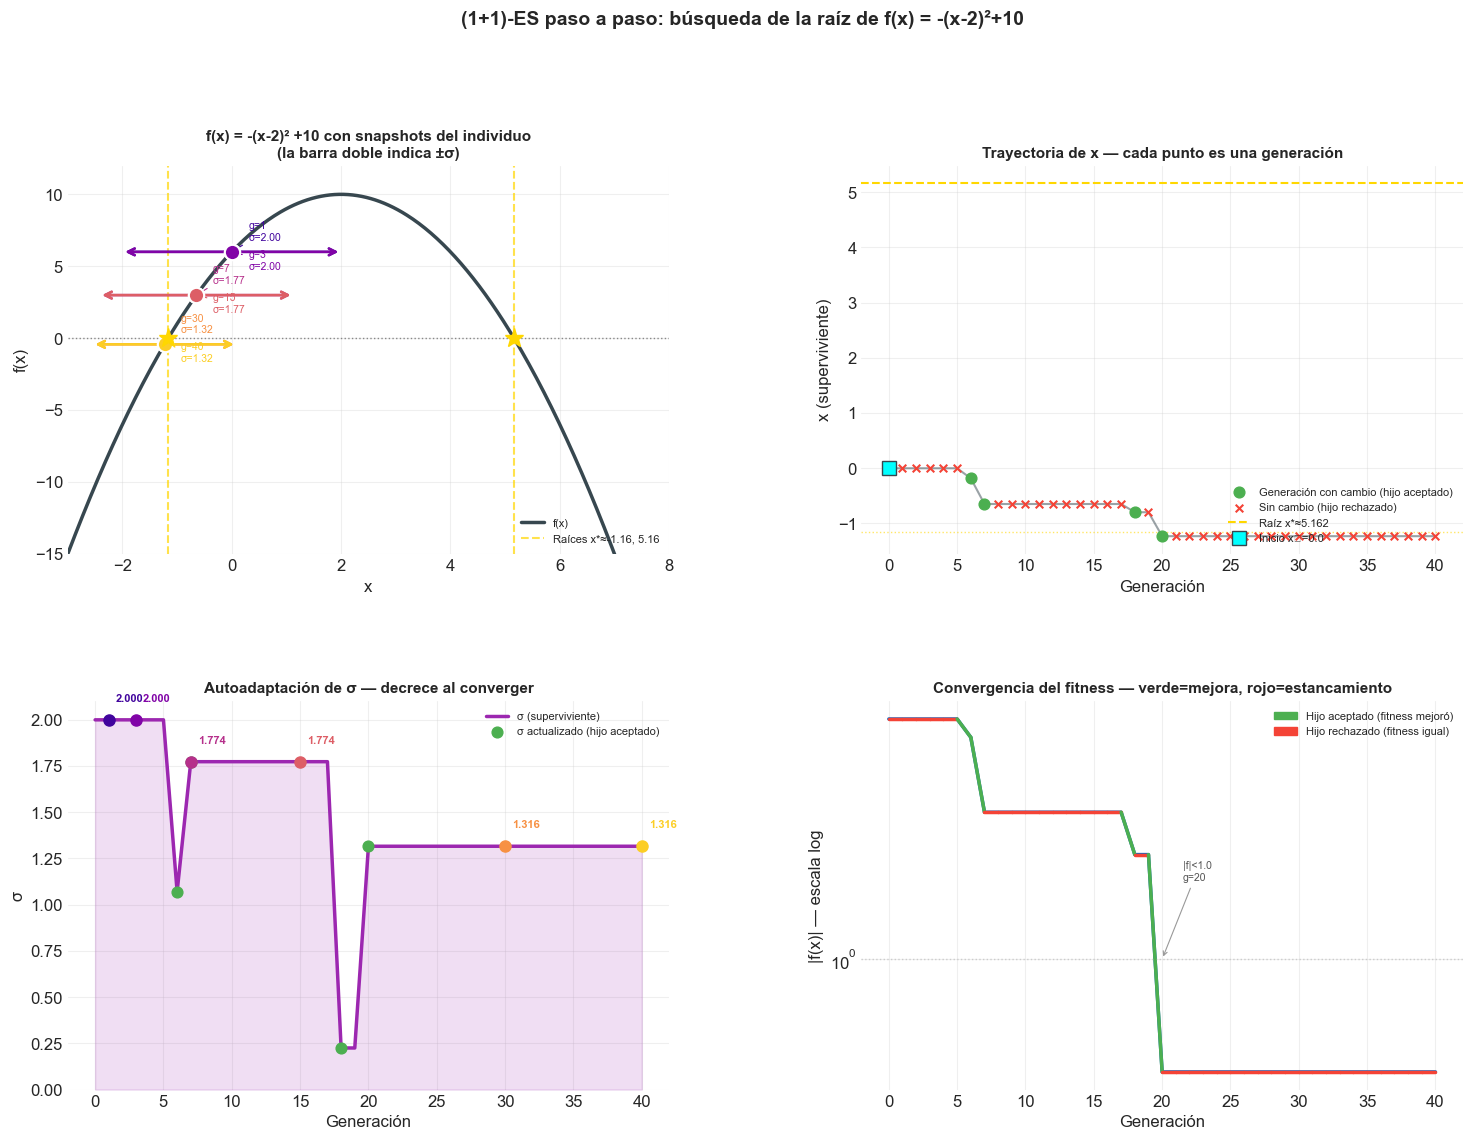

In [33]:
# ════════════════════════════════════════════════════════════════════════
# FIGURA PRINCIPAL: Visualización completa del ejercicio
#
# Panel 1: La función f(x) con snapshots del individuo en varias gens
# Panel 2: Trayectoria de x a lo largo de las generaciones
# Panel 3: Evolución de σ — la autoadaptación en acción
# Panel 4: Fitness |f(x)| — convergencia hacia la raíz
# ════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

gens_hist  = [h['gen']   for h in historial]
x_hist     = [h['x']     for h in historial]
sig_hist   = [h['sigma'] for h in historial]
fit_hist   = [h['fit']   for h in historial]
acept_hist = [h['aceptado'] for h in historial]

# Snapshots para el panel de la función
snap_gens = [1, 3, 7, 15, 30, 40]
colores_snap = plt.cm.plasma(np.linspace(0.1, 0.9, len(snap_gens)))

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# ── Panel 1: f(x) con snapshots del individuo ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
x_plot = np.linspace(-3, 8, 400)
ax1.plot(x_plot, f(x_plot), color='#37474f', linewidth=2.5, label='f(x)')
ax1.axhline(0, color='#888', linewidth=1, linestyle=':')

# Raíces
ax1.axvline(X_OPT_1, color='gold', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.axvline(X_OPT_2, color='gold', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'Raíces x*≈{X_OPT_1:.2f}, {X_OPT_2:.2f}')
ax1.plot([X_OPT_1, X_OPT_2], [0, 0], '*', color='gold', markersize=14, zorder=6)

# Snapshots del individuo
for i, (g, col) in enumerate(zip(snap_gens, colores_snap)):
    xi = x_hist[g]
    si = sig_hist[g]
    fi = f(xi)
    # Individuo
    ax1.plot(xi, fi, 'o', color=col, markersize=11, zorder=5,
             markeredgecolor='white', markeredgewidth=1.5)
    # Barra de σ (indica rango de mutación ±σ en x)
    ax1.annotate('', xy=(xi + si, fi), xytext=(xi - si, fi),
                 arrowprops=dict(arrowstyle='<->', color=col,
                                  lw=1.8, mutation_scale=12))
    # Etiqueta
    offset_y = 0.8 if i % 2 == 0 else -1.2
    ax1.annotate(f'g={g}\nσ={si:.2f}', xy=(xi, fi),
                 xytext=(xi + 0.3, fi + offset_y),
                 fontsize=7.5, color=col,
                 arrowprops=dict(arrowstyle='-', color=col, lw=0.8))

ax1.set_xlim(-3, 8); ax1.set_ylim(-15, 12)
ax1.set_xlabel('x'); ax1.set_ylabel('f(x)')
ax1.set_title('f(x) = -(x-2)² +10 con snapshots del individuo\n(la barra doble indica ±σ)', 
              fontweight='bold', fontsize=11)
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(True, alpha=0.3)

# ── Panel 2: Trayectoria de x ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
g_arr = np.array(gens_hist)
x_arr = np.array(x_hist)
a_arr = np.array([False if a is None else a for a in acept_hist])

# Línea de trayectoria
ax2.plot(g_arr, x_arr, color='#37474f', linewidth=1.5, alpha=0.5, zorder=2)

# Puntos aceptados vs. rechazados
ax2.scatter(g_arr[a_arr], x_arr[a_arr], color='#4CAF50', s=60, zorder=4,
            label='Generación con cambio (hijo aceptado)')
ax2.scatter(g_arr[~a_arr], x_arr[~a_arr], color='#F44336', s=30, zorder=3,
            marker='x', linewidths=1.5, label='Sin cambio (hijo rechazado)')

ax2.axhline(X_OPT_2, color='gold', linestyle='--', linewidth=1.5,
            label=f'Raíz x*≈{X_OPT_2:.3f}')
ax2.axhline(X_OPT_1, color='gold', linestyle=':', linewidth=1, alpha=0.6)

# Punto inicial
ax2.plot(0, x0, 's', color='cyan', markersize=10, zorder=6,
         markeredgecolor='#37474f', label=f'Inicio x₀={x0}')

ax2.set_xlabel('Generación'); ax2.set_ylabel('x (superviviente)')
ax2.set_title('Trayectoria de x — cada punto es una generación', 
              fontweight='bold', fontsize=11)
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(True, alpha=0.3)

# ── Panel 3: Evolución de σ ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
s_arr = np.array(sig_hist)

# Área bajo la curva de σ
ax3.fill_between(g_arr, 0, s_arr, alpha=0.15, color='#9C27B0')
ax3.plot(g_arr, s_arr, color='#9C27B0', linewidth=2.5, label='σ (superviviente)')

# Marcar generaciones con cambio
ax3.scatter(g_arr[a_arr], s_arr[a_arr], color='#4CAF50', s=60, zorder=4,
            label='σ actualizado (hijo aceptado)')

# Anotaciones de σ en snapshots
for g, col in zip(snap_gens, colores_snap):
    ax3.annotate(f'{sig_hist[g]:.3f}',
                 xy=(g, sig_hist[g]),
                 xytext=(g + 0.5, sig_hist[g] + 0.1),
                 fontsize=8, color=col, fontweight='bold')
    ax3.plot(g, sig_hist[g], 'o', color=col, markersize=8, zorder=5)

ax3.set_xlabel('Generación'); ax3.set_ylabel('σ')
ax3.set_title('Autoadaptación de σ — decrece al converger', 
              fontweight='bold', fontsize=11)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(bottom=0)

# ── Panel 4: Convergencia del fitness ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
f_arr = np.array(fit_hist)

# Escala log del fitness
ax4.semilogy(g_arr, f_arr + 1e-8, color='#1565c0', linewidth=2.5,
             label='|f(x)| fitness')

# Hitos de convergencia
umbrales = [1.0, 0.1, 0.01, 0.001]
for u in umbrales:
    idx = np.where(f_arr < u)[0]
    if len(idx):
        g_hit = idx[0]
        ax4.axhline(u, color='#ccc', linestyle=':', linewidth=1)
        ax4.annotate(f'|f|<{u}\ng={g_hit}',
                     xy=(g_hit, u), xytext=(g_hit + 1.5, u * 1.8),
                     fontsize=7.5, color='#555',
                     arrowprops=dict(arrowstyle='->', color='#999', lw=0.8))

# Colores en la curva según si fue generación de cambio
for i in range(1, len(g_arr)):
    color = '#4CAF50' if a_arr[i] else '#F44336'
    ax4.plot(g_arr[i-1:i+1], f_arr[i-1:i+1] + 1e-8, color=color, linewidth=2.5)

patch_acept   = mpatches.Patch(color='#4CAF50', label='Hijo aceptado (fitness mejoró)')
patch_rechaz  = mpatches.Patch(color='#F44336', label='Hijo rechazado (fitness igual)')
ax4.legend(handles=[patch_acept, patch_rechaz], fontsize=8)

ax4.set_xlabel('Generación'); ax4.set_ylabel('|f(x)| — escala log')
ax4.set_title('Convergencia del fitness — verde=mejora, rojo=estancamiento', 
              fontweight='bold', fontsize=11)
ax4.grid(True, alpha=0.3)

fig.suptitle('(1+1)-ES paso a paso: búsqueda de la raíz de f(x) = -(x-2)²+10',
             fontsize=14, fontweight='bold', y=1.01)

plt.show()

### Lectura de la figura

Los cuatro paneles juntos cuentan la historia completa del algoritmo.

**Panel superior izquierdo — f(x) con snapshots:** Los círculos de colores muestran dónde está el individuo en distintas generaciones. La barra doble horizontal en cada punto indica el radio de mutación $\pm\sigma$ vigente en ese momento: al principio es amplia (exploración), al final es estrecha (explotación). Las líneas punteadas doradas marcan las dos raíces; el individuo converge hacia la más cercana a su punto de partida.

**Panel superior derecho — Trayectoria de x:** Los puntos verdes son generaciones donde el hijo fue aceptado y x cambió; los puntos rojos (×) son generaciones donde el hijo fue rechazado y x permaneció igual. Se puede ver que las primeras generaciones tienen muchos cambios (exploración activa) y las últimas tienen pocos (el individuo se asienta cerca de la raíz).

**Panel inferior izquierdo — Evolución de σ:** Este es el panel más revelador. σ no decrece monotónicamente — fluctúa porque cada generación aplica un ruido lognormal distinto. Sin embargo, el **efecto neto** es una tendencia descendente: los σ que producen hijos malos (y son rechazados) desaparecen; solo los σ que producen hijos buenos sobreviven. Este es exactamente el mecanismo de autoadaptación: nadie programó la reducción de σ, emerge de la presión selectiva.

**Panel inferior derecho — Fitness:** La curva alterna entre verde (mejora) y rojo (estancamiento). Los segmentos rojos no son fallos del algoritmo — son generaciones donde el hijo propuesto era peor y fue correctamente rechazado. El fitness solo puede mejorar o mantenerse, nunca empeorar: esta monotonía es la garantía del esquema (1+1).

<div style="background: linear-gradient(135deg, #e8f5e9, #c8e6c9); border-left: 5px solid #2e7d32; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Comparación directa con el AGS de la lección anterior:</strong> El AGS necesitaba 8 bits por variable, selección por torneo entre 6 individuos, operadores de cruza y mutación por flip, y ningún mecanismo para ajustar la intensidad de búsqueda. La (1+1)-ES resuelve el mismo problema con un individuo, dos números reales $(x, \sigma)$, y tres líneas de operadores. La representación continua elimina la traducción genotipo→fenotipo y permite precisión arbitraria sin aumentar el tamaño del cromosoma.
</div>

AttributeError: module 'matplotlib.pyplot' has no attribute 'FancyBboxPatch'

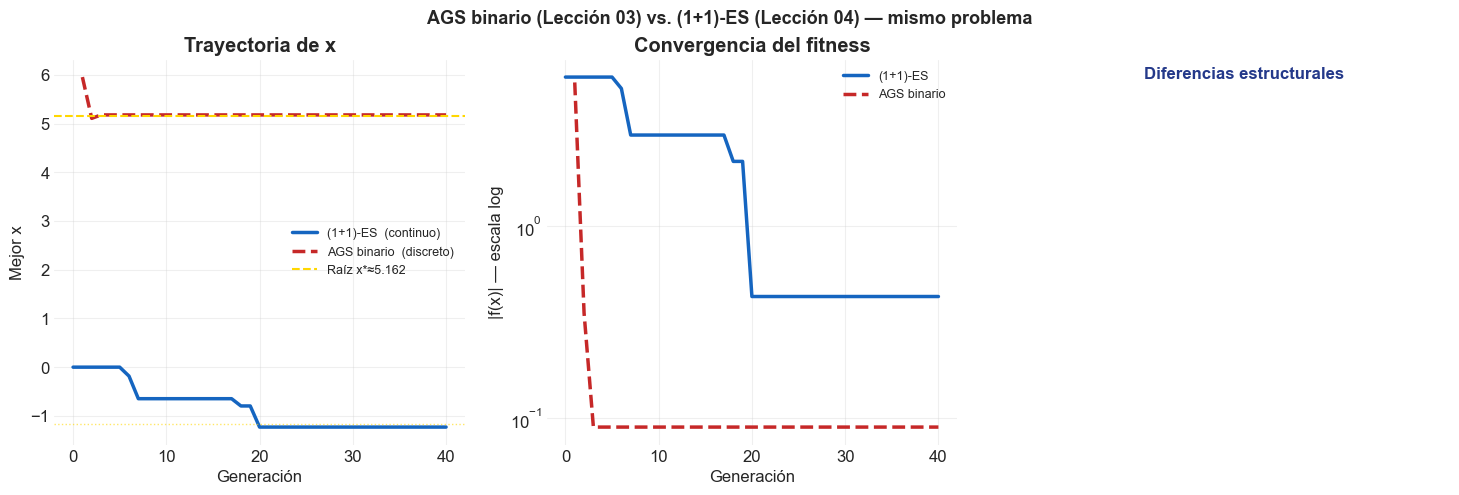

In [34]:
# ════════════════════════════════════════════════════════════════════════
# BONUS: Comparativa directa AGS (lección 03) vs. (1+1)-ES
# Mismo problema, mismo número de evaluaciones de f, resultados distintos
# ════════════════════════════════════════════════════════════════════════

# ── AGS binario (adaptado de la lección 03) ───────────────────────────
N_BITS = 8
X_MIN, X_MAX = 0, 6
POP_SIZE = 6
N_GEN_AGS = 40

def decode(bits):
    """Decodifica cromosoma binario a fenotipo real en [X_MIN, X_MAX]."""
    entero = int(''.join(str(b) for b in bits), 2)
    return X_MIN + entero * (X_MAX - X_MIN) / (2**N_BITS - 1)

def fitness_ags(bits):
    return -abs(f(decode(bits)))

def run_ags_binario(n_gen=40, pop_size=6, seed=7):
    rng_a = np.random.default_rng(seed)
    pop = rng_a.integers(0, 2, (pop_size, N_BITS))
    hist_best_x = []
    hist_best_fit = []
    for _ in range(n_gen):
        fits = np.array([fitness_ags(ind) for ind in pop])
        best = pop[np.argmax(fits)]
        hist_best_x.append(decode(best))
        hist_best_fit.append(abs(f(decode(best))))
        # Selección por torneo k=2
        new_pop = []
        for _ in range(pop_size):
            i1, i2 = rng_a.choice(pop_size, 2, replace=False)
            padre = pop[i1] if fits[i1] > fits[i2] else pop[i2]
            # Cruza de un punto con el mejor
            pt = rng_a.integers(1, N_BITS)
            hijo = np.concatenate([best[:pt], padre[pt:]])
            # Mutación por flip
            mask = rng_a.random(N_BITS) < 0.05
            hijo = np.where(mask, 1 - hijo, hijo)
            new_pop.append(hijo)
        pop = np.array(new_pop)
    return np.array(hist_best_x), np.array(hist_best_fit)


# Correr los dos algoritmos
np.random.seed(7)
x_ee, s_ee = x0, sig0
hist_ee_x, hist_ee_fit = [x_ee], [fitness(x_ee)]
for _ in range(N_GEN_AGS):
    x_ee, s_ee, _, _, _ = una_generacion(x_ee, s_ee, 0, verbose=False)
    hist_ee_x.append(x_ee)
    hist_ee_fit.append(fitness(x_ee))

x_ags, fit_ags = run_ags_binario(N_GEN_AGS)

# ── Figura comparativa ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('AGS binario (Lección 03) vs. (1+1)-ES (Lección 04) — mismo problema',
             fontsize=13, fontweight='bold')

gens_plot = np.arange(N_GEN_AGS + 1)

# Panel 1: trayectoria de x
ax = axes[0]
ax.plot(gens_plot, hist_ee_x, color='#1565c0', linewidth=2.5, label='(1+1)-ES  (continuo)')
ax.plot(np.arange(1, N_GEN_AGS+1), x_ags, color='#c62828', linewidth=2.5,
        linestyle='--', label='AGS binario  (discreto)')
ax.axhline(X_OPT_2, color='gold', linestyle='--', linewidth=1.5, label=f'Raíz x*≈{X_OPT_2:.3f}')
ax.axhline(X_OPT_1, color='gold', linestyle=':', linewidth=1, alpha=0.6)
ax.set_xlabel('Generación'); ax.set_ylabel('Mejor x')
ax.set_title('Trayectoria de x', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 2: fitness en escala log
ax = axes[1]
ax.semilogy(gens_plot, np.array(hist_ee_fit) + 1e-9,
            color='#1565c0', linewidth=2.5, label='(1+1)-ES')
ax.semilogy(np.arange(1, N_GEN_AGS+1), fit_ags + 1e-9,
            color='#c62828', linewidth=2.5, linestyle='--', label='AGS binario')
ax.set_xlabel('Generación'); ax.set_ylabel('|f(x)| — escala log')
ax.set_title('Convergencia del fitness', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 3: diferencias estructurales como tabla visual
ax = axes[2]
ax.axis('off')
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.text(5, 9.5, 'Diferencias estructurales', ha='center',
        fontsize=12, fontweight='bold', color='#24398A')

filas = [
    ('Representación', '8 bits (discreto)', 'Real (continuo)'),
    ('Individuo', 'solo x', '(x, σ)'),
    ('Población', f'{POP_SIZE} individuos', '1 individuo'),
    ('Operadores', 'cruza + flip', 'N(0,1) lognormal'),
    ('Adapta σ?', 'No', 'Sí (automático)'),
    ('Precisión', '1/(2⁸-1) ≈ 0.024', 'Arbitraria'),
    ('Evaluaciones/gen', str(POP_SIZE), '1'),
]
col_w = [3.0, 3.0, 3.2]
headers = ['Aspecto', 'AGS', '(1+1)-ES']
col_colors = ['#37474f', '#c62828', '#1565c0']

y_start = 8.8
for j, (hdr, col, ccolor) in enumerate(zip(headers, [0, 3.3, 6.5], col_colors)):
    bg = plt.FancyBboxPatch((col+0.05, y_start-0.3), col_w[j]-0.15, 0.6,
                             boxstyle='round,pad=0.05', facecolor=ccolor, alpha=0.85)
    ax.add_patch(bg)
    ax.text(col + col_w[j]/2, y_start, hdr, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='white')

for i, (aspecto, val_ags, val_ee) in enumerate(filas):
    y = y_start - 0.85 * (i + 1)
    bg_color = '#f5f5f5' if i % 2 == 0 else '#eeeeee'
    for col, w in zip([0, 3.3, 6.5], col_w):
        bg = plt.FancyBboxPatch((col+0.05, y-0.32), w-0.15, 0.62,
                                 boxstyle='round,pad=0.04', facecolor=bg_color, alpha=0.9)
        ax.add_patch(bg)
    ax.text(0 + col_w[0]/2, y, aspecto, ha='center', va='center', fontsize=8.5, color='#333')
    ax.text(3.3 + col_w[1]/2, y, val_ags, ha='center', va='center',
            fontsize=8.5, color='#c62828', fontweight='bold')
    ax.text(6.5 + col_w[2]/2, y, val_ee, ha='center', va='center',
            fontsize=8.5, color='#1565c0', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Error final AGS    : {fit_ags[-1]:.5f}')
print(f'Error final (1+1)-ES: {hist_ee_fit[-1]:.5f}')

### Lectura de la comparativa

Los dos paneles izquierdos muestran que ambos algoritmos convergen al mismo problema, pero con trayectorias y precisiones distintas.

La trayectoria de x del AGS es **escalerizada**: solo puede tomar los 256 valores discretos que permite la codificación de 8 bits en el dominio $[0, 6]$. La resolución máxima es $6/255 \approx 0.024$ — el algoritmo no puede acercarse más a la raíz que eso, sin importar cuántas generaciones se ejecuten.

La (1+1)-ES trabaja directamente en $\mathbb{R}$: su trayectoria es continua y puede acercarse a la raíz con precisión arbitraria, limitada solo por el σ que el algoritmo logra alcanzar y por el ruido de la autoadaptación en las últimas generaciones.

El panel de fitness en escala logarítmica cuantifica la diferencia: la (1+1)-ES alcanza valores de $|f(x)|$ varios órdenes de magnitud menores que el AGS con el mismo número de generaciones. El AGS llega a un piso determinado por su resolución de codificación; la EE no tiene ese piso.

La tabla de diferencias estructurales sintetiza todo: la EE usa un individuo en lugar de seis, no necesita operadores de cruza, y aprende σ automáticamente. La aparente "simplicidad" de la (1+1)-ES es engañosa — hace más con menos porque su representación continua es naturalmente adecuada para el problema.

---

<div style="background: #f8f9fa; padding: 18px; border-radius: 8px; border: 1px solid #dee2e6; margin: 20px 0;">
<h4 style="color: #24398A; margin-top: 0;">Conceptos clave de esta sección</h4>
<ul style="line-height: 2.0; color: #333;">
<li><strong>El individuo de la EE</strong> — un par (x, σ): las variables del problema y las instrucciones para mutarlas. Ambas evolucionan juntas.</li>
<li><strong>Orden de operaciones</strong> — σ primero (lognormal), luego x (gaussiana). El orden no es arbitrario: garantiza que la selección presione sobre el σ correcto.</li>
<li><strong>σ decrece por emergencia</strong> — nadie programa la reducción de σ. Los valores de σ que producen hijos malos son eliminados; los que producen hijos buenos sobreviven.</li>
<li><strong>Precisión continua</strong> — sin límite de resolución. A diferencia del AGS binario, la EE puede alcanzar la raíz con precisión arbitraria.</li>
<li><strong>Escalabilidad</strong> — el mismo esquema (x, σ) se extiende directamente a n dimensiones añadiendo σᵢ por variable, y luego a CMA-ES añadiendo la matriz C.</li>
</ul>
</div>